In [1]:
from IPython.display import HTML, display
display(HTML("""
<div style='background:linear-gradient(135deg,#e8f0f8 0%,#f5f8fc 100%);padding:40px 44px;border-radius:12px;border-left:6px solid #e08888;margin:10px 0;font-family:Segoe UI,sans-serif;'>
  <div style='color:#e08888;font-size:11px;letter-spacing:5px;text-transform:uppercase;margin-bottom:6px;'>Valorant Champions Tour &middot; 2025 Season</div>
  <h1 style='color:#1a2535;font-size:34px;margin:0;font-weight:800;letter-spacing:-1px;'>Performance Intelligence Platform</h1>
  <div style='height:3px;background:linear-gradient(90deg,#e08888,transparent);margin:14px 0 18px 0;'></div>
  <p style='color:#4a6a80;font-size:13px;margin:0 0 18px 0;line-height:1.8;'>Regional playstyle analysis across <strong style='color:#1a2535;'>Masters Bangkok</strong>, <strong style='color:#1a2535;'>Masters Toronto</strong> &amp; <strong style='color:#1a2535;'>Champions 2025</strong>.<br>183 professional players &middot; 4 VCT regions &middot; ACS &middot; ADR &middot; KAST &middot; KPR &middot; APR &middot; FKPR &middot; FDPR &middot; HS%</p>
  <div style='display:flex;gap:24px;flex-wrap:wrap;border-top:1px solid #2a3f54;padding-top:14px;'>
    <span style='color:#4a6a80;font-size:12px;'><span style='color:#e08888;'>&#9632;</span> Abdurrahmaan</span>
    <span style='color:#4a6a80;font-size:12px;'><span style='color:#e08888;'>&#9632;</span> De Montfort University &middot; CTEC3451</span>
    <span style='color:#4a6a80;font-size:12px;'><span style='color:#e08888;'>&#9632;</span> Supervisor: Aisha</span>
  </div>
</div>
"""))


In [2]:
# -- Theme Toggle (Light / Dark) ------------------------------------------
# Light = current colours. Dark = overlay stylesheet.
# Choice is persisted to ~/.vct_theme so it survives kernel restart.
import os
import ipywidgets as widgets
from IPython.display import display, HTML, Javascript, clear_output
import matplotlib.pyplot as plt

try:
    import plotly.io as pio
    import plotly.graph_objects as go
except Exception:
    pio = None

_THEME_FILE = os.path.join(os.path.expanduser('~'), '.vct_theme')

def _load_theme():
    try:
        with open(_THEME_FILE, 'r', encoding='utf-8') as f:
            v = f.read().strip().lower()
            return v if v in ('light', 'dark') else 'light'
    except Exception:
        return 'light'

def _save_theme(v):
    try:
        with open(_THEME_FILE, 'w', encoding='utf-8') as f:
            f.write(v)
    except Exception:
        pass

_DARK_CSS = """
<style id='vct-dark-mode'>
[style*="background:#ffffff"], [style*="background: #ffffff"] { background:#0f1923 !important; }
[style*="background:#f5f8fc"], [style*="background: #f5f8fc"] { background:#1a2535 !important; }
[style*="background:#f0f4f8"], [style*="background: #f0f4f8"] { background:#131f2b !important; }
[style*="background:#e8eef5"], [style*="background: #e8eef5"] { background:#1a2535 !important; }
[style*="background:#edf1f7"], [style*="background: #edf1f7"] { background:#162030 !important; }
[style*="background:#edf2f7"], [style*="background: #edf2f7"] { background:#162030 !important; }
[style*="background:#f8fafc"], [style*="background: #f8fafc"] { background:#0f1923 !important; }
[style*="background:#eef4fa"], [style*="background: #eef4fa"] { background:#131f2b !important; }
[style*="background:#d8f0e2"], [style*="background: #d8f0e2"] { background:#253530 !important; }
[style*="background:#f8e0e0"], [style*="background: #f8e0e0"] { background:#3a2828 !important; }
[style*="background:#d8e8f8"], [style*="background: #d8e8f8"] { background:#252e3a !important; }
[style*="background:#f8f0d8"], [style*="background: #f8f0d8"] { background:#3a3020 !important; }
[style*="background:#dce6f0"], [style*="background: #dce6f0"] { background:#252e3a !important; }
[style*="background:#dce8f5"], [style*="background: #dce8f5"] { background:#2a3545 !important; }
[style*="background:#f0e8f8"], [style*="background: #f0e8f8"] { background:#2a2030 !important; }
[style*="background:#e8f8f0"], [style*="background: #e8f8f0"] { background:#1f2e25 !important; }
[style*="background-color:#ffffff"], [style*="background-color: #ffffff"] { background-color:#0f1923 !important; }
[style*="background-color:#f5f8fc"], [style*="background-color: #f5f8fc"] { background-color:#1a2535 !important; }
[style*="background-color:#e8eef5"], [style*="background-color: #e8eef5"] { background-color:#1a2535 !important; }
[style*="background-color:#f0f4f8"], [style*="background-color: #f0f4f8"] { background-color:#131f2b !important; }
[style*="background-color:#d8f0e2"], [style*="background-color: #d8f0e2"] { background-color:#253530 !important; }
[style*="background-color:#f8e0e0"], [style*="background-color: #f8e0e0"] { background-color:#3a2828 !important; }
[style*="background-color:#d8e8f8"], [style*="background-color: #d8e8f8"] { background-color:#252e3a !important; }
[style*="background-color:#f8f0d8"], [style*="background-color: #f8f0d8"] { background-color:#3a3020 !important; }
[style*="linear-gradient(135deg,#e8f0f8"] { background:linear-gradient(135deg,#0f1923 0%,#1a2535 100%) !important; }
[style*="color:#1a2535"], [style*="color: #1a2535"] { color:#ffffff !important; }
[style*="color:#4a6a80"], [style*="color: #4a6a80"] { color:#8899aa !important; }
[style*="color:#2c3e50"], [style*="color: #2c3e50"] { color:#e0e6ec !important; }
[style*="color:#3a5060"], [style*="color: #3a5060"] { color:#8a9ba8 !important; }
[style*="color:#5a7080"], [style*="color: #5a7080"] { color:#aabbcc !important; }
[style*="color:#4a5f74"], [style*="color: #4a5f74"] { color:#8a9ba8 !important; }
[style*="color:#3a9060"], [style*="color: #3a9060"] { color:#a8d4b0 !important; }
[style*="color:#c05060"], [style*="color: #c05060"] { color:#dfa8a8 !important; }
[style*="color:#3a78b8"], [style*="color: #3a78b8"] { color:#a0b8dc !important; }
[style*="color:#a07830"], [style*="color: #a07830"] { color:#dcc48a !important; }
[style*="color:#3a7858"], [style*="color: #3a7858"] { color:#a8d4b0 !important; }
[style*="color:#905050"], [style*="color: #905050"] { color:#dfa8a8 !important; }
[style*="color:#2d9060"], [style*="color: #2d9060"] { color:#a8d4b0 !important; }
[style*="color:#a04040"], [style*="color: #a04040"] { color:#dfa8a8 !important; }
[style*="color:#3a6848"], [style*="color: #3a6848"] { color:#a8d4b0 !important; }
[style*="color:#784848"], [style*="color: #784848"] { color:#dfa8a8 !important; }
[style*="color:#3a5878"], [style*="color: #3a5878"] { color:#a0b8dc !important; }
[style*="color:#786040"], [style*="color: #786040"] { color:#dcc48a !important; }
[style*="color:#555"] { color:#aabbcc !important; }
[style*="color:#888"] { color:#8899aa !important; }
[style*="color:#ccc"] { color:#7a909a !important; }
[style*="color:#ddd"] { color:#8899aa !important; }
[style*="#c0d4e8"] { border-color:#2a3f54 !important; }
[style*="#d0dce8"] { border-color:#1a2535 !important; }
[style*="#d0dfec"] { border-color:#2a3f54 !important; }
[style*="#b8cfe0"] { border-color:#2a3f54 !important; }
body.vct-dark .jp-Cell, body.vct-dark .jp-Notebook { background:#0b1420 !important; }
body.vct-dark .jp-RenderedHTMLCommon { color:#e0e6ec; }
</style>
"""

_LIGHT_MPL = {
    'figure.facecolor':'#ffffff','axes.facecolor':'#f5f8fc',
    'axes.edgecolor':'#c0d4e8','grid.color':'#d0dfec',
    'text.color':'#2c3e50','axes.labelcolor':'#2c3e50',
    'xtick.color':'#4a6a80','ytick.color':'#4a6a80',
    'legend.facecolor':'#f0f4f8','legend.edgecolor':'#c0d4e8',
}
_DARK_MPL = {
    'figure.facecolor':'#0f1923','axes.facecolor':'#1a2535',
    'axes.edgecolor':'#2a3f54','grid.color':'#2a3f54',
    'text.color':'#ffffff','axes.labelcolor':'#ffffff',
    'xtick.color':'#8899aa','ytick.color':'#8899aa',
    'legend.facecolor':'#1a2535','legend.edgecolor':'#2a3f54',
}

def _apply_plotly(dark):
    if pio is None:
        return
    if dark:
        pio.templates['vct'] = go.layout.Template(layout=dict(
            paper_bgcolor='#0f1923', plot_bgcolor='#1a2535',
            font=dict(color='#ffffff'),
            xaxis=dict(gridcolor='#2a3f54', zerolinecolor='#2a3f54'),
            yaxis=dict(gridcolor='#2a3f54', zerolinecolor='#2a3f54'),
        ))
    else:
        pio.templates['vct'] = go.layout.Template(layout=dict(
            paper_bgcolor='#ffffff', plot_bgcolor='#f5f8fc',
            font=dict(color='#2c3e50'),
            xaxis=dict(gridcolor='#d0dfec', zerolinecolor='#d0dfec'),
            yaxis=dict(gridcolor='#d0dfec', zerolinecolor='#d0dfec'),
        ))
    pio.templates.default = 'vct'

_status = widgets.Output()

def _set_theme(dark):
    _save_theme('dark' if dark else 'light')
    with _status:
        clear_output()
        if dark:
            display(HTML(_DARK_CSS))
            display(Javascript("document.body.classList.add('vct-dark');"))
            try:
                plt.style.use('dark_background')
            except Exception:
                pass
            plt.rcParams.update(_DARK_MPL)
            _apply_plotly(True)
            display(HTML("<span style='font-family:Segoe UI;font-size:12px;color:#8899aa;'>Dark mode active. Re-run plot cells to re-render them in dark.</span>"))
        else:
            display(Javascript(
                "var s=document.getElementById('vct-dark-mode');if(s)s.remove();"
                "document.body.classList.remove('vct-dark');"
            ))
            try:
                plt.style.use('seaborn-v0_8-whitegrid')
            except Exception:
                pass
            plt.rcParams.update(_LIGHT_MPL)
            _apply_plotly(False)
            display(HTML("<span style='font-family:Segoe UI;font-size:12px;color:#4a6a80;'>Light mode active.</span>"))

_initial = _load_theme()
_btn = widgets.ToggleButtons(
    options=[('☀ Light','light'), ('\U0001F319 Dark','dark')],
    value=_initial,
    description='Theme:',
    style={'button_width':'110px','description_width':'60px'},
    layout=widgets.Layout(margin='6px 0 6px 0'),
)
_btn.observe(lambda ch: _set_theme(ch['new']=='dark') if ch['name']=='value' else None)

display(widgets.VBox([_btn, _status]))
_set_theme(_initial == 'dark')


In [3]:
# VCT-POLISH: GLOBAL-CSS
# Injects a global stylesheet: Inter font, hover transitions, refined
# scrollbars, card polish. Runs once; safe to re-execute.
from IPython.display import HTML, display

display(HTML("""
<style id='vct-polish-global'>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap');

.jp-RenderedHTMLCommon, .jp-RenderedHTMLCommon p,
.jp-RenderedHTMLCommon div, .jp-RenderedHTMLCommon span,
.jp-RenderedHTMLCommon table, .jp-RenderedHTMLCommon td,
.jp-RenderedHTMLCommon th {
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, 'Segoe UI',
                 Roboto, Helvetica, Arial, sans-serif !important;
    -webkit-font-smoothing: antialiased;
    -moz-osx-font-smoothing: grayscale;
    letter-spacing: -0.005em;
}

/* Card hover polish - targets every inline-styled card pattern used
   throughout the notebook (1px border + 8px radius). */
[style*="border:1px solid #c0d4e8"][style*="border-radius:8px"],
[style*="border:1px solid #c0d4e8"][style*="border-radius:12px"] {
    transition: transform .18s ease, box-shadow .18s ease,
                border-color .18s ease;
}
[style*="border:1px solid #c0d4e8"][style*="border-radius:8px"]:hover,
[style*="border:1px solid #c0d4e8"][style*="border-radius:12px"]:hover {
    transform: translateY(-2px);
    box-shadow: 0 8px 24px rgba(26, 37, 53, .08);
    border-color: #e08888 !important;
}

/* Table row hover */
.jp-RenderedHTMLCommon table tr { transition: background-color .15s ease; }
.jp-RenderedHTMLCommon table tbody tr:hover td {
    background: #f8fafc !important;
}

/* Prettier webkit scrollbars inside cells */
.jp-RenderedHTMLCommon ::-webkit-scrollbar { width: 10px; height: 10px; }
.jp-RenderedHTMLCommon ::-webkit-scrollbar-thumb {
    background: #c0d4e8; border-radius: 5px;
}
.jp-RenderedHTMLCommon ::-webkit-scrollbar-thumb:hover { background: #e08888; }
.jp-RenderedHTMLCommon ::-webkit-scrollbar-track { background: transparent; }

/* Tighter widget spacing + rounded edges */
.widget-slider .ui-slider { border-radius: 6px !important; }
.widget-dropdown > select, .widget-text > input {
    border: 1px solid #c0d4e8 !important;
    border-radius: 6px !important;
    transition: border-color .15s ease;
}
.widget-dropdown > select:focus, .widget-text > input:focus {
    border-color: #e08888 !important;
    outline: none !important;
}
.widget-button {
    border-radius: 6px !important;
    transition: transform .12s ease, box-shadow .12s ease;
}
.widget-button:hover {
    transform: translateY(-1px);
    box-shadow: 0 4px 10px rgba(26, 37, 53, .15);
}

/* Consistent H tag weight in markdown cells */
.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3 {
    font-weight: 700 !important;
    letter-spacing: -0.02em !important;
}
</style>
"""))


In [4]:
# VCT-POLISH: DESIGN-SYS
# Design tokens + helper functions. Any later cell may call section_banner(),
# kpi(), card(), badge() for consistent styling. Also applies unified
# matplotlib rcParams.
from IPython.display import HTML
import matplotlib.pyplot as plt

BRAND = {
    # Backgrounds
    'bg':       '#ffffff',
    'surface':  '#f5f8fc',
    'surface2': '#f0f4f8',
    'panel':    '#e8eef5',
    # Text
    'ink':      '#1a2535',
    'ink2':     '#2c3e50',
    'muted':    '#4a6a80',
    'muted2':   '#5a7080',
    # Lines
    'line':     '#c0d4e8',
    'line2':    '#d0dfec',
    # Accent + regions
    'accent':   '#e08888',
    'pos':      '#3a9060',
    'neg':      '#c05060',
    'r_am':     '#a8d4b0',
    'r_em':     '#dfa8a8',
    'r_pa':     '#a0b8dc',
    'r_cn':     '#dcc48a',
    # Type scale
    'font':     "'Inter', -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif",
}

def section_banner(num, title, subtitle=''):
    """Chapter-style banner for a section. Emits both anchor + visual."""
    sub_html = (
        f"<div style='color:{BRAND['muted']};font-size:13px;font-weight:400;"
        f"margin-top:6px;max-width:760px;line-height:1.6;'>{subtitle}</div>"
        if subtitle else ''
    )
    return HTML(
        f"<a id='section{num}'></a>"
        f"<div style='font-family:{BRAND['font']};margin:28px 0 14px 0;"
        f"padding:18px 22px;background:{BRAND['bg']};border:1px solid {BRAND['line']};"
        f"border-left:4px solid {BRAND['accent']};border-radius:8px;'>"
        f"<div style='display:flex;align-items:baseline;gap:16px;'>"
        f"<span style='color:{BRAND['accent']};font-weight:800;font-size:34px;"
        f"letter-spacing:-0.03em;line-height:1;'>{num:02d}</span>"
        f"<div>"
        f"<div style='color:{BRAND['muted']};font-size:10px;letter-spacing:4px;"
        f"text-transform:uppercase;font-weight:600;margin-bottom:2px;'>Section</div>"
        f"<div style='color:{BRAND['ink']};font-size:22px;font-weight:700;"
        f"letter-spacing:-0.02em;line-height:1.2;'>{title}</div>"
        f"</div></div>{sub_html}</div>"
    )

def badge(text, tone='muted'):
    palette = {
        'muted':   (BRAND['muted'],  BRAND['surface']),
        'accent':  (BRAND['accent'], '#fbecec'),
        'pos':     (BRAND['pos'],    '#e5f0e9'),
        'neg':     (BRAND['neg'],    '#f5e0e3'),
        'americas':(BRAND['r_am'],   '#e5f1e7'),
        'emea':    (BRAND['r_em'],   '#f5e3e3'),
        'pacific': (BRAND['r_pa'],   '#e2eaf2'),
        'cn':      (BRAND['r_cn'],   '#f2eadb'),
    }
    fg, bg = palette.get(tone, palette['muted'])
    return (f"<span style='display:inline-block;padding:2px 10px;"
            f"background:{bg};color:{fg};border-radius:12px;font-size:11px;"
            f"font-weight:600;letter-spacing:.4px;'>{text}</span>")

def kpi(label, value, sub='', trend=None):
    """Single KPI card. trend: optional (+/-) short chip string."""
    trend_html = (f"<span style='color:{BRAND['pos'] if trend and str(trend).startswith('+') else BRAND['neg']};"
                  f"font-size:11px;font-weight:700;margin-left:6px;'>{trend}</span>"
                  if trend else '')
    return (
        f"<div style='background:{BRAND['panel']};border:1px solid {BRAND['line']};"
        f"border-top:3px solid {BRAND['accent']};border-radius:10px;"
        f"padding:18px 22px;flex:1;min-width:150px;'>"
        f"<div style='color:{BRAND['muted']};font-size:10px;letter-spacing:3px;"
        f"text-transform:uppercase;margin-bottom:6px;font-weight:600;'>{label}</div>"
        f"<div style='color:{BRAND['ink']};font-size:30px;font-weight:800;"
        f"line-height:1;letter-spacing:-0.03em;'>{value}{trend_html}</div>"
        f"<div style='color:{BRAND['accent']};font-size:11px;margin-top:8px;"
        f"font-weight:500;'>{sub}</div></div>"
    )

def card(body, title='', accent=True):
    header = (
        f"<div style='border-bottom:1px solid {BRAND['line']};"
        f"padding:10px 18px;background:{BRAND['surface']};'>"
        f"<span style='color:{BRAND['accent']};font-size:10px;letter-spacing:3px;"
        f"text-transform:uppercase;font-weight:700;'>{title}</span></div>"
        if title else ''
    )
    border_left = f"border-left:4px solid {BRAND['accent']};" if accent else ''
    return (
        f"<div style='background:{BRAND['bg']};border:1px solid {BRAND['line']};"
        f"{border_left}border-radius:8px;font-family:{BRAND['font']};overflow:hidden;'>"
        f"{header}<div style='padding:14px 18px;color:{BRAND['ink']};"
        f"font-size:13px;line-height:1.7;'>{body}</div></div>"
    )

def apply_chart_style():
    plt.rcParams.update({
        'font.family':       ['Inter', 'Segoe UI', 'DejaVu Sans', 'sans-serif'],
        'font.size':         11,
        'axes.titlesize':    13,
        'axes.titleweight':  'bold',
        'axes.titlepad':     14,
        'axes.labelsize':    11,
        'axes.labelweight':  'regular',
        'axes.labelpad':     8,
        'axes.spines.top':   False,
        'axes.spines.right': False,
        'axes.grid':         True,
        'grid.alpha':        0.25,
        'grid.linestyle':    '-',
        'legend.frameon':    False,
        'legend.fontsize':   10,
        'xtick.labelsize':   10,
        'ytick.labelsize':   10,
        'figure.titlesize':  15,
        'figure.titleweight':'bold',
        'figure.dpi':        100,
        'savefig.dpi':       150,
        'savefig.bbox':      'tight',
    })

apply_chart_style()


<!-- VCT-ACADEMIC:EXEC -->
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;
            border-radius:8px;padding:22px 28px;margin:14px 0;">
  <div style="color:#e08888;font-size:10px;letter-spacing:4px;text-transform:uppercase;
              font-weight:700;margin-bottom:10px;">Executive Summary</div>
  <p style="color:#1a2535;font-size:13px;line-height:1.8;margin:0 0 10px 0;">
    This interactive notebook analyses the 2025 Valorant Champions Tour season — 183
    professional players across four competitive regions (Americas, EMEA, Pacific, CN)
    over three international events (Masters Bangkok, Masters Toronto, Champions).
    The platform unifies descriptive statistics, inferential testing (Kruskal-Wallis,
    bootstrap confidence intervals), unsupervised clustering (KMeans + PCA), and
    supervised classification (Random Forest, Logistic Regression) to quantify
    <em>how</em> and <em>how much</em> professional Valorant playstyles differ across regions.
  </p>
  <p style="color:#4a6a80;font-size:13px;line-height:1.8;margin:0;">
    Thirty-five interactive sections let a reader explore individual players, compare
    regions, predict Champions qualification, cluster stylistic archetypes, and
    customise composite rankings via live weight sliders. Key findings are
    reported in <b style="color:#1a2535;">Section 31</b>; methodology is
    justified in <b style="color:#1a2535;">Section 30</b>; limitations in
    <b style="color:#1a2535;">Section 32</b>.
  </p>
</div>


<!-- VCT-ACADEMIC:RQ -->
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#f5f8fc;border:1px solid #c0d4e8;border-radius:8px;
            padding:18px 24px;margin:10px 0;">
  <div style="color:#e08888;font-size:10px;letter-spacing:4px;text-transform:uppercase;
              font-weight:700;margin-bottom:8px;">Research Question</div>
  <div style="color:#1a2535;font-size:16px;font-weight:600;line-height:1.5;margin-bottom:14px;">
    To what extent do professional Valorant playstyles differ across the four VCT regions in the
    2025 season, and how predictive are individual performance metrics of tournament outcome?
  </div>
  <div style="color:#4a6a80;font-size:12px;letter-spacing:3px;text-transform:uppercase;
              font-weight:700;margin-bottom:6px;">Sub-questions</div>
  <ul style="color:#1a2535;font-size:13px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Are the regional differences statistically significant across the eight canonical metrics?</li>
    <li>Do natural performance archetypes emerge when regions and roles are hidden?</li>
    <li>Can Masters-stage form predict Champions qualification?</li>
    <li>Which metrics most strongly distinguish one region from another?</li>
  </ul>
</div>


<!-- VCT-ACADEMIC:GLOSS -->
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;
            padding:18px 24px;margin:10px 0;">
  <div style="color:#e08888;font-size:10px;letter-spacing:4px;text-transform:uppercase;
              font-weight:700;margin-bottom:10px;">Glossary of Metrics</div>
  <table style="border-collapse:collapse;width:100%;font-size:12px;">
    <thead>
      <tr>
        <th style="background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;
                   text-align:left;font-weight:700;">Metric</th>
        <th style="background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;
                   text-align:left;font-weight:700;">Definition</th>
        <th style="background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;
                   text-align:left;font-weight:700;">Interpretation</th>
      </tr>
    </thead>
    <tbody>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">ACS</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Average Combat Score</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Composite round-level impact (kills, assists, damage)</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">ADR</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Average Damage per Round</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Raw damage output; closely correlated with ACS</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">KAST</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Kill / Assist / Survive / Trade %</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">% of rounds where player contributed positively. Consistency measure.</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">KPR</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Kills Per Round</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Frag volume, independent of round count</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">APR</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Assists Per Round</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Utility / enabler role indicator (Initiators, Controllers)</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">FKPR</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">First Kills Per Round</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Entry / opening aggression (Duellists score high)</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">FDPR</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">First Deaths Per Round</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Entry-death rate. Lower is better. Inverted in composite scoring.</td></tr>
      <tr><td style="padding:6px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;">HS%</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Headshot Percentage</td>
          <td style="padding:6px 10px;border:1px solid #c0d4e8;color:#4a6a80;">Mechanical precision. Meta-sensitive (agent / weapon mix).</td></tr>
    </tbody>
  </table>
  <div style="color:#4a6a80;font-size:11px;margin-top:10px;line-height:1.6;">
    <b style="color:#1a2535;">Regions:</b> Americas (NA+LATAM+BR) &middot; EMEA (Europe, MENA) &middot;
    Pacific (KR+JP+APAC) &middot; CN (China). &nbsp;
    <b style="color:#1a2535;">Events:</b> Masters Bangkok (Feb 2025) &middot; Masters Toronto (June 2025)
    &middot; Champions 2025 (Sept 2025).
  </div>
</div>


In [5]:
display(HTML("""
<div style='background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;padding:20px 24px;font-family:Segoe UI,sans-serif;margin:8px 0;'>
  <div style='color:#e08888;font-size:11px;letter-spacing:4px;text-transform:uppercase;margin-bottom:12px;'>Table of Contents</div>
  <div style='display:grid;grid-template-columns:1fr 1fr;gap:6px 32px;'>
    <a href='#section1' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>1. Interactive Player Explorer</a>
    <a href='#section2' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>2. Regional Summary Statistics</a>
    <a href='#section3' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>3. Per Event Breakdown</a>
    <a href='#section4' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>4. Top Performers Leaderboard</a>
    <a href='#section5' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>5. Scatter Plot Comparison</a>
    <a href='#section6' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>6. Agent Analysis</a>
    <a href='#section7' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>7. Radar Chart</a>
    <a href='#section8' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>8. Statistical Analysis</a>
    <a href='#section9' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>9. Normalised Heatmap</a>
    <a href='#section10' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>10. Violin Plots</a>
    <a href='#section11' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>11. Player Search</a>
    <a href='#section12' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>12. Region vs Region</a>
    <a href='#section13' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>13. Team Comparison</a>
    <a href='#section14' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>14. Performance Distribution</a>
    <a href='#section15' style='color:#4a6a80;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;'>15. Map Pick Analysis</a>
    <a href='#section16' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>16. &#9733; Player Profile Card</a>
    <a href='#section35' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>35. &#9733; Export Data</a>
    <a href='#section17' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>17. &#9733; Performance Fingerprint (Plotly)</a>
    <a href='#section18' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>18. &#9733; Tournament Timeline</a>
  <a href='#section19' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>19. &#9733; Player Insights</a>
    <a href='#section20' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>20. &#9733; Correlation Heatmap</a>
    <a href='#section21' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>21. &#9733; Playstyle Clusters</a>
    <a href='#section22' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>22. &#9733; Region Classifier</a>
    <a href='#section23' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>23. &#9733; Agent Role Mix</a>
  <a href='#section24' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>24. &#9733; Player Similarity</a>
    <a href='#section25' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>25. &#9733; Event-to-Event Delta</a>
    <a href='#section26' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>26. &#9733; Champions Predictor</a>
    <a href='#section27' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>27. &#9733; Bootstrap CIs</a>
    <a href='#section28' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>28. &#9733; Metric Weighting</a>
  <a href='#section29' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>29. &#9733; Methodology</a>
    <a href='#section30' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>30. &#9733; Key Findings</a>
    <a href='#section31' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>31. &#9733; Limitations</a>
    <a href='#section32' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>32. &#9733; Evaluation</a>
    <a href='#section33' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>33. &#9733; References</a>
    <a href='#section34' style='color:#e08888;text-decoration:none;font-size:13px;padding:3px 0;border-bottom:1px solid #d0dce8;font-weight:bold;'>34. &#9733; Reproducibility</a>
    </div>
</div>
"""))


In [6]:
display(HTML('<div style="font-family:Segoe UI,sans-serif;max-width:860px;">\n\n  <div style="background:#ffffff;border-left:5px solid #e08888;border-radius:8px 8px 0 0;padding:16px 22px;">\n    <span style="color:#e08888;font-size:11px;letter-spacing:4px;text-transform:uppercase;">Reference</span>\n    <h2 style="color:#1a2535;margin:4px 0 0 0;font-size:20px;font-weight:800;">Glossary</h2>\n  </div>\n\n  <div style="background:#f0f4f8;padding:18px 22px;border-left:5px solid #1a2535;margin-top:2px;">\n    <div style="color:#4a6a80;font-size:11px;letter-spacing:3px;text-transform:uppercase;margin-bottom:12px;">VCT Regions</div>\n    <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;">\n      <div style="background:#e8eef5;border-radius:6px;padding:10px 14px;border-left:3px solid #a8d4b0;">\n        <span style="color:#3a9060;font-weight:700;font-size:13px;">Americas</span>\n        <div style="color:#4a6a80;font-size:12px;margin-top:2px;">North America + Latin America</div>\n      </div>\n      <div style="background:#e8eef5;border-radius:6px;padding:10px 14px;border-left:3px solid #dfa8a8;">\n        <span style="color:#c05060;font-weight:700;font-size:13px;">EMEA</span>\n        <div style="color:#4a6a80;font-size:12px;margin-top:2px;">Europe, Middle East &amp; Africa</div>\n      </div>\n      <div style="background:#e8eef5;border-radius:6px;padding:10px 14px;border-left:3px solid #a0b8dc;">\n        <span style="color:#3a78b8;font-weight:700;font-size:13px;">Pacific</span>\n        <div style="color:#4a6a80;font-size:12px;margin-top:2px;">East &amp; Southeast Asia (Japan, Korea, Thailand&#8230;)</div>\n      </div>\n      <div style="background:#e8eef5;border-radius:6px;padding:10px 14px;border-left:3px solid #dcc48a;">\n        <span style="color:#a07830;font-weight:700;font-size:13px;">CN</span>\n        <div style="color:#4a6a80;font-size:12px;margin-top:2px;">China</div>\n      </div>\n    </div>\n  </div>\n\n  <div style="background:#f0f4f8;padding:18px 22px;border-left:5px solid #1a2535;margin-top:2px;">\n    <div style="color:#4a6a80;font-size:11px;letter-spacing:3px;text-transform:uppercase;margin-bottom:12px;">Performance Metrics</div>\n    <table style="width:100%;border-collapse:collapse;font-size:13px;">\n      <thead>\n        <tr style="background:#ffffff;">\n          <th style="color:#e08888;text-align:left;padding:8px 12px;width:70px;">Metric</th>\n          <th style="color:#e08888;text-align:left;padding:8px 12px;width:220px;">Full Name</th>\n          <th style="color:#e08888;text-align:left;padding:8px 12px;">What it means</th>\n        </tr>\n      </thead>\n      <tbody>\n        <tr style="border-bottom:1px solid #d0dce8;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">ACS</td>\n          <td style="padding:8px 12px;color:#1a2535;">Average Combat Score</td>\n          <td style="padding:8px 12px;color:#4a6a80;">Overall performance score per round &mdash; higher means more impactful</td>\n        </tr>\n        <tr style="border-bottom:1px solid #d0dce8;background:#edf1f7;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">ADR</td>\n          <td style="padding:8px 12px;color:#1a2535;">Average Damage per Round</td>\n          <td style="padding:8px 12px;color:#4a6a80;">Average damage dealt to enemies each round</td>\n        </tr>\n        <tr style="border-bottom:1px solid #d0dce8;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">KAST%</td>\n          <td style="padding:8px 12px;color:#1a2535;">Kill / Assist / Survive / Trade %</td>\n          <td style="padding:8px 12px;color:#4a6a80;">% of rounds where a player got a kill, assist, survived, or traded &mdash; measures consistency</td>\n        </tr>\n        <tr style="border-bottom:1px solid #d0dce8;background:#edf1f7;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">KPR</td>\n          <td style="padding:8px 12px;color:#1a2535;">Kills per Round</td>\n          <td style="padding:8px 12px;color:#4a6a80;">Average number of kills per round</td>\n        </tr>\n        <tr style="border-bottom:1px solid #d0dce8;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">APR</td>\n          <td style="padding:8px 12px;color:#1a2535;">Assists per Round</td>\n          <td style="padding:8px 12px;color:#4a6a80;">Average number of assists per round</td>\n        </tr>\n        <tr style="border-bottom:1px solid #d0dce8;background:#edf1f7;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">FKPR</td>\n          <td style="padding:8px 12px;color:#1a2535;">First Kills per Round</td>\n          <td style="padding:8px 12px;color:#4a6a80;">How often a player gets the first kill of a round &mdash; measures aggression</td>\n        </tr>\n        <tr style="border-bottom:1px solid #d0dce8;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">FDPR</td>\n          <td style="padding:8px 12px;color:#1a2535;">First Deaths per Round</td>\n          <td style="padding:8px 12px;color:#4a6a80;">How often a player dies first &mdash; higher means more aggressive / risky</td>\n        </tr>\n        <tr style="background:#edf1f7;">\n          <td style="padding:8px 12px;color:#3a9060;font-weight:700;">HS%</td>\n          <td style="padding:8px 12px;color:#1a2535;">Headshot Percentage</td>\n          <td style="padding:8px 12px;color:#4a6a80;">% of kills that were headshots &mdash; reflects aiming style</td>\n        </tr>\n      </tbody>\n    </table>\n  </div>\n\n  <div style="background:#f0f4f8;padding:18px 22px;border-left:5px solid #1a2535;border-radius:0 0 8px 8px;margin-top:2px;">\n    <div style="color:#4a6a80;font-size:11px;letter-spacing:3px;text-transform:uppercase;margin-bottom:12px;">Statistical Tests</div>\n    <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;">\n      <div style="background:#e8eef5;border-radius:6px;padding:14px 16px;border-top:2px solid #a0b8dc;">\n        <div style="color:#3a78b8;font-weight:700;font-size:13px;margin-bottom:6px;">Kruskal-Wallis Test</div>\n        <div style="color:#4a6a80;font-size:12px;line-height:1.6;">Checks whether a significant difference exists across all four regions. A p&#8209;value &lt; 0.05 means the difference is unlikely due to chance.</div>\n      </div>\n      <div style="background:#e8eef5;border-radius:6px;padding:14px 16px;border-top:2px solid #dcc48a;">\n        <div style="color:#a07830;font-weight:700;font-size:13px;margin-bottom:6px;">Mann-Whitney U Test</div>\n        <div style="color:#4a6a80;font-size:12px;line-height:1.6;">Follow-up test comparing two regions at a time to identify which pairs differ significantly. Also uses p &lt; 0.05 as the threshold.</div>\n      </div>\n    </div>\n  </div>\n\n</div>'))


Metric,Full Name,What it means
ACS,Average Combat Score,Overall performance score per round — higher means more impactful
ADR,Average Damage per Round,Average damage dealt to enemies each round
KAST%,Kill / Assist / Survive / Trade %,"% of rounds where a player got a kill, assist, survived, or traded — measures consistency"
KPR,Kills per Round,Average number of kills per round
APR,Assists per Round,Average number of assists per round
FKPR,First Kills per Round,How often a player gets the first kill of a round — measures aggression
FDPR,First Deaths per Round,How often a player dies first — higher means more aggressive / risky
HS%,Headshot Percentage,% of kills that were headshots — reflects aiming style


In [7]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ipywidgets import interact, widgets, interactive_output
from itertools import combinations
from scipy import stats

# Download datasets from GitHub
base_url = "https://raw.githubusercontent.com/kota1738/VCT-Project/master/"

for filename in ["vct_2025_clean.csv", "vct_2025_maps.csv"]:
    r = requests.get(base_url + filename)
    with open(filename, "wb") as f:
        f.write(r.content)

combined_df = pd.read_csv("vct_2025_clean.csv")
combined_df["KAST"] = pd.to_numeric(combined_df["KAST"], errors="coerce")
combined_df["HS%"]  = pd.to_numeric(combined_df["HS%"],  errors="coerce")

maps_df = pd.read_csv("vct_2025_maps.csv")

print(f"Loaded {len(combined_df)} records | {combined_df['Player'].nunique()} unique players")
print("combined_df columns:", combined_df.columns.tolist())
print(combined_df["Region"].value_counts())
print(f"Loaded {len(maps_df)} map records")

# Normalise maps_df team names to abbreviations (match combined_df)
_team_map = {
    'DRX': 'DRX', 'Dragon Ranger Gaming': 'DRG', 'EDward Gaming': 'EDG',
    'FNATIC': 'FNC', 'G2 Esports': 'G2', 'GIANTX': 'GX', 'Gen.G': 'GEN',
    'Guangzhou Huadu Bilibili Gaming(Bilibili Gaming)': 'BLG',
    'MIBR': 'MIBR', 'NRG': 'NRG', 'Paper Rex': 'PRX', 'Rex Regum Qeon': 'RRQ',
    'Sentinels': 'SEN', 'T1': 'T1', 'Team Heretics': 'TH',
    'Team Liquid': 'TL', 'Team Vitality': 'VIT', 'Trace Esports': 'TE',
    'Wolves Esports': 'WOL', 'Xi Lai Gaming': 'XLG',
}
maps_df['Team1']  = maps_df['Team1'].map(_team_map)
maps_df['Team2']  = maps_df['Team2'].map(_team_map)
maps_df['Winner'] = maps_df['Winner'].map(_team_map)
maps_df = maps_df.dropna(subset=['Team1', 'Team2']).reset_index(drop=True)
required_cols = ["Region1", "Region2", "Event", "Map", "Team1", "Team2", "Winner"]
missing = [c for c in required_cols if c not in maps_df.columns]
if missing:
    raise ValueError(f"maps_df missing required columns: {missing}. Available: {maps_df.columns.tolist()}")
print(f'Maps after normalisation: {len(maps_df)} records, {sorted(set(maps_df["Team1"].tolist() + maps_df["Team2"].tolist()))}')
print("Data loaded successfully. You may now run any visualisation cell.")


Loaded 183 records | 107 unique players
combined_df columns: ['Player', 'Team', 'Agents', 'Rnd', 'R2.0', 'ACS', 'K:D', 'KAST', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%', 'CL%', 'CL', 'KMax', 'K', 'D', 'A', 'FK', 'FD', 'Event', 'Region']
Region
EMEA        47
Pacific     46
CN          45
Americas    45
Name: count, dtype: int64
Loaded 294 map records
Maps after normalisation: 290 records, ['BLG', 'DRG', 'DRX', 'EDG', 'FNC', 'G2', 'GEN', 'GX', 'MIBR', 'NRG', 'PRX', 'RRQ', 'SEN', 'T1', 'TE', 'TH', 'TL', 'VIT', 'WOL', 'XLG']
Data loaded successfully. You may now run any visualisation cell.


In [8]:
# -- Environment Setup: Light Pastel Theme & Plotly --
import subprocess, sys

try:
    import plotly
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])
    import plotly

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# Use notebook renderer for classic Jupyter Notebook
pio.renderers.default = "notebook"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor":  "#ffffff",
    "axes.facecolor":    "#f5f8fc",
    "axes.edgecolor":    "#c0d4e8",
    "grid.color":        "#d0dfec",
    "text.color":        "#2c3e50",
    "axes.labelcolor":   "#2c3e50",
    "xtick.color":       "#4a6a80",
    "ytick.color":       "#4a6a80",
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "legend.facecolor":  "#f0f4f8",
    "legend.edgecolor":  "#c0d4e8",
    "figure.titlesize":  16,
})
print("Light pastel theme active | Plotly", plotly.__version__, "ready")


Light pastel theme active | Plotly 6.6.0 ready


In [9]:
# -- Guard: ensure data is loaded --
if "combined_df" not in dir():
    raise RuntimeError("Run the data loading cell (Cell 4) first before executing any visualisation cells.")

# KPI Dashboard with percentile badges and refined typography
import numpy as np

n_players = combined_df['Player'].nunique()
n_teams   = combined_df['Team'].nunique()
n_events  = combined_df['Event'].nunique()
n_maps    = len(maps_df)
top_acs   = combined_df.loc[combined_df['ACS'].idxmax()]

# Percentile of top ACS player among all entries
_acs_pct = (combined_df['ACS'] <= top_acs['ACS']).mean() * 100
_avg_acs = combined_df['ACS'].mean()
_delta = (top_acs['ACS'] - _avg_acs) / _avg_acs * 100

display(HTML(f"""
<div style='font-family:{BRAND["font"]};margin:10px 0;'>
  <div style='color:{BRAND["accent"]};font-size:10px;letter-spacing:4px;
              text-transform:uppercase;margin-bottom:12px;font-weight:700;'>Live Stats</div>
  <div style='display:flex;gap:14px;flex-wrap:wrap;'>
    {kpi('Players', n_players, 'unique pros')}
    {kpi('Teams', n_teams, 'organisations')}
    {kpi('Events', n_events, 'tournaments')}
    {kpi('Map Records', n_maps, 'match entries')}
    {kpi('Top ACS', f"{top_acs['ACS']:.0f}",
         f"{top_acs['Player']} &middot; {top_acs['Team']}",
         trend=f"+{_delta:.0f}% vs avg")}
  </div>
  <div style='margin-top:10px;'>
    {badge(f"Top ACS in {_acs_pct:.1f}th percentile", 'accent')}
    {badge(f"{n_players} players", 'muted')}
    {badge(f"{n_events} tournaments", 'muted')}
  </div>
</div>
"""))


<!-- VCT-POLISH: BANNER -->
<a id='section1'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">1</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Interactive Player Explorer</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Use the filters below to explore player performance by region, team, event and metric. The bar chart shows the top or bottom 15 players depending on sort order, and the box plot shows the distribution across regions.</div></div>

**What this shows:** Individual player stats from all three VCT 2025 international tournaments. You can filter by region to see which players are performing best within a specific part of the world, or compare across all regions at once.

**How it relates to regional playstyle:** Filter for KAST% and you will see CN players tend to cluster lower than other regions — meaning they contribute to fewer rounds overall despite strong individual aim. Filter for HS% and Americas players cluster at the lower end, reflecting their spray-oriented, utility-first style. These per-player patterns are what the statistical tests in Section 8 confirm at the regional level.

In [10]:
metrics = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
region_widget = widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All', description='Region')
team_widget = widgets.Dropdown(options=['All'] + sorted(combined_df['Team'].unique().tolist()), value='All', description='Team')
event_widget = widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All', description='Event')
metric_widget = widgets.Dropdown(options=metrics, value='ACS', description='Metric')
sort_widget = widgets.Dropdown(options=['Ascending', 'Descending'], value='Descending', description='Sort By')

def update_teams(change):
    region = change['new']
    if region == 'All':
        teams = ['All'] + sorted(combined_df['Team'].unique().tolist())
    else:
        teams = ['All'] + sorted(combined_df[combined_df['Region'] == region]['Team'].unique().tolist())
    team_widget.options = teams
    team_widget.value = 'All'

region_widget.observe(update_teams, names='value')

def explore(Region, Team, Event, Metric, Sort_By):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Team != 'All':
        df = df[df['Team'] == Team]
    if Event != 'All':
        df = df[df['Event'] == Event]

    ascending = Sort_By == 'Ascending'
    df = df.sort_values(Metric, ascending=ascending)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    top15 = df.head(15)
    colors = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
    bar_colors = [colors.get(r, 'grey') for r in top15['Region']]
    axes[0].barh(top15['Player'] + ' (' + top15['Team'] + ')', top15[Metric], color=bar_colors)
    axes[0].set_title(f'{"Bottom" if Sort_By == "Ascending" else "Top"} 15 Players by {Metric}', fontweight='bold', fontsize=13)
    axes[0].set_xlabel(Metric, fontsize=11)
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    sns.boxplot(data=df, x='Region', y=Metric, hue='Region', palette='Set2', ax=axes[1], legend=False)
    axes[1].set_title(f'{Metric} by Region', fontweight='bold', fontsize=13)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Styled HTML table
    bg_colors = {'Americas': '#d8f0e2', 'EMEA': '#f8e0e0', 'Pacific': '#d8e8f8', 'CN': '#f8f0d8'}
    rows_html = ''
    rank_label = "Bottom" if Sort_By == "Ascending" else "Top"
    for i, (_, row) in enumerate(df.head(20).iterrows(), 1):
        bg = bg_colors.get(row['Region'], 'white')
        rows_html += f"""
        <tr>
            <td style="padding:8px 12px; border:1px solid #c0d4e8; background:#4a6a80; color:white; font-weight:bold; text-align:center;">{i}</td>
            <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; font-weight:bold;">{row['Player']}</td>
            <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Team']}</td>
            <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Region']}</td>
            <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Event']}</td>
            <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center; font-weight:bold;">{round(row[Metric], 2)}</td>
        </tr>"""

    legend_html = f"""
    <div style="margin:12px 0 8px 0; font-family:Arial; background:#e8eef5; padding:10px 14px; border-radius:8px; border-left:4px solid #4a6a80; font-size:12px; color:#3a5060;">
        <strong style="color:#2c3e50;">Row colour = Region:</strong>&nbsp;&nbsp;
        <span style="background:#d8f0e2; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ Americas</span>&nbsp;
        <span style="background:#f8e0e0; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ EMEA</span>&nbsp;
        <span style="background:#dce6f0; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ Pacific</span>&nbsp;
        <span style="background:#f8f0d8; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ CN</span>
    </div>"""

    table_title = f"{rank_label} 20 Players by {Metric}"
    table_html = f"""
    <h3 style="font-family:Arial; color:#e08888; margin:12px 0 6px 0;">{table_title}</h3><table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px; margin-top:5px;">
        <thead><tr>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">#</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Player</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Team</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Region</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Event</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">{Metric}</th>
        </tr></thead>
        <tbody>{rows_html}</tbody>
    </table>"""

    display(HTML(legend_html + table_html))

out = widgets.interactive_output(explore, {
    'Region': region_widget, 'Team': team_widget, 'Event': event_widget,
    'Metric': metric_widget, 'Sort_By': sort_widget
})
display(widgets.VBox([region_widget, team_widget, event_widget, metric_widget, sort_widget, out]))

<!-- VCT-POLISH: BANNER -->
<a id='section2'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">2</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Regional Summary Statistics</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">This section shows mean and median values for all key metrics grouped by region, with bar charts for visual comparison across events.</div></div>

**What this shows:** The average performance of players from each region across every metric. A taller bar for Pacific on ACS means Pacific players score more combat points per round on average.

**How it relates to regional playstyle:** Two key patterns stand out. Pacific leads on ACS and KPR, suggesting a fragging-heavy culture that prioritises individual output. CN shows a distinctive split: lower KAST% but higher HS%, describing a high-risk, precision-aim style where players win duels cleanly but participate in fewer rounds overall. Americas' lower HS% reflects a more spray-and-utility approach to winning duels rather than relying on single precise shots.

In [11]:
from ipywidgets import Button, Output

event_dropdown = widgets.Dropdown(
    options=["All", "Masters Bangkok 2025", "Masters Toronto 2025", "Champions 2025"],
    value="All",
    description="Event:"
)
run_button = Button(description="Show Summary", button_style="primary")
out = Output()

REGION_COLORS = {"Americas": "#a8d4b0", "EMEA": "#dfa8a8", "Pacific": "#a0b8dc", "CN": "#dcc48a"}
REGION_BG     = {"Americas": "#d8f0e2", "EMEA": "#f8e0e0", "Pacific": "#d8e8f8", "CN": "#f8f0d8"}

def on_button_click(b):
    METRICS = ["ACS", "ADR", "KAST", "KPR", "FKPR", "HS%"]
    out.clear_output()
    with out:
        import math as _math
        Event = event_dropdown.value
        df = combined_df.copy()
        if Event != "All":
            df = df[df["Event"] == Event]

        summary = df.groupby("Region")[METRICS].agg(["mean", "median"]).round(2)
        summary.columns = ["_".join(col) for col in summary.columns]

        header_cols = "".join(
            "<th colspan='2' style='background:#e8eef5;color:#e08888;padding:8px 14px;"
            "border:1px solid #c0d4e8;text-align:center;font-size:12px;"
            "letter-spacing:1px;text-transform:uppercase;'>" + m + "</th>"
            for m in METRICS
        )
        sub_header = "".join(
            "<th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;"
            "font-size:11px;text-align:center;'>Avg</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;"
            "font-size:11px;text-align:center;'>Med</th>"
            for _ in METRICS
        )

        rows_html = ""
        for region in ["Americas", "EMEA", "Pacific", "CN"]:
            if region not in summary.index:
                continue
            rc  = REGION_COLORS.get(region, "#888")
            rbg = REGION_BG.get(region, "#e8eef5")
            cells = ""
            for m in METRICS:
                mean_val   = summary.loc[region, m + "_mean"]
                median_val = summary.loc[region, m + "_median"]
                cells += (
                    "<td style='padding:8px 12px;border:1px solid #c0d4e8;background:" + rbg +
                    ";color:#1a2535;text-align:center;font-size:12px;font-weight:bold;'>" +
                    str(round(float(mean_val), 2)) + "</td>" +
                    "<td style='padding:8px 12px;border:1px solid #c0d4e8;background:" + rbg +
                    ";color:#4a6a80;text-align:center;font-size:12px;'>" +
                    str(round(float(median_val), 2)) + "</td>"
                )
            rows_html += (
                "<tr><td style='padding:8px 14px;border:1px solid #c0d4e8;border-left:4px solid " + rc +
                ";background:" + rbg + ";color:" + rc +
                ";font-weight:700;font-size:13px;white-space:nowrap;font-family:Segoe UI,sans-serif;'>&nbsp;" +
                region + "</td>" + cells + "</tr>"
            )

        n = len(df)
        table_html = (
            "<div style='font-family:Segoe UI,sans-serif;max-width:960px;margin-top:10px;'>"
            "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
            "border-radius:8px 8px 0 0;padding:14px 20px;display:flex;justify-content:space-between;align-items:center;'>"
            "<span style='color:#e08888;font-size:11px;letter-spacing:3px;text-transform:uppercase;'>Regional Summary Statistics</span>"
            "<span style='color:#4a6a80;font-size:11px;'>" + Event + " &nbsp;|&nbsp; " + str(n) + " players</span>"
            "</div>"
            "<div style='overflow-x:auto;'>"
            "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
            "<thead><tr>"
            "<th style='background:#ffffff;padding:8px 14px;border:1px solid #c0d4e8;color:#4a6a80;font-size:12px;'>&nbsp;</th>"
            + header_cols +
            "</tr><tr>"
            "<th style='background:#f5f8fc;padding:5px 14px;border:1px solid #c0d4e8;color:#4a6a80;font-size:11px;'>Region</th>"
            + sub_header +
            "</tr></thead>"
            "<tbody>" + rows_html + "</tbody>"
            "</table></div></div>"
        )
        display(HTML(table_html))

        ncols = 3
        nrows = _math.ceil(len(METRICS) / ncols)
        fig = plt.figure(figsize=(16, 5 * nrows))
        fig.patch.set_facecolor("#ffffff")
        for i, metric in enumerate(METRICS):
            ax = fig.add_subplot(nrows, ncols, i + 1)
            ax.set_facecolor("#f5f8fc")
            means = df.groupby("Region")[metric].mean()
            bars = ax.bar(
                means.index, means.values,
                color=[REGION_COLORS.get(r, "grey") for r in means.index],
                edgecolor="#2a3f54", linewidth=0.8
            )
            ax.set_title(metric, fontweight="bold", fontsize=12, color="#e08888")
            ax.set_ylabel(metric, fontsize=10, color="#8899aa")
            ax.tick_params(colors="#8899aa")
            for spine in ax.spines.values():
                spine.set_color("#2a3f54")
            ax.grid(True, alpha=0.2, color="#2a3f54")
            max_val = means.max()
            for bar, val in zip(bars, means.values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max_val * 0.01,
                    str(round(val, 1)), ha="center", va="bottom",
                    fontsize=9, color="#fff", fontweight="bold"
                )
        fig.suptitle("Regional Performance Summary — " + Event,
                     fontsize=14, fontweight="bold", color="#e08888")
        fig.subplots_adjust(hspace=0.45, wspace=0.35)
        plt.show()

run_button.on_click(on_button_click)
display(widgets.VBox([event_dropdown, run_button, out]))


<!-- VCT-POLISH: BANNER -->
<a id='section3'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">3</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Per Event Breakdown</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Compare how regional performance metrics change across the three VCT 2025 international tournaments: Masters Bangkok, Masters Toronto, and Champions 2025.</div></div>

**What this shows:** Whether regional differences are consistent across all three tournaments or specific to one event. Consistency across Bangkok, Toronto, and Champions strengthens the case that a pattern reflects genuine regional style rather than a one-off result.

**How it relates to regional playstyle:** Regional style differences that hold across all three tournaments provide stronger evidence for a structural playstyle distinction. Tournament-specific spikes may instead reflect bracket luck, patch changes, or team composition choices at a single event.

In [12]:
@interact(
    Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All')
)
def per_event_breakdown(Metric, Region):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {'Americas': '#a8d4b0', 'CN': '#dcc48a', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc'}
    
    event_region = df.groupby(['Event', 'Region'])[Metric].mean().unstack()
    event_region.plot(kind='bar', ax=axes[0],
                      color=[colors.get(col, 'grey') for col in event_region.columns],
                      edgecolor='black')
    axes[0].set_title(f'Average {Metric} by Event and Region', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Event', fontsize=11)
    axes[0].set_ylabel(Metric, fontsize=11)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    sns.boxplot(data=df, x='Event', y=Metric, hue='Region',
                palette=colors, ax=axes[1])
    axes[1].set_title(f'{Metric} Distribution by Event and Region', fontweight='bold', fontsize=13)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Metric', options=('ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDP…

<!-- VCT-POLISH: BANNER -->
<a id='section4'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">4</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Top Performers Leaderboard</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Filter by region, event and metric to see the top performing players. Colour indicates region.</div></div>

**What this shows:** The highest-performing individual players for any metric you choose, making it easy to spot star players and which regions they come from.

**How it relates to regional playstyle:** The top KAST% leaderboard tends to be dominated by EMEA and Americas players, consistent with those regions' team-coordinated approach to rounds. The top HS% leaderboard features more CN and Pacific players, reflecting precision-aim culture in those regions. This is the individual-level evidence behind the regional averages in Section 2.

In [13]:
@interact(
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All'),
    Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Top_N=widgets.IntSlider(min=5, max=20, step=5, value=10)
)
def top_performers(Region, Event, Metric, Top_N):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Event != 'All':
        df = df[df['Event'] == Event]
    top = df.nlargest(Top_N, Metric)
    colors_map = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
    bar_colors = [colors_map.get(r, 'grey') for r in top['Region']]
    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(top['Player'] + ' (' + top['Team'] + ')', top[Metric],
                   color=bar_colors, edgecolor='black')
    ax.set_title(f'Top {Top_N} Players by {Metric}', fontsize=14, fontweight='bold')
    ax.set_xlabel(Metric, fontsize=11)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    max_val = top[Metric].max()
    offset = max_val * 0.01
    for bar, val in zip(bars, top[Metric]):
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
               f'{val:.2f}', va='center', fontsize=9)
    ax.set_xlim(0, max_val * 1.15)
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=r) for r, c in colors_map.items()]
    ax.legend(handles=legend_elements, title='Region')
    plt.tight_layout()
    plt.show()

    # Styled HTML table
    bg_colors = {'Americas': '#d8f0e2', 'EMEA': '#f8e0e0', 'Pacific': '#d8e8f8', 'CN': '#f8f0d8'}
    rows_html = ''
    for i, (_, row) in enumerate(top.iterrows(), 1):
        bg = bg_colors.get(row['Region'], 'white')
        rows_html += f"""
        <tr>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:#4a6a80; color:white; font-weight:bold; text-align:center;">{i}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; font-weight:bold;">{row['Player']}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Team']}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Region']}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Event']}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center; font-weight:bold;">{round(row[Metric], 2)}</td>
        </tr>"""

    legend_html = f"""
    <div style="margin:12px 0 8px 0; font-family:Arial; background:#e8eef5; padding:10px 14px; border-radius:8px; border-left:4px solid #4a6a80; font-size:12px; color:#3a5060;">
        <strong style="color:#2c3e50;">Row colour = Region:</strong>&nbsp;&nbsp;
        <span style="background:#d8f0e2; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ Americas</span>&nbsp;
        <span style="background:#f8e0e0; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ EMEA</span>&nbsp;
        <span style="background:#dce6f0; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ Pacific</span>&nbsp;
        <span style="background:#f8f0d8; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ CN</span>
    </div>"""

    table_html = f"""
    <table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px; margin-top:5px;">
        <thead><tr>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Rank</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Player</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Team</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Region</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Event</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">{Metric}</th>
        </tr></thead>
        <tbody>{rows_html}</tbody>
    </table>"""

    display(HTML(legend_html + table_html))

interactive(children=(Dropdown(description='Region', options=('All', 'Americas', 'EMEA', 'Pacific', 'CN'), val…

<!-- VCT-POLISH: BANNER -->
<a id='section5'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">5</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Scatter Plot — Metric Comparison</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Compare two metrics against each other to identify correlations and regional clustering patterns. Each dot is a player, coloured by region.</div></div>

**What this shows:** Whether two metrics are related, and whether players from different regions cluster in different parts of the chart. A tight cluster means that region's players behave consistently on both metrics; a spread-out cluster means more variation within the region.

**How it relates to regional playstyle:** Try plotting KAST% vs HS%. CN players cluster toward the bottom-right (low KAST%, high HS%) while Americas players cluster toward the top-left (higher KAST%, lower HS%). This diagonal separation visually confirms the core finding: the two regions are playing the game differently, not just performing at different levels.

In [14]:
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'adjustText', '-q'])
from adjustText import adjust_text

@interact(
    X_Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Y_Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ADR'),
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All')
)
def scatter_plot(X_Metric, Y_Metric, Region, Event):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Event != 'All':
        df = df[df['Event'] == Event]
    
    colors = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
    fig, ax = plt.subplots(figsize=(14, 8))
    texts = []
    
    for region, group in df.groupby('Region'):
        ax.scatter(group[X_Metric], group[Y_Metric],
                  label=region, color=colors.get(region, 'grey'),
                  alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
        top5 = group.nlargest(5, X_Metric)
        for _, row in top5.iterrows():
            texts.append(ax.text(row[X_Metric], row[Y_Metric],
                                row['Player'], fontsize=7, alpha=0.9))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
    
    ax.set_xlabel(X_Metric, fontsize=12)
    ax.set_ylabel(Y_Metric, fontsize=12)
    ax.set_title(f'{X_Metric} vs {Y_Metric} by Region', fontsize=14, fontweight='bold')
    ax.legend(title='Region')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='X_Metric', options=('ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'F…

<!-- VCT-POLISH: BANNER -->
<a id='section6'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">6</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Agent Analysis</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Explore which agents are most picked overall and how agent preferences differ between regions.</div></div>

**What this shows:** The most popular agents per region across VCT 2025. Agent roles are: Duelists (aggressive fraggers), Controllers (smoke and area denial), Initiators (entry enablers and information gatherers), and Sentinels (defensive and support players).

**How it relates to regional playstyle:** Agent selection is a direct expression of tactical identity. A region heavy on Controllers wins rounds through utility coordination and structure. A region heavy on Duelists is investing in individual mechanics and aggression. If Americas selects more Controllers, that partially explains their lower HS% — Controller players use smokes and area denial rather than winning raw aim duels, which naturally lowers headshot rate.

In [15]:
@interact(
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All')
)
def agent_analysis(Region, Event):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Event != 'All':
        df = df[df['Event'] == Event]
    
    agent_list = []
    for _, row in df.iterrows():
        if pd.isna(row['Agents']):
            continue
        agents = str(row['Agents']).split(', ')
        seen = set()
        for agent in agents:
            agent = agent.strip()
            if agent and agent not in seen:
                seen.add(agent)
                agent_list.append({'Agent': agent, 'Region': row['Region'],
                                   'Event': row['Event'], 'Player': row['Player']})
    
    agent_df = pd.DataFrame(agent_list)
    agent_df = agent_df.drop_duplicates(subset=['Player', 'Agent'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    top_agents = agent_df['Agent'].value_counts().head(10)
    top_agents.plot(kind='bar', ax=axes[0], color='#a0b8dc', edgecolor='black')
    axes[0].set_title('Top 10 Most Picked Agents', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Agent', fontsize=11)
    axes[0].set_ylabel('Pick Count', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    agent_region = agent_df.groupby(['Region', 'Agent']).size().unstack(fill_value=0)
    top10 = agent_df['Agent'].value_counts().head(10).index
    agent_region[top10].plot(kind='bar', ax=axes[1], edgecolor='black')
    axes[1].set_title('Top 10 Agent Picks by Region', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Region', fontsize=11)
    axes[1].set_ylabel('Pick Count', fontsize=11)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Agent', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Region', options=('All', 'Americas', 'EMEA', 'Pacific', 'CN'), val…

<!-- VCT-POLISH: BANNER -->
<a id='section7'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">7</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Radar Chart — Regional Playstyle Profile</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">The radar chart compares all four VCT regions across multiple normalised metrics simultaneously, providing a holistic view of each region's playstyle profile.</div></div>

**What this shows:** Each axis represents one metric. The further a region's line extends on an axis, the stronger that region is on that metric relative to the others. A large rounded shape means a balanced region; a spiky shape means a region with specific strengths and weaknesses.

**How it relates to regional playstyle:** CN's radar is notably spiky — extending far on HS% but contracting on KAST% — confirming its precision-but-risky identity. Pacific extends on ACS and KPR, reflecting raw fragging dominance. Americas and EMEA produce more rounded shapes, consistent with their balanced, team-oriented styles. This is the clearest single visualisation of regional identity in the notebook.

In [16]:
@interact(
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All')
)
def radar_chart(Event):
    df = combined_df.copy()
    if Event != 'All':
        df = df[df['Event'] == Event]
    metrics_radar = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']
    regions = ['Americas', 'EMEA', 'Pacific', 'CN']
    colors = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
    region_means = df.groupby('Region')[metrics_radar].mean()
    region_norm = (region_means - region_means.min()) / (region_means.max() - region_means.min())
    N = len(metrics_radar)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for region in regions:
        values = region_norm.loc[region].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid',
                label=region, color=colors[region])
        ax.fill(angles, values, alpha=0.1, color=colors[region])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_radar, size=12)
    ax.set_title('Regional Playstyle Radar Chart', size=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Event', options=('All', 'Masters Bangkok 2025', 'Masters Toronto 2…

<!-- VCT-POLISH: BANNER -->
<a id='section8'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">8</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Statistical Analysis</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">The following statistical tests determine whether observed differences between regions are statistically significant — meaning they are unlikely to be due to chance alone.</div></div>

- **Kruskal-Wallis Test**: Non-parametric test comparing all four regions simultaneously. A p-value below 0.05 indicates a significant difference exists somewhere between regions.
- **Mann-Whitney U Test**: Post-hoc pairwise test identifying which specific regional pairs drive the significant difference.

**What this shows:** Whether the visual differences seen in Sections 2-7 are real or could be random variation in a limited sample. Statistical significance gives confidence that the patterns are genuine.

**How it relates to regional playstyle:** The tests confirm that KAST% and HS% show statistically significant regional differences (p < 0.05), while raw output metrics like ACS and ADR do not. This is the core finding: regions play differently but perform at broadly the same level. CN's KAST% is significantly lower than all three other regions. Americas' HS% is significantly lower than all three other regions.

In [17]:
stats_out = widgets.Output()
display(stats_out)

metrics_to_test = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
regions = ['Americas', 'EMEA', 'Pacific', 'CN']

metric_names = {
    'ACS': 'Average Combat Score', 'ADR': 'Average Damage per Round',
    'KAST': 'Kill/Assist/Survive/Trade %', 'KPR': 'Kills per Round',
    'APR': 'Assists per Round', 'FKPR': 'First Kills per Round', 'FDPR': 'First Deaths per Round', 'HS%': 'Headshot %'
}

with stats_out:
    display(HTML("""
    <div style="font-family:Arial; background-color:#edf2f7; padding:14px 18px; border-radius:8px; border-left:4px solid #4a6a80; margin-bottom:15px;">
        <div style="font-size:16px; font-weight:bold; color:#2c3e50; margin-bottom:6px;">📊 Statistical Analysis — Regional Playstyle Differences</div>
        <div style="font-size:12px; color:#3a5060;">
            <strong>Kruskal-Wallis Test:</strong> Checks if a significant difference exists across all four regions for a given metric. p &lt; 0.05 = significant.<br>
            <strong>Mann-Whitney U Test:</strong> Follow-up pairwise test identifying which specific regions differ from each other. p &lt; 0.05 = significant.
        </div>
    </div>
    """))

    kw_rows = ''
    significant_metrics = []
    for metric in metrics_to_test:
        groups = [combined_df[combined_df['Region'] == r][metric].dropna() for r in regions]
        stat, p = stats.kruskal(*groups)
        sig = p < 0.05
        if sig:
            significant_metrics.append(metric)
        sig_html = "<span style='color:#2d9060; font-weight:bold;'>✔ SIGNIFICANT</span>" if sig else "<span style='color:#a04040; font-weight:bold;'>✖ Not significant</span>"
        p_color = '#3a7858' if sig else '#905050'
        kw_rows += f"""
        <tr>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; font-weight:bold;">{metric}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{metric_names[metric]}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{stat:.3f}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:{p_color}; text-align:center; font-weight:bold;">{p:.4f}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; text-align:center;">{sig_html}</td>
        </tr>"""

    display(HTML(f"""
    <div style="font-family:Arial; font-size:13px; font-weight:bold; color:#2c3e50; margin:10px 0 6px 0;">Step 1 — Kruskal-Wallis Test (All 4 Regions)</div>
    <table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px;">
        <thead><tr>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Metric</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Full Name</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">H Statistic</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">p-value</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Result</th>
        </tr></thead>
        <tbody>{kw_rows}</tbody>
    </table>
    """))

    if significant_metrics:
        display(HTML("""
        <div style="font-family:Arial; font-size:13px; font-weight:bold; color:#2c3e50; margin:18px 0 6px 0;">
            Step 2 — Mann-Whitney U Post-Hoc Tests (Significant Metrics Only)
        </div>
        <div style="font-family:Arial; font-size:12px; color:#3a5060; margin-bottom:8px;">
            Compares each pair of regions to identify exactly where differences come from.
        </div>
        """))

        bg_colors = {'Americas': '#d8f0e2', 'EMEA': '#f8e0e0', 'Pacific': '#d8e8f8', 'CN': '#f8f0d8'}

        for metric in significant_metrics:
            mw_rows = ''
            for r1, r2 in combinations(regions, 2):
                g1 = combined_df[combined_df['Region'] == r1][metric].dropna()
                g2 = combined_df[combined_df['Region'] == r2][metric].dropna()
                stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                sig = p < 0.05
                sig_html = "<span style='color:#2d9060; font-weight:bold;'>✔ SIGNIFICANT</span>" if sig else "<span style='color:#a04040; font-weight:bold;'>✖ Not significant</span>"
                p_color = '#3a7858' if sig else '#905050'
                bg1 = bg_colors[r1]
                bg2 = bg_colors[r2]
                mw_rows += f"""
                <tr>
                    <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg1}; color:#1a2535; font-weight:bold; text-align:center;">{r1}</td>
                    <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">vs</td>
                    <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg2}; color:#1a2535; font-weight:bold; text-align:center;">{r2}</td>
                    <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{stat:.1f}</td>
                    <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:{p_color}; text-align:center; font-weight:bold;">{p:.4f}</td>
                    <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; text-align:center;">{sig_html}</td>
                </tr>"""

            display(HTML(f"""
            <div style="font-family:Arial; font-size:12px; font-weight:bold; color:#2c3e50; margin:10px 0 4px 0;">
                {metric} — {metric_names[metric]}
            </div>
            <table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px; margin-bottom:12px;">
                <thead><tr>
                    <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Region 1</th>
                    <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;"></th>
                    <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Region 2</th>
                    <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">U Statistic</th>
                    <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">p-value</th>
                    <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Result</th>
                </tr></thead>
                <tbody>{mw_rows}</tbody>
            </table>
            """))

Output()

<!-- VCT-POLISH: BANNER -->
<a id='section9'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">9</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Normalised Regional Heatmap</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">The heatmap displays normalised performance scores for each region across all metrics. Values range from 0 (lowest performing region for that metric) to 1 (highest), allowing direct comparison across metrics with different scales.</div></div>

**What this shows:** A colour-coded grid where warmer colours indicate stronger relative performance. Because values are normalised, HS% and ACS can be compared on the same scale despite being measured differently.

**How it relates to regional playstyle:** CN stands out with a warm HS% cell but a cool KAST% cell — the clearest visual summary of its precision-but-risky style. Americas shows the inverse on HS%. Pacific's warm ACS and KPR cells confirm raw fragging dominance. EMEA presents the most uniform row, reflecting its balanced profile with no extreme highs or lows.

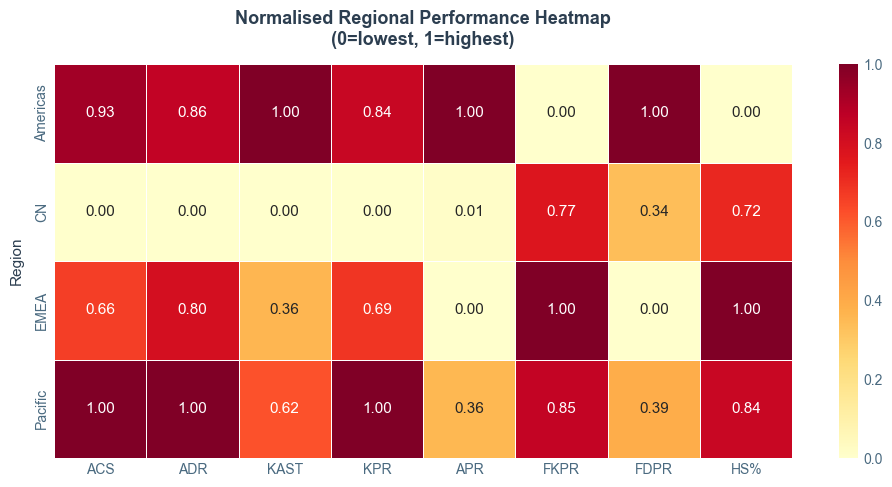

In [18]:
from sklearn.preprocessing import MinMaxScaler

fig, ax = plt.subplots(figsize=(10, 5))
heatmap_data = combined_df.groupby('Region')[['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']].mean()
scaler = MinMaxScaler()
heatmap_normalised = pd.DataFrame(scaler.fit_transform(heatmap_data),
                                   index=heatmap_data.index,
                                   columns=heatmap_data.columns)
sns.heatmap(heatmap_normalised, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Normalised Regional Performance Heatmap\n(0=lowest, 1=highest)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regional_heatmap.png', dpi=150)
plt.show()

<!-- VCT-POLISH: BANNER -->
<a id='section10'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">10</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Distribution Violin Plots</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Violin plots show the full distribution of KAST% and HS% by region, combining a box plot with a density curve. This reveals not just the average but the spread and shape of each region's performance.</div></div>

**What this shows:** The shape of each region's player distribution for the two key metrics. A wide violin at a value means many players cluster there. The white dot is the median and the thick bar shows the interquartile range (middle 50% of players).

**How it relates to regional playstyle:** For KAST%, CN's violin sits noticeably lower than the others — lower round participation is widespread across the region, not just a few outliers. For HS%, Americas' violin is shifted left compared to other regions, showing the lower headshot rate is consistent across the whole roster. These distribution shapes are the evidence behind the statistical results in Section 8.

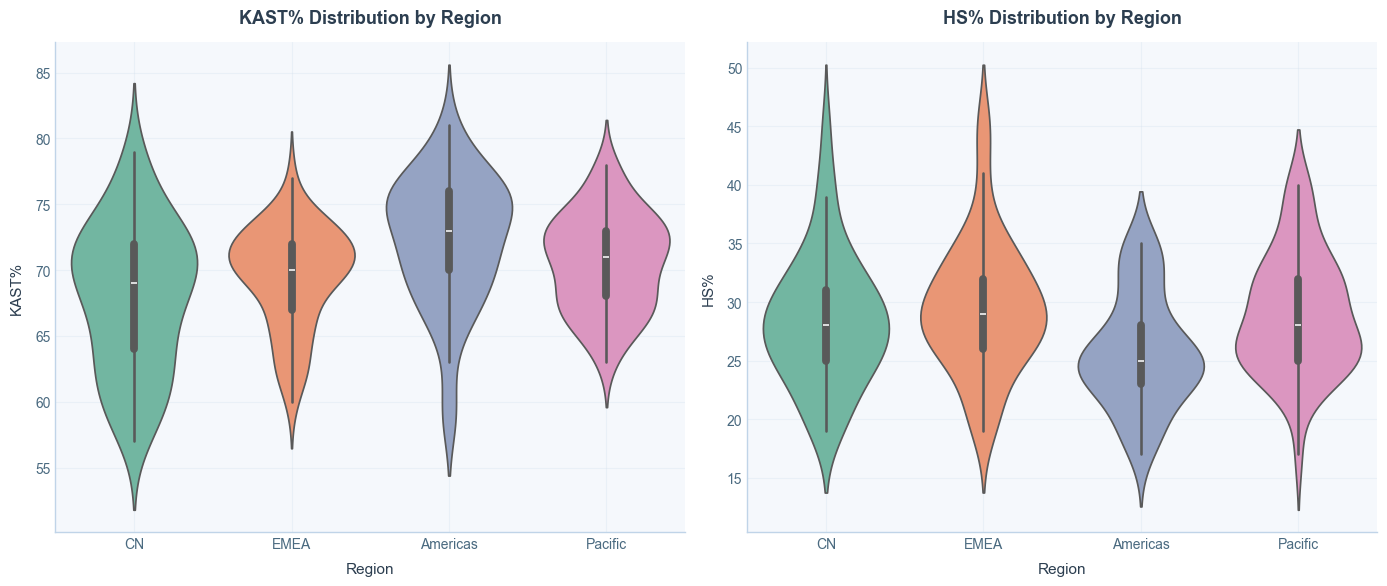

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=combined_df, x='Region', y='KAST', hue='Region',
               palette='Set2', ax=axes[0], inner='box', legend=False)
axes[0].set_title('KAST% Distribution by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region', fontsize=11)
axes[0].set_ylabel('KAST%', fontsize=11)
axes[0].grid(True, alpha=0.3)

sns.violinplot(data=combined_df, x='Region', y='HS%', hue='Region',
               palette='Set2', ax=axes[1], inner='box', legend=False)
axes[1].set_title('HS% Distribution by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region', fontsize=11)
axes[1].set_ylabel('HS%', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('violin_plots.png', dpi=150)
plt.show()

## Dissertation Figures Export

Run this cell to generate static figure files for the dissertation (kast_hs_boxplots.png, all_metrics_bar.png). These supplement the violin plots and heatmap already exported by Sections 9 and 10.

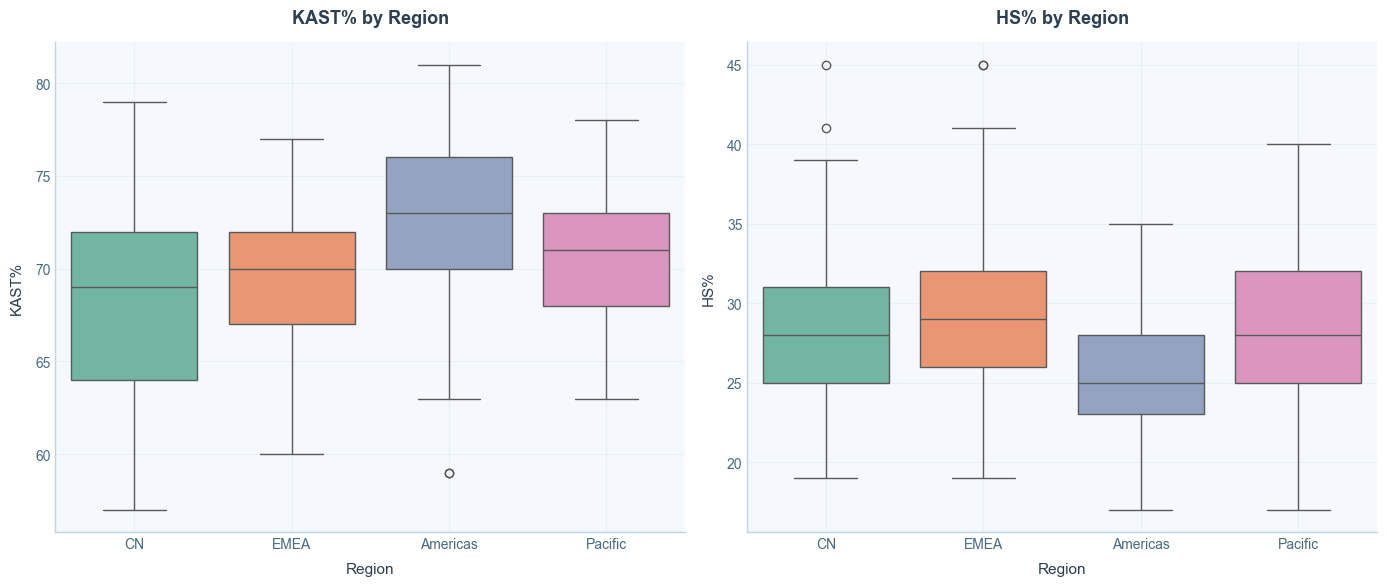

Saved: kast_hs_boxplots.png


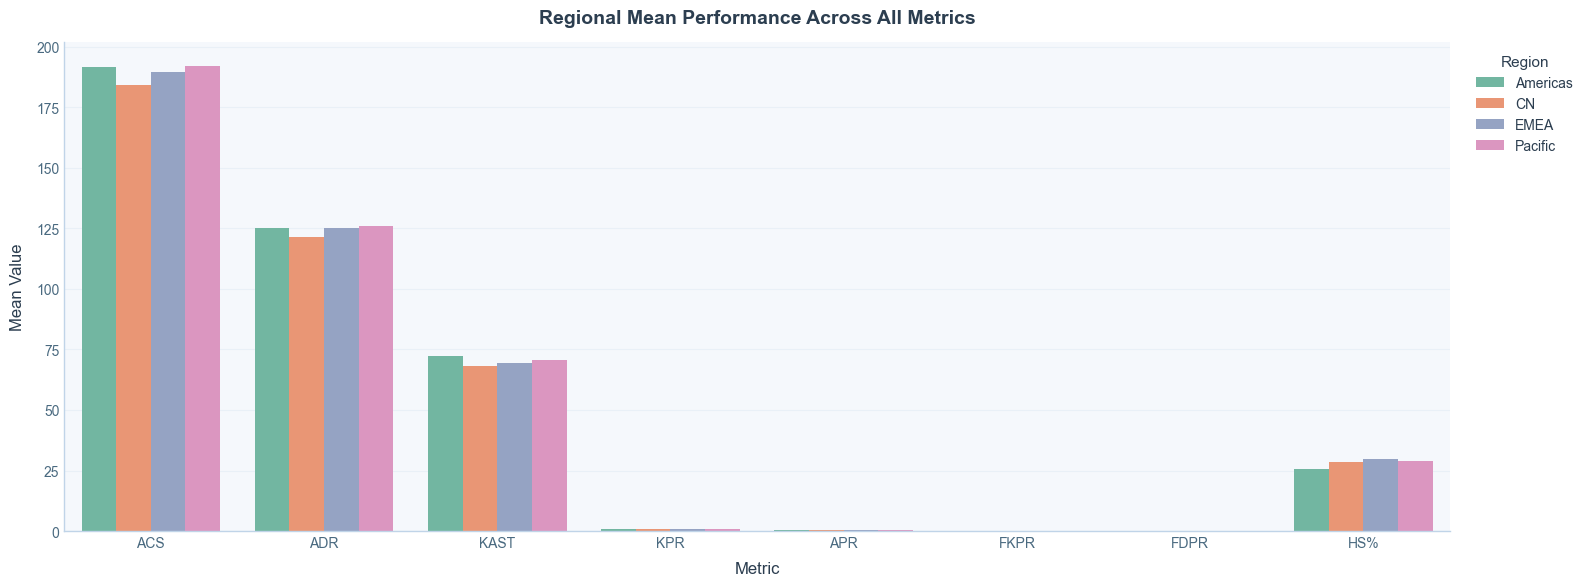

Saved: all_metrics_bar.png


In [20]:
# -- KAST% and HS% box plots by region --
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=combined_df, x='Region', y='KAST', hue='Region',
            palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('KAST% by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region', fontsize=11)
axes[0].set_ylabel('KAST%', fontsize=11)
axes[0].grid(True, alpha=0.3)

sns.boxplot(data=combined_df, x='Region', y='HS%', hue='Region',
            palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('HS% by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region', fontsize=11)
axes[1].set_ylabel('HS%', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kast_hs_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kast_hs_boxplots.png")

# -- All 8 metrics bar chart (regional means) --
metrics = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
region_means = combined_df.groupby('Region')[metrics].mean().reset_index()
region_melted = region_means.melt(id_vars='Region', var_name='Metric', value_name='Mean')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=region_melted, x='Metric', y='Mean', hue='Region',
            palette='Set2', ax=ax)
ax.set_title('Regional Mean Performance Across All Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Mean Value', fontsize=12)
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('all_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_metrics_bar.png")


<!-- VCT-POLISH: BANNER -->
<a id='section11'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">11</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Player Search</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Search for any player by name to see all their stats across events.</div></div>

**What this shows:** The full statistical profile of any individual player across Masters Bangkok, Masters Toronto, and Champions 2025 — useful for tracking how a player's performance changed across tournaments or comparing them against regional averages.

**How it relates to regional playstyle:** Use this to check whether a player fits their region's statistical profile. A top CN player should show high HS% and lower KAST% consistent with the regional pattern — or reveal whether they are an outlier who bucks the trend.

In [21]:
search_widget = widgets.Text(placeholder='Type player name e.g. aspas', description='Player:', continuous_update=False)
event_widget_search = widgets.Dropdown(
    options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'],
    value='All', description='Event')
search_out = widgets.Output()

colour_legend_html = """
<div style="margin: 12px 0 8px 0; font-family: Arial, sans-serif; background-color: #e8eef5; padding: 10px 14px; border-radius: 8px; border-left: 4px solid #4a6a80; font-size: 12px; color: #555;">
    <strong style="color:#2c3e50;">Row colour = Region:</strong>&nbsp;&nbsp;
    <span style="background:#d8f0e2; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ Americas</span>&nbsp;
    <span style="background:#f8e0e0; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ EMEA</span>&nbsp;
    <span style="background:#dce6f0; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ Pacific</span>&nbsp;
    <span style="background:#f8f0d8; color:#1a2535; padding:2px 8px; border-radius:4px; font-weight:bold;">■ CN</span>
    &nbsp;&nbsp;| Type a player name below to search, or leave blank to see all players.
</div>
"""

display(HTML(colour_legend_html))

def on_search(change):
    search_out.clear_output()
    with search_out:
        query = search_widget.value.strip().lower()
        event = event_widget_search.value

        df = combined_df.copy()
        if event != 'All':
            df = df[df['Event'] == event]

        if not query:
            players = df[['Player', 'Team', 'Region', 'Event']].drop_duplicates().sort_values('Player')
            rows = ''
            for _, row in players.iterrows():
                bg = '#253530' if row['Region'] == 'Americas' else '#3a2828' if row['Region'] == 'EMEA' else '#252e3a' if row['Region'] == 'Pacific' else '#3a3020'
                rows += f"<tr><td style='padding:6px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535;'>{row['Player']}</td><td style='padding:6px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;'>{row['Team']}</td><td style='padding:6px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;'>{row['Region']}</td><td style='padding:6px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;'>{row['Event']}</td></tr>"
            display(HTML(f"""
            <div style="font-family:Arial; font-size:13px; color:#2c3e50; font-weight:bold; margin-bottom:8px;">📋 All Players ({len(players)} total)</div>
            <table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px;">
                <thead><tr>
                    <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Player</th>
                    <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Team</th>
                    <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Region</th>
                    <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Event</th>
                </tr></thead>
                <tbody>{rows}</tbody>
            </table>"""))
            return

        results = df[df['Player'].str.lower().str.contains(query)]

        if results.empty:
            display(HTML(f"<div style='font-family:Arial; color:#a04040; font-size:13px;'>❌ No players found matching '<strong>{query}</strong>'</div>"))
            return

        display(HTML(f"<div style='font-family:Arial; font-size:13px; color:#2c3e50; font-weight:bold; margin-bottom:8px;'>✅ Found {len(results)} result(s) for '<strong>{query}</strong>'</div>"))

        # Chart
        metrics_plot = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']
        colors_map = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
        fig, ax = plt.subplots(figsize=(12, 5))
        bar_width = 0.8 / len(results) if len(results) > 1 else 0.4
        x = range(len(metrics_plot))
        for i, (_, row) in enumerate(results.iterrows()):
            values = [row[m] for m in metrics_plot]
            color = colors_map.get(row['Region'], 'grey')
            offset = [xi + i * bar_width - (len(results)-1) * bar_width / 2 for xi in x]
            ax.bar(offset, values, width=bar_width * 0.9, alpha=0.85, color=color,
                  edgecolor='black', label=f"{row['Player']} — {row['Event']}")
        ax.set_xticks(list(x))
        ax.set_xticklabels(metrics_plot, fontsize=11)
        ax.set_title(f"Stats for '{query.title()}'", fontweight='bold', fontsize=13)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Stats table
        rows_html = ''
        for _, row in results.iterrows():
            bg = '#253530' if row['Region'] == 'Americas' else '#3a2828' if row['Region'] == 'EMEA' else '#252e3a' if row['Region'] == 'Pacific' else '#3a3020'
            rows_html += f"""<tr>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; font-weight:bold;">{row['Player']}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Team']}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Region']}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Event']}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{round(row['ACS'],1)}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{round(row['ADR'],1)}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{round(row['KAST'],1)}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{round(row['KPR'],2)}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{round(row['FKPR'],2)}</td>
                <td style="padding:8px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{round(row['HS%'],1)}</td>
            </tr>"""

        table_html = f"""
        <table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px; margin-top:5px;">
            <thead><tr>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Player</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Team</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Region</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Event</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">ACS</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">ADR</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">KAST</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">KPR</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">FKPR</th>
                <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">HS%</th>
            </tr></thead>
            <tbody>{rows_html}</tbody>
        </table>"""

        display(HTML(table_html))

search_widget.observe(on_search, names='value')
event_widget_search.observe(on_search, names='value')
display(widgets.VBox([search_widget, event_widget_search, search_out]))

<!-- VCT-POLISH: BANNER -->
<a id='section12'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">12</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Region vs Region Comparison</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Pick two regions and compare their average performance head to head.</div></div>

**What this shows:** A direct side-by-side bar chart of two regions across all eight metrics, making it easy to see exactly where they differ and where they are similar.

**How it relates to regional playstyle:** The most revealing comparison is CN vs Americas — the two most statistically distinct regions. CN leads on HS% while Americas leads on KAST%, but their ACS and ADR are close. This shows the two regions are equally effective overall but achieve it in completely different ways: CN through precision aim, Americas through consistency and utility coordination.

In [22]:
region1_widget = widgets.Dropdown(options=['Americas', 'EMEA', 'Pacific', 'CN'], value='Americas', description='Region 1')
region2_widget = widgets.Dropdown(options=['Americas', 'EMEA', 'Pacific', 'CN'], value='CN', description='Region 2')
compare_button = widgets.Button(description='Compare', button_style='primary')
compare_out = widgets.Output()

def on_compare(b):
    compare_out.clear_output()
    with compare_out:
        r1 = region1_widget.value
        r2 = region2_widget.value

        if r1 == r2:
            print("Please select two different regions.")
            return

        metrics_compare = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'FDPR', 'HS%']
        df1 = combined_df[combined_df['Region'] == r1][metrics_compare].mean()
        df2 = combined_df[combined_df['Region'] == r2][metrics_compare].mean()

        colors = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
        bg_colors = {
            'Americas': '#d8f0e2', 'EMEA': '#f8e0e0',
            'Pacific': '#d8e8f8', 'CN': '#f8f0d8'
        }

        fig, ax = plt.subplots(figsize=(13, 6))
        x = range(len(metrics_compare))
        width = 0.35
        bars1 = ax.bar([i - width/2 for i in x], df1.values, width,
                      label=r1, color=colors[r1], edgecolor='black', alpha=0.85)
        bars2 = ax.bar([i + width/2 for i in x], df2.values, width,
                      label=r2, color=colors[r2], edgecolor='black', alpha=0.85)
        ax.set_xticks(list(x))
        ax.set_xticklabels(metrics_compare, fontsize=11)
        ax.set_title(f'{r1} vs {r2} — Average Performance Comparison', fontweight='bold', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.2f}', ha='center', fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.2f}', ha='center', fontsize=8)
        plt.tight_layout()
        plt.show()

        # Legend
        legend_html = f"""
        <div style="margin: 15px 0 8px 0; font-family: Arial, sans-serif; background-color: #e8eef5; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #4a6a80;">
            <div style="font-size: 15px; font-weight: bold; color: #2c3e50; margin-bottom: 8px;">
                ⚔️ {r1} vs {r2} — Region Comparison
            </div>
            <div style="font-size: 12px; color: #555; margin-bottom: 6px;">
                Each row shows one metric. <strong style="color: green;">Green</strong> = higher value &nbsp;|&nbsp; <strong style="color: red;">Red</strong> = lower value
            </div>
            <div style="margin-top: 6px;">
                <span style="background-color: {bg_colors[r1]}; color:#1a2535; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ {r1}</span>
                <span style="margin-left: 8px; background-color: {bg_colors[r2]}; color:#1a2535; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ {r2}</span>
            </div>
        </div>
        """
        display(HTML(legend_html))

        # HTML table
        rows_html = ''
        for metric in metrics_compare:
            v1 = round(df1[metric], 2)
            v2 = round(df2[metric], 2)
            winner = r1 if v1 > v2 else r2
            c_v1 = 'color: #3a7858; font-weight: bold;' if v1 > v2 else 'color: #905050; font-weight: bold;' if v1 < v2 else 'color:#1a2535;'
            c_v2 = 'color: #3a7858; font-weight: bold;' if v2 > v1 else 'color: #905050; font-weight: bold;' if v2 < v1 else 'color:#1a2535;'
            rows_html += f"""
            <tr>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; color:#1a2535; font-weight: bold;">{metric}</td>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; text-align: center; {c_v1}">{v1}</td>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; text-align: center; {c_v2}">{v2}</td>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; text-align: center; color: #2c3e50; font-weight: bold;">{winner}</td>
            </tr>"""

        table_html = f"""
        <table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 12px; margin-top: 10px;">
            <thead>
                <tr>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">Metric</th>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">{r1}</th>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">{r2}</th>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">Winner</th>
                </tr>
            </thead>
            <tbody>{rows_html}</tbody>
        </table>
        """
        display(HTML(table_html))

compare_button.on_click(on_compare)
display(widgets.VBox([region1_widget, region2_widget, compare_button, compare_out]))

<!-- VCT-POLISH: BANNER -->
<a id='section13'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">13</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Team Comparison</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Pick two teams and compare their average stats side by side.</div></div>

**What this shows:** Roster-level stats for two specific teams across all metrics — more granular than the region comparison which shows regional averages.

**How it relates to regional playstyle:** Teams from the same region may still differ from each other — not every CN team has low KAST%, and not every Americas team has low HS%. This section lets you check whether a team fits or breaks the typical profile for its region, revealing the depth of individual team identities within the broader regional trends.

In [23]:
all_teams = sorted(combined_df['Team'].unique().tolist())
team1_widget = widgets.Dropdown(options=all_teams, value='MIBR', description='Team 1')
team2_widget = widgets.Dropdown(options=all_teams, value='T1', description='Team 2')
event_widget_team = widgets.Dropdown(
    options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'],
    value='All', description='Event')
team_button = widgets.Button(description='Compare Teams', button_style='primary')
team_out = widgets.Output()

def on_team_compare(b):
    team_out.clear_output()
    with team_out:
        t1 = team1_widget.value
        t2 = team2_widget.value
        event = event_widget_team.value

        if t1 == t2:
            print("Please select two different teams.")
            return

        df = combined_df.copy()
        if event != 'All':
            df = df[df['Event'] == event]

        metrics_compare = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'FDPR', 'HS%']
        df1 = df[df['Team'] == t1][metrics_compare].mean()
        df2 = df[df['Team'] == t2][metrics_compare].mean()

        if df1.isna().all():
            print(f"{t1} did not participate in {event}.")
            return
        if df2.isna().all():
            print(f"{t2} did not participate in {event}.")
            return

        colors_map = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
        r1 = combined_df[combined_df['Team'] == t1]['Region'].iloc[0]
        r2 = combined_df[combined_df['Team'] == t2]['Region'].iloc[0]
        c1 = colors_map.get(r1, 'grey')
        c2 = colors_map.get(r2, 'grey')

        fig, ax = plt.subplots(figsize=(13, 6))
        x = range(len(metrics_compare))
        width = 0.35
        bars1 = ax.bar([i - width/2 for i in x], df1.values, width,
                      label=f"{t1} ({r1})", color=c1, edgecolor='black', alpha=0.85)
        bars2 = ax.bar([i + width/2 for i in x], df2.values, width,
                      label=f"{t2} ({r2})", color=c2, edgecolor='black', alpha=0.85)
        ax.set_xticks(list(x))
        ax.set_xticklabels(metrics_compare, fontsize=11)
        ax.set_title(f'{t1} vs {t2} — {event}', fontweight='bold', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.2f}', ha='center', fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.2f}', ha='center', fontsize=8)
        plt.tight_layout()
        plt.show()

        bg1 = '#253530' if r1 == 'Americas' else '#3a2828' if r1 == 'EMEA' else '#252e3a' if r1 == 'Pacific' else '#3a3020'
        bg2 = '#253530' if r2 == 'Americas' else '#3a2828' if r2 == 'EMEA' else '#252e3a' if r2 == 'Pacific' else '#3a3020'

        legend_html = f"""
        <div style="margin: 15px 0 8px 0; font-family: Arial, sans-serif; background-color: #e8eef5; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #4a6a80;">
            <div style="font-size: 15px; font-weight: bold; color: #2c3e50; margin-bottom: 8px;">
                ⚔️ {t1} vs {t2} — {event}
            </div>
            <div style="font-size: 12px; color: #555; margin-bottom: 6px;">
                Each row shows one metric. <strong style="color: green;">Green</strong> = higher value &nbsp;|&nbsp; <strong style="color: red;">Red</strong> = lower value
            </div>
            <div style="margin-top: 6px;">
                <span style="background-color: {bg1}; color:#1a2535; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ {t1} ({r1})</span>
                <span style="margin-left: 8px; background-color: {bg2}; color:#1a2535; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ {t2} ({r2})</span>
            </div>
        </div>
        """
        display(HTML(legend_html))

        # Build HTML table manually for full colour control
        rows_html = ''
        for metric in metrics_compare:
            v1 = round(df1[metric], 2)
            v2 = round(df2[metric], 2)
            winner = t1 if v1 > v2 else t2
            c_v1 = 'color: #3a7858; font-weight: bold;' if v1 > v2 else 'color: #905050; font-weight: bold;' if v1 < v2 else 'color:#1a2535;'
            c_v2 = 'color: #3a7858; font-weight: bold;' if v2 > v1 else 'color: #905050; font-weight: bold;' if v2 < v1 else 'color:#1a2535;'
            rows_html += f"""
            <tr>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; color:#1a2535; font-weight: bold;">{metric}</td>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; text-align: center; {c_v1}">{v1}</td>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; text-align: center; {c_v2}">{v2}</td>
                <td style="padding: 8px 14px; border: 1px solid #c0d4e8; background-color: white; text-align: center; color: #2c3e50; font-weight: bold;">{winner}</td>
            </tr>"""

        table_html = f"""
        <table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 12px; margin-top: 10px;">
            <thead>
                <tr>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">Metric</th>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">{t1}</th>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">{t2}</th>
                    <th style="background-color: #4a6a80; color: white; padding: 8px 14px; text-align: center; border: 1px solid #c0d4e8;">Winner</th>
                </tr>
            </thead>
            <tbody>{rows_html}</tbody>
        </table>
        """
        display(HTML(table_html))

team_button.on_click(on_team_compare)
display(widgets.VBox([team1_widget, team2_widget, event_widget_team, team_button, team_out]))

<!-- VCT-POLISH: BANNER -->
<a id='section14'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">14</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Performance Distribution</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">See how a metric is distributed across all players as a histogram, with regional breakdowns.</div></div>

**What this shows:** How values of a chosen metric spread across all 183 players. Each bar represents a value range and the height shows how many players fall there. The regional colour overlay shows which regions contribute most players at each range.

**How it relates to regional playstyle:** For HS%, Americas players concentrate at the lower end while CN players appear more at the higher end. This distributional view confirms the regional difference is not caused by one or two outliers — it reflects a genuine shift in typical values across the whole region.

In [24]:
@interact(
    Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Bins=widgets.IntSlider(min=10, max=40, step=5, value=20, description='Detail')
)
def performance_distribution(Metric, Bins):
    metric_names = {
        'ACS': 'Average Combat Score', 'ADR': 'Average Damage per Round',
        'KAST': 'Kill/Assist/Survive/Trade %', 'KPR': 'Kills per Round',
        'APR': 'Assists per Round', 'FKPR': 'First Kills per Round',
        'FDPR': 'First Deaths per Round', 'HS%': 'Headshot %'
    }
    full_name = metric_names.get(Metric, Metric)
    colors = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Distribution of {full_name} ({Metric})', fontsize=15, fontweight='bold', y=1.02)

    data = combined_df[Metric].dropna()
    mean_val = data.mean()
    median_val = data.median()
    axes[0].hist(data, bins=Bins, color='#a0b8dc', edgecolor='#c0d4e8', alpha=0.85, linewidth=0.5)
    axes[0].axvline(mean_val, color='#e05060', linestyle='--', linewidth=2, label=f'Average: {mean_val:.1f}')
    axes[0].axvline(median_val, color='#e09030', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[0].set_title('All Players Combined', fontweight='bold', fontsize=13, pad=10)
    axes[0].set_xlabel(f'{Metric} — {full_name}', fontsize=11)
    axes[0].set_ylabel('Number of Players', fontsize=11)
    axes[0].legend(fontsize=10, framealpha=0.9)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    for region, group in combined_df.groupby('Region'):
        axes[1].hist(group[Metric].dropna(), bins=Bins, alpha=0.55,
                    label=f"{region} (avg: {group[Metric].mean():.1f})",
                    color=colors.get(region, 'grey'), edgecolor='white', linewidth=0.5)
    axes[1].set_title('Broken Down by Region', fontweight='bold', fontsize=13, pad=10)
    axes[1].set_xlabel(f'{Metric} — {full_name}', fontsize=11)
    axes[1].set_ylabel('Number of Players', fontsize=11)
    axes[1].legend(title='Region (with average)', fontsize=10, framealpha=0.9)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# Metric label + colour legend
    legend_html = f"""
    <div style="margin: 20px 0 10px 0; font-family: Arial, sans-serif; background-color: #e8eef5; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #4a6a80;">
        <div style="font-size: 15px; font-weight: bold; color: #2c3e50; margin-bottom: 10px;">
            📊 Showing: {full_name} ({Metric})
        </div>
        <div style="font-size: 12px; color: #555; margin-bottom: 6px;">
            <strong>Each row represents one VCT region.</strong> Columns show how that region's players performed on average across all three 2025 tournaments.
        </div>
        <div style="margin-top: 8px;">
            <span style="font-size: 12px; color: #555; font-weight: bold;">Row colour = Region:&nbsp;&nbsp;</span>
            <span style="background-color: #d8f0e2; color: #3a6848; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ Americas</span>
            <span style="margin-left: 6px; background-color: #f8e0e0; color: #784848; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ EMEA</span>
            <span style="margin-left: 6px; background-color: #d8e8f8; color: #3a5878; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ Pacific</span>
            <span style="margin-left: 6px; background-color: #f8f0d8; color: #786040; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ CN</span>
            <span style="margin-left: 6px; background-color: #dce8f5; color: #424949; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ Overall</span>
        </div>
        <div style="margin-top: 8px; font-size: 12px; color: #555;">
            <span style="color: #3a7858; font-weight: bold;">● Green text</span> = highest value in that column &nbsp;&nbsp;
            <span style="color: #905050; font-weight: bold;">● Red text</span> = lowest value in that column
        </div>
    </div>
    """
    display(HTML(legend_html))

    # Build summary data
    summary_data = []
    for region, group in combined_df.groupby('Region'):
        d = group[Metric].dropna()
        summary_data.append({
            'Region': region,
            'Average': round(d.mean(), 2),
            'Median': round(d.median(), 2),
            'Lowest': round(d.min(), 2),
            'Highest': round(d.max(), 2),
            'Std Dev': round(d.std(), 2),
            'Players': int(len(d))
        })

    overall = combined_df[Metric].dropna()
    summary_data.append({
        'Region': 'Overall',
        'Average': round(overall.mean(), 2),
        'Median': round(overall.median(), 2),
        'Lowest': round(overall.min(), 2),
        'Highest': round(overall.max(), 2),
        'Std Dev': round(overall.std(), 2),
        'Players': int(len(overall))
    })

    summary_df = pd.DataFrame(summary_data).set_index('Region')

    region_colors = {
        'Americas': '#d8f0e2',
        'CN': '#f8f0d8',
        'EMEA': '#f8e0e0',
        'Pacific': '#d8e8f8',
        'Overall': '#dce8f5'
    }

    numeric_cols = ['Average', 'Median', 'Lowest', 'Highest', 'Std Dev']
    max_vals = summary_df[numeric_cols].iloc[:-1].max()
    min_vals = summary_df[numeric_cols].iloc[:-1].min()

    def style_cells(val, col):
        if col not in numeric_cols:
            return 'color:#1a2535'
        if val == max_vals[col]:
            return 'color: green; font-weight: bold'
        if val == min_vals[col]:
            return 'color: red; font-weight: bold'
        return 'color:#1a2535'

    def highlight_rows(row):
        color = region_colors.get(row.name, 'white')
        weight = 'bold' if row.name == 'Overall' else 'normal'
        return [f'background-color: {color}; font-weight: {weight}'] * len(row)

    styled = summary_df.style.apply(highlight_rows, axis=1)

    for col in numeric_cols:
        styled = styled.map(lambda val, c=col: style_cells(val, c), subset=[col])

    styled = styled.set_caption(f'{full_name} ({Metric}) — Regional Summary') \
        .set_table_styles([
            {'selector': 'caption', 'props': [
                ('font-size', '14px'), ('font-weight', 'bold'),
                ('padding', '10px'), ('color', 'black')]},
            {'selector': 'th', 'props': [
                ('background-color', '#4a6a80'), ('color', 'white'),
                ('font-size', '12px'), ('padding', '8px 14px'),
                ('text-align', 'center'), ('border', '1px solid #ccc')]},
            {'selector': 'td', 'props': [
                ('padding', '8px 14px'), ('text-align', 'center'),
                ('font-size', '12px'), ('border', '1px solid #ddd')]},
            {'selector': 'tr:hover td', 'props': [('opacity', '0.85')]}
        ])

    display(styled)

interactive(children=(Dropdown(description='Metric', options=('ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDP…

<!-- VCT-POLISH: BANNER -->
<a id='section15'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">15</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Map Pick Analysis</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Explore which maps were picked most across all three VCT 2025 tournaments, broken down by event and region.</div></div>

**What this shows:** How often each map appears in matches, and how map preferences vary by region and tournament. Teams pick maps that suit their playstyle and ban maps they struggle on, so this data reveals strategic preferences beyond just player stats.

**How it relates to regional playstyle:** Open maps with long sightlines tend to favour high-HS% precision teams like CN. Tight maps with multiple chokepoints favour utility-heavy teams like Americas and EMEA. Regional map preferences add a tactical layer to the playstyle story told by the player stats in earlier sections.

In [25]:
all_teams_list = sorted(combined_df["Team"].unique().tolist())

@interact(
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All'),
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Team=widgets.Dropdown(options=['All'] + all_teams_list, value='All')
)
def map_analysis(Event, Region, Team):
    df = maps_df.copy()

    if Event != 'All':
        df = df[df['Event'] == Event]

    if Region != 'All':
        df = df[(df['Region1'] == Region) | (df['Region2'] == Region)]

    if Team != 'All':
        df = df[(df['Team1'] == Team) | (df['Team2'] == Team)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    map_counts = df['Map'].value_counts()
    colors_map = plt.cm.Set3.colors
    axes[0].bar(map_counts.index, map_counts.values,
               color=colors_map[:len(map_counts)], edgecolor='black')
    axes[0].set_title('Map Pick Frequency', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Map', fontsize=11)
    axes[0].set_ylabel('Times Picked', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    for i, (map_name, count) in enumerate(map_counts.items()):
        axes[0].text(i, count + 0.3, str(count), ha='center', fontsize=9, fontweight='bold')

    event_map = df.groupby(['Event', 'Map']).size().unstack(fill_value=0)
    event_map.plot(kind='bar', ax=axes[1], edgecolor='black')
    axes[1].set_title('Map Picks by Event', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Event', fontsize=11)
    axes[1].set_ylabel('Times Picked', fontsize=11)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend(title='Map', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    summary = df.groupby('Map').agg(
        Times_Picked=('Map', 'count'),
        Avg_Score_Team1=('Score1', 'mean'),
        Avg_Score_Team2=('Score2', 'mean')
    ).round(1).sort_values('Times_Picked', ascending=False).reset_index()

    rows_html = ''
    colors_list = ['#253530', '#3a2828', '#252e3a', '#3a3020', '#261e30',
                   '#d8e8f8', '#f8e0e0', '#f8f0d8', '#d8f0e2', '#f0e8f8', '#e8f8f0']
    for i, row in summary.iterrows():
        bg = colors_list[i % len(colors_list)]
        rows_html += f"""
        <tr>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; font-weight:bold;">{row['Map']}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center; font-weight:bold;">{int(row['Times_Picked'])}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{row['Avg_Score_Team1']}</td>
            <td style="padding:8px 14px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{row['Avg_Score_Team2']}</td>
        </tr>"""

    # Team win rates per map
    all_teams = pd.concat([
        df[['Team1', 'Region1', 'Map', 'Score1', 'Score2']].rename(columns={'Team1': 'Team', 'Region1': 'Region', 'Score1': 'TeamScore', 'Score2': 'OppScore'}),
        df[['Team2', 'Region2', 'Map', 'Score2', 'Score1']].rename(columns={'Team2': 'Team', 'Region2': 'Region', 'Score2': 'TeamScore', 'Score1': 'OppScore'})
    ])

    if Team != 'All':
        all_teams = all_teams[all_teams['Team'] == Team]

    all_teams['Won'] = all_teams['TeamScore'] > all_teams['OppScore']
    team_map_stats = all_teams.groupby(['Team', 'Region', 'Map']).agg(
        Played=('Won', 'count'),
        Wins=('Won', 'sum')
    ).reset_index()
    team_map_stats['Win Rate'] = (team_map_stats['Wins'] / team_map_stats['Played'] * 100).round(1).astype(str) + '%'
    team_map_stats = team_map_stats.sort_values(['Map', 'Wins'], ascending=[True, False])

    bg_region = {'Americas': '#d8f0e2', 'EMEA': '#f8e0e0', 'Pacific': '#d8e8f8', 'CN': '#f8f0d8'}
    team_rows_html = ''
    for _, row in team_map_stats.iterrows():
        bg = bg_region.get(row['Region'], 'white')
        team_rows_html += f"""
        <tr>
            <td style="padding:7px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; font-weight:bold;">{row['Team']}</td>
            <td style="padding:7px 12px; border:1px solid #c0d4e8; background:{bg}; color:#1a2535; text-align:center;">{row['Region']}</td>
            <td style="padding:7px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{row['Map']}</td>
            <td style="padding:7px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{int(row['Played'])}</td>
            <td style="padding:7px 12px; border:1px solid #c0d4e8; background:white; color:#1a2535; text-align:center;">{int(row['Wins'])}</td>
            <td style="padding:7px 12px; border:1px solid #c0d4e8; background:white; color:#2d9060; text-align:center; font-weight:bold;">{row['Win Rate']}</td>
        </tr>"""

    display(HTML(f"""
    <div style="margin:20px 0 8px 0; font-family:Arial; font-size:13px; font-weight:bold; color:#2c3e50;">
        🏆 Team Win Rates per Map{f' — {Team}' if Team != 'All' else ''}
    </div>
    <div style="margin-bottom:8px; font-family:Arial; font-size:12px; color:#3a5060;">
        <span style="background:#d8f0e2; padding:2px 8px; border-radius:4px; font-weight:bold; color:#1a2535;">■ Americas</span>&nbsp;
        <span style="background:#f8e0e0; padding:2px 8px; border-radius:4px; font-weight:bold; color:#1a2535;">■ EMEA</span>&nbsp;
        <span style="background:#dce6f0; padding:2px 8px; border-radius:4px; font-weight:bold; color:#1a2535;">■ Pacific</span>&nbsp;
        <span style="background:#f8f0d8; padding:2px 8px; border-radius:4px; font-weight:bold; color:#1a2535;">■ CN</span>
    </div>
    <table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:12px; margin-bottom:20px;">
        <thead><tr>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8;">Team</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Region</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Map</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Played</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Wins</th>
            <th style="background:#4a6a80; color:white; padding:8px 12px; border:1px solid #c0d4e8; text-align:center;">Win Rate</th>
        </tr></thead>
        <tbody>{team_rows_html}</tbody>
    </table>
    """))
    display(HTML(f"""
    <div style="margin:12px 0 8px 0; font-family:Arial; font-size:13px; font-weight:bold; color:#2c3e50;">
        📍 Map Summary — {Event} | Region: {Region} | Team: {Team}
    </div>
    <table style="border-collapse:collapse; width:60%; font-family:Arial; font-size:12px;">
        <thead><tr>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8;">Map</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Times Picked</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Avg Score (Team 1)</th>
            <th style="background:#4a6a80; color:white; padding:8px 14px; border:1px solid #c0d4e8; text-align:center;">Avg Score (Team 2)</th>
        </tr></thead>
        <tbody>{rows_html}</tbody>
    </table>
    """))

interactive(children=(Dropdown(description='Event', options=('All', 'Masters Bangkok 2025', 'Masters Toronto 2…

<!-- VCT-POLISH: BANNER -->
<a id='section16'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">16</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Player Profile Card</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Select any player to view a full performance breakdown card with stats vs their regional average.</div></div>

In [26]:
# -- Player Profile Card --

REGION_COLORS = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
METRICS = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']

player_dd = widgets.Dropdown(
    options=sorted(combined_df['Player'].unique()),
    description='Player:',
    layout=widgets.Layout(width='300px')
)
event_dd = widgets.Dropdown(
    options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'],
    value='All',
    description='Event:',
    layout=widgets.Layout(width='300px')
)
out_profile = widgets.Output()

def make_card(row, rc, region, reg_avg, show_badge):
    def bar(metric):
        val = float(row[metric]) if pd.notna(row[metric]) else 0
        avg = float(reg_avg[metric]) if pd.notna(reg_avg[metric]) else 0
        mx  = float(combined_df[metric].max()) or 1
        pct = min(val / mx * 100, 100)
        diff = val - avg
        ds = ('+' if diff >= 0 else '') + f'{diff:.2f}'
        dc = '#a8d4b0' if diff >= 0 else '#dfa8a8'
        return (
            f"<div style='margin-bottom:9px;'>"+
            f"<div style='display:flex;justify-content:space-between;margin-bottom:2px;'>"+
            f"<span style='color:#4a6a80;font-size:12px;'>{metric}</span>"+
            f"<span style='color:#1a2535;font-size:12px;font-weight:bold;'>{val:.2f} "+
            f"<span style='color:{dc};font-size:11px;'>({ds} vs reg avg)</span></span>"+
            f"</div>"+
            f"<div style='background:#ffffff;border-radius:4px;height:6px;'>"+
            f"<div style='background:{rc};width:{pct:.1f}%;height:6px;border-radius:4px;'></div>"+
            f"</div></div>"
        )

    badge = (
        f"<span style='background:#e08888;color:#ffffff;font-size:11px;font-weight:700;"+
        f"padding:2px 10px;border-radius:20px;display:inline-block;margin-bottom:10px;'>"+
        f"{row['Event']}</span>"
    ) if show_badge else ''
    agents = row['Agents'] if pd.notna(row.get('Agents')) else 'N/A'
    kd     = row['K:D']    if pd.notna(row.get('K:D'))    else 'N/A'
    bars   = ''.join(bar(m) for m in METRICS)

    return (
        f"<div style='background:#ffffff;border:1px solid #c0d4e8;border-radius:12px;"+
        f"font-family:Segoe UI,sans-serif;overflow:hidden;margin-bottom:14px;'>"+
        f"<div style='background:linear-gradient(135deg,#e8eef5,#f5f8fc);padding:20px 26px;"+
        f"border-bottom:3px solid {rc};display:flex;align-items:center;gap:18px;'>"+
        f"<div style='background:{rc};color:#ffffff;width:50px;height:50px;border-radius:50%;"+
        f"display:flex;align-items:center;justify-content:center;font-size:20px;font-weight:900;"+
        f"flex-shrink:0;'>{row['Player'][0].upper()}</div>"+
        f"<div>"+
        f"<div style='color:#1a2535;font-size:20px;font-weight:800;'>{row['Player']}</div>"+
        f"<div style='color:#4a6a80;font-size:13px;'>{row['Team']} &middot; "+
        f"<span style='color:{rc};'>{region}</span></div>"+
        f"<div style='color:#4a6a80;font-size:12px;margin-top:3px;'>"+
        f"Agents: {agents} &nbsp;|&nbsp; K/D: {kd} &nbsp;|&nbsp; Rounds: {int(row['Rnd'])}"+
        f"</div></div></div>"+
        f"<div style='padding:18px 26px;'>{badge}"+
        f"<div style='color:#e08888;font-size:11px;letter-spacing:3px;text-transform:uppercase;"+
        f"margin-bottom:12px;'>Metrics vs {region} Average</div>"+
        f"{bars}</div></div>"
    )

def show_profile(player, event):
    out_profile.clear_output()
    rows = combined_df[combined_df['Player'] == player]
    if event != 'All':
        rows = rows[rows['Event'] == event]
    if rows.empty:
        with out_profile:
            display(HTML("<span style='color:#c05060;font-family:Segoe UI;'>No data for this player at the selected event.</span>"))
        return
    region  = rows.iloc[0]['Region']
    rc      = REGION_COLORS.get(region, '#888')
    reg_avg = combined_df[combined_df['Region'] == region][METRICS].mean()
    multi   = len(rows) > 1
    html    = ''.join(make_card(row, rc, region, reg_avg, multi) for _, row in rows.iterrows())
    if multi:
        avg = rows[METRICS].mean()
        avg_rows = ''.join(
            f"<div style='display:flex;justify-content:space-between;padding:5px 0;"+
            f"border-bottom:1px solid #d0dce8;'>"+
            f"<span style='color:#4a6a80;font-size:12px;'>{m}</span>"+
            f"<span style='color:#1a2535;font-size:12px;font-weight:bold;'>{avg[m]:.2f}</span>"+
            f"</div>"
            for m in METRICS
        )
        html += (
            f"<div style='background:#ffffff;border:1px solid #e08888;border-radius:12px;"+
            f"font-family:Segoe UI,sans-serif;overflow:hidden;margin-bottom:14px;'>"+
            f"<div style='background:linear-gradient(135deg,#e8eef5,#f5f8fc);padding:16px 26px;"+
            f"border-bottom:2px solid #e08888;'>"+
            f"<div style='color:#e08888;font-size:11px;letter-spacing:3px;text-transform:uppercase;'>"+
            f"Overall Average — All Events</div>"+
            f"<div style='color:#1a2535;font-size:16px;font-weight:800;margin-top:4px;'>{player}</div>"+
            f"</div><div style='padding:16px 26px;'>{avg_rows}</div></div>"
        )
    with out_profile:
        display(HTML(f"<div style='max-width:700px;'>{html}</div>"))

def _on_player_change(change):
    show_profile(player_dd.value, event_dd.value)

def _on_event_change(change):
    event = change['new']
    if event == 'All':
        new_options = sorted(combined_df['Player'].unique())
    else:
        new_options = sorted(combined_df[combined_df['Event'] == event]['Player'].unique())
    player_dd.unobserve(_on_player_change, names='value')
    player_dd.options = new_options
    if player_dd.value not in new_options:
        player_dd.value = new_options[0] if new_options else player_dd.value
    player_dd.observe(_on_player_change, names='value')
    if player_dd.value:
        show_profile(player_dd.value, event)

player_dd.observe(_on_player_change, names='value')
event_dd.observe(_on_event_change, names='value')
show_profile(player_dd.value, event_dd.value)
display(widgets.VBox([widgets.HBox([player_dd, event_dd]), out_profile]))

<!-- VCT-POLISH: BANNER -->
<a id='section17'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">17</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Performance Fingerprint (Interactive Plotly)</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Fully interactive scatter with hover tooltips, zoom, and pan. Each dot is a player, coloured by region.</div></div>

In [27]:
# ── Plotly Performance Fingerprint ──────────────────────────────────────

REGION_COLORS_HEX = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
METRICS_LIST = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']

x_dd = widgets.Dropdown(options=METRICS_LIST, value='ACS',  description='X Axis:', layout=widgets.Layout(width='220px'))
y_dd = widgets.Dropdown(options=METRICS_LIST, value='ADR',  description='Y Axis:', layout=widgets.Layout(width='220px'))
ev_dd = widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'],
                          value='All', description='Event:', layout=widgets.Layout(width='280px'))
out_fp = widgets.Output()

def draw_fingerprint(x_metric, y_metric, event):
    df = combined_df.copy()
    if event != 'All':
        df = df[df['Event'] == event]
    fig = go.Figure()
    for region, grp in df.groupby('Region'):
        fig.add_trace(go.Scatter(
            x=grp[x_metric], y=grp[y_metric],
            mode='markers',
            name=region,
            marker=dict(color=REGION_COLORS_HEX.get(region,'#888'), size=9, opacity=0.85,
                        line=dict(width=1, color='#e8eef5')),
            text=grp['Player'] + '<br>' + grp['Team'] + '<br>' + grp['Event'],
            customdata=grp[['Player','Team','ACS','ADR','KAST','K:D']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b> &middot; %{customdata[1]}<br>'
                'ACS: %{customdata[2]:.1f} &nbsp; ADR: %{customdata[3]:.1f}<br>'
                'KAST: %{customdata[4]:.1f}% &nbsp; K/D: %{customdata[5]}<br>'
                f'{x_metric}: %{{x:.2f}} &nbsp; {y_metric}: %{{y:.2f}}<extra></extra>'
            )
        ))
    fig.update_layout(
        template='plotly_dark',
        paper_bgcolor='#ffffff',
        plot_bgcolor='#f5f8fc',
        title=dict(text=f'<b>{x_metric} vs {y_metric}</b> — Performance Fingerprint',
                   font=dict(color='#2c3e50', size=16), x=0.05),
        xaxis=dict(title=x_metric, gridcolor='#d0dfec', zeroline=False),
        yaxis=dict(title=y_metric, gridcolor='#d0dfec', zeroline=False),
        legend=dict(bgcolor='#f0f4f8', bordercolor='#b8cfe0', borderwidth=1),
        hoverlabel=dict(bgcolor='#f0f4f8', bordercolor='#e08888', font_size=12),
        height=520,
        margin=dict(l=50, r=30, t=60, b=50),
    )
    with out_fp:
        out_fp.clear_output(wait=True)
        fig.show()

def _on_change(change):
    draw_fingerprint(x_dd.value, y_dd.value, ev_dd.value)

x_dd.observe(_on_change, names='value')
y_dd.observe(_on_change, names='value')
ev_dd.observe(_on_change, names='value')
draw_fingerprint(x_dd.value, y_dd.value, ev_dd.value)
display(widgets.VBox([
    widgets.HBox([x_dd, y_dd, ev_dd]),
    out_fp
]))


<!-- VCT-POLISH: BANNER -->
<a id='section18'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">18</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Tournament Timeline</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Compare average performance per region across each tournament. See how regions peaked or declined event-by-event.</div></div>

In [28]:
# ── Tournament Timeline ──────────────────────────────────────────────────

tl_metric_dd = widgets.Dropdown(
    options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'],
    value='ACS', description='Metric:', layout=widgets.Layout(width='220px')
)
out_tl = widgets.Output()

EVENTS_ORDER = ['Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025']
REGION_COLORS_HEX = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8', 'Pacific': '#a0b8dc', 'CN': '#dcc48a'}

def draw_timeline(metric):
    pivot = (
        combined_df[combined_df['Event'].isin(EVENTS_ORDER)]
        .groupby(['Event', 'Region'])[metric].mean().reset_index()
    )
    fig = go.Figure()
    for region in ['Americas', 'EMEA', 'Pacific', 'CN']:
        sub = pivot[pivot['Region'] == region].set_index('Event').reindex(EVENTS_ORDER)
        fig.add_trace(go.Bar(
            name=region,
            x=EVENTS_ORDER,
            y=sub[metric].values,
            marker_color=REGION_COLORS_HEX.get(region, '#888'),
            hovertemplate=f'<b>{region}</b><br>{metric}: %{{y:.2f}}<extra></extra>'
        ))
    fig.update_layout(
        barmode='group',
        template='plotly_dark',
        paper_bgcolor='#ffffff',
        plot_bgcolor='#f5f8fc',
        title=dict(text=f'<b>Average {metric} by Region — Tournament Timeline</b>',
                   font=dict(color='#2c3e50', size=16), x=0.05),
        xaxis=dict(gridcolor='#d0dfec'),
        yaxis=dict(title=f'Avg {metric}', gridcolor='#d0dfec'),
        legend=dict(bgcolor='#f0f4f8', bordercolor='#b8cfe0', borderwidth=1),
        hoverlabel=dict(bgcolor='#f0f4f8', bordercolor='#e08888', font_size=12),
        height=460,
        margin=dict(l=50, r=30, t=60, b=50),
    )
    with out_tl:
        out_tl.clear_output(wait=True)
        fig.show()

tl_metric_dd.observe(lambda c: draw_timeline(c['new']), names='value')
draw_timeline(tl_metric_dd.value)
display(widgets.VBox([tl_metric_dd, out_tl]))


<!-- VCT-POLISH: BANNER -->
<a id='section19'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">19</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Player Insights & Regional Improvement Recommendations</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">This section offers coaching-style insights derived from the statistical findings of this project, written from the perspective of a competitive Valorant player. Unlike raw stats tables available on VLR.gg, these insights translate the data into **actionable advice** — what the numbers mean for how you should play against each region, or how to develop your own game if you play in one of these regions.</div></div>

Select your region to see tailored insights based on your region's statistical profile.

In [30]:
REGION_INSIGHTS = {
    'Americas': {
        'colour': '#e08888',
        'profile': 'Low HS% · Reliable KAST% · Utility-first coordination',
        'what_it_means': (
            'Americas players have the lowest headshot percentage of all four regions. '
            'This reflects a playstyle built around spray control, suppression fire, and '
            'ability usage to win duels rather than single-bullet precision. '
            'This is not a weakness — it describes a team-oriented approach where utility '
            'setup and coordination matter more than individual aim.'
        ),
        'strengths': [
            'Strong utility coordination — rounds won through setup and information, not just aim',
            'Reliable KAST% — consistent round contribution across kills, assists, survival and trades',
            'Controller-heavy compositions provide macro control over site access and timing',
        ],
        'tips': [
            'Work on crosshair placement to raise HS% — even small gains reduce bullets needed to eliminate opponents',
            'Practice counter-strafing and burst control to close the precision gap against CN and Pacific',
            'Use your utility-first identity in ranked: set up for teammates rather than hunting solo frags',
            'Study Gekko and Fade usage — Americas initiators excel at safe information gathering',
        ],
        'scouting': (
            'Expect structured executes and heavy smoke usage. '
            'Americas teams rarely hard push or dry peek — '
            'bait out their utility before committing to a fight.'
        ),
    },
    'EMEA': {
        'colour': '#a0c8f0',
        'profile': 'Balanced across all metrics · No extreme highs or lows',
        'what_it_means': (
            'EMEA players present the most balanced regional profile — no metric sits '
            'significantly above or below the cross-regional median. '
            'This versatility makes EMEA teams highly adaptable: they can match a '
            'precision-aim opponent on HS% or a team-play opponent on KAST% '
            'without being out of their comfort zone.'
        ),
        'strengths': [
            'Adaptability — EMEA players adjust to multiple playstyles within a series',
            'No obvious statistical weaknesses for opponents to exploit',
            'Solid KAST% indicates consistent round contribution across different roles',
        ],
        'tips': [
            'Develop a defined identity — a signature style forces opponents to prepare specifically for you',
            'Push FKPR higher — Pacific leads in raw fragging, closing that opening-duel gap unlocks more round control',
            'Invest in individual aim training to compete with CN and Pacific on HS% in close-range duels',
            'Use tactical flexibility in ranked: read what each round needs and adapt your role accordingly',
        ],
        'scouting': (
            'EMEA teams will adapt mid-series. '
            'Do not assume your counter-strategy from game one holds in game two — '
            'EMEA is the most likely region to make structural adjustments between maps.'
        ),
    },
    'Pacific': {
        'colour': '#f0d070',
        'profile': 'Highest ACS · Highest KPR · Aggressive individual fragging',
        'what_it_means': (
            'Pacific players produce the highest raw individual output of any region, '
            'leading in both ACS and KPR. '
            'This reflects a culture of individual duelling excellence where players are '
            'developed to win one-on-one fights consistently. '
            'Pacific teams win rounds through individual talent as much as through team structure.'
        ),
        'strengths': [
            'Highest individual fragging output globally at VCT international level',
            'Strong duellist play — Pacific carries high-pressure rounds through mechanical skill',
            'Consistent first-kill contribution enables early round control and site access',
        ],
        'tips': [
            'Balance individual aggression with team coordination — KAST% is not the highest, round contributions are missed while hunting frags',
            'Develop trade discipline: ensure teammates are positioned to trade when you entry frag',
            'Manage FDPR — high FKPR is valuable, but reducing unnecessary first deaths makes aggression more efficient',
            'Study CN and Americas utility setups to better protect aggressive players and extend their impact',
        ],
        'scouting': (
            'Expect individual players to break your setups through sheer mechanical skill. '
            'Never give Pacific star players clean duel opportunities — '
            'use flashes, smokes, and crossfires to negate their edge.'
        ),
    },
    'CN': {
        'colour': '#a8d4b0',
        'profile': 'Lowest KAST% · Highest HS% · High-risk precision play',
        'what_it_means': (
            'CN is the most statistically distinct region. '
            'Players have the highest headshot percentage globally but the lowest KAST%. '
            'This combination describes a high-risk, high-reward style: CN players win '
            'duels with precision aim but are less consistently involved in round outcomes. '
            'CN was only integrated into international VCT in 2023, meaning less time '
            'to develop the coordinated team play seen in more established regions.'
        ),
        'strengths': [
            'Highest headshot percentage globally — CN players win aim duels with precision',
            'Unpredictable playstyle makes it harder for opponents to read round structure',
            'Strong mechanical foundation from intensive aim-training culture',
        ],
        'tips': [
            'Focus on KAST%: winning aim duels is not enough if you die without contributing — stay alive and play for trades',
            'Develop utility discipline: smokes, flashes, and mollies support your aim advantage rather than raw skill alone',
            'Study EMEA and Americas team coordination — the KAST% gap shows what can be learned from how other regions structure rounds',
            'In ranked: your aim advantage is real, but position for trades so teammates can continue the round after you die',
        ],
        'scouting': (
            'CN precision is dangerous in clean aim duels — never hold a single angle alone. '
            'Force crossfires, use off-angles, and deploy flashes before peeking. '
            'Their lower KAST% means rounds can snowball against them '
            'if you deny star players clean opportunities.'
        ),
    },
}

@interact(Region=widgets.Dropdown(
    options=['Americas', 'EMEA', 'Pacific', 'CN'],
    value='Americas',
    description='Your Region:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
))
def show_insights(Region='Americas'):
    data = REGION_INSIGHTS[Region]
    colour = data['colour']
    strengths_html = ''.join(
        f'<li style="margin-bottom:7px;color:#4a6a80">{s}</li>'
        for s in data['strengths']
    )
    tips_html = ''.join(
        f'<li style="margin-bottom:7px;color:#4a6a80">{t}</li>'
        for t in data['tips']
    )
    display(HTML(f"""
    <div style='font-family:Segoe UI,sans-serif;max-width:860px;background:#f8fafc;
                border-radius:12px;padding:26px 30px;border-left:5px solid {colour};
                border:1px solid #d0dce8;margin-top:12px;'>
        <h2 style='color:#2c3e50;margin-top:0;font-size:20px;'>
            {Region} <span style='color:{colour}'>&#9632;</span> Playstyle Profile
        </h2>
        <p style='color:#4a6a80;font-size:13px;margin-top:-8px;'>
            <b>Statistical signature:</b> {data['profile']}
        </p>
        <h3 style='color:#2c3e50;font-size:15px;border-bottom:1px solid #d0dce8;padding-bottom:6px;'>
            What the data means
        </h3>
        <p style='color:#4a6a80;line-height:1.8;'>{data['what_it_means']}</p>
        <h3 style='color:#2c3e50;font-size:15px;border-bottom:1px solid #d0dce8;padding-bottom:6px;'>
            Regional strengths
        </h3>
        <ul style='line-height:1.8;padding-left:20px;'>{strengths_html}</ul>
        <h3 style='color:#2c3e50;font-size:15px;border-bottom:1px solid #d0dce8;padding-bottom:6px;'>
            Improvement tips for {Region} players
        </h3>
        <ul style='line-height:1.8;padding-left:20px;'>{tips_html}</ul>
        <div style='background:#eef4fa;border-radius:8px;padding:14px 18px;
                    margin-top:16px;border-left:4px solid {colour};'>
            <b style='color:#2c3e50;font-size:13px;'>Scouting note — playing against {Region}</b>
            <p style='color:#4a6a80;margin:6px 0 0;line-height:1.8;font-size:13px;'>
                {data['scouting']}
            </p>
        </div>
        <p style='color:#8090a0;font-size:11px;margin-top:16px;'>
            Based on Kruskal-Wallis and Mann-Whitney analysis of 183 VCT 2025 international players.
            Coaching insights written by a competitive Valorant player.
        </p>
    </div>
    """))


interactive(children=(Dropdown(description='Your Region:', layout=Layout(width='280px'), options=('Americas', …

<!-- VCT-ELEVATE: CORR-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section20'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">20</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Correlation Heatmap</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Pearson correlations between the eight performance metrics. Strong positive pairs (e.g. ACS &harr; ADR) indicate redundant dimensions; near-zero pairs (e.g. HS% &harr; APR) indicate independent axes of performance.</div></div>

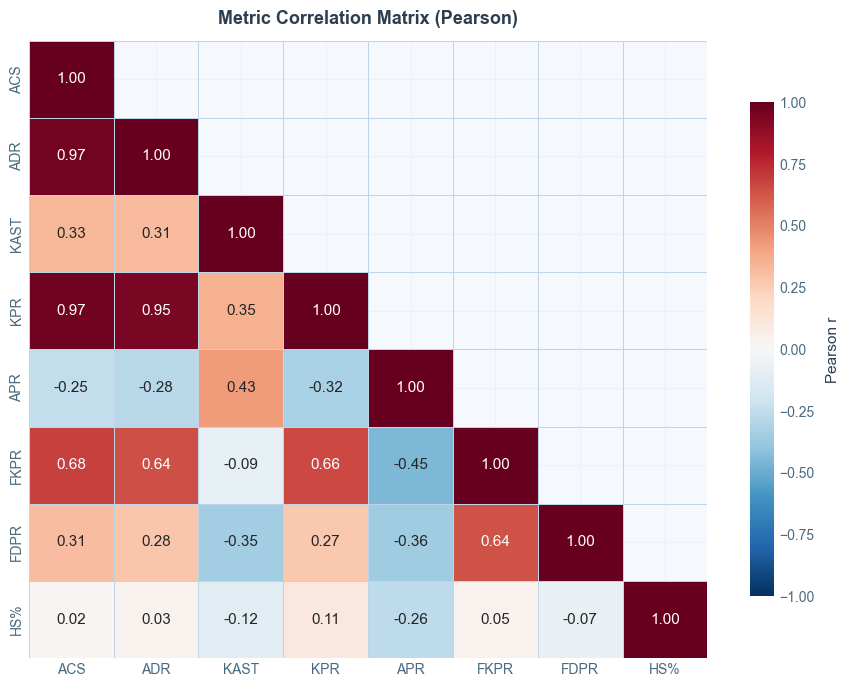

Metric Pair,Pearson r,Strength
ACS · KPR,+0.973,strong
ACS · ADR,+0.968,strong
ADR · KPR,+0.946,strong
ACS · FKPR,+0.683,moderate
KPR · FKPR,+0.659,moderate
ADR · FKPR,+0.642,moderate
FKPR · FDPR,+0.638,moderate
APR · FKPR,-0.452,moderate


In [31]:
# VCT-ELEVATE:CORR
import numpy as np

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
corr = combined_df[METRICS_8].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, linecolor='#c0d4e8',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}, ax=ax,
)
ax.set_title('Metric Correlation Matrix (Pearson)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Top positive/negative pairs (excluding self)
pairs = []
for i in range(len(METRICS_8)):
    for j in range(i + 1, len(METRICS_8)):
        pairs.append((METRICS_8[i], METRICS_8[j], corr.iloc[i, j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)

rows = ''
for a, b, r in pairs[:8]:
    colour = '#3a9060' if r > 0 else '#c05060'
    strength = 'strong' if abs(r) > 0.7 else 'moderate' if abs(r) > 0.4 else 'weak'
    rows += (
        f"<tr>"
        f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
        f"color:#1a2535;font-weight:700;'>{a} &middot; {b}</td>"
        f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
        f"color:{colour};text-align:center;font-weight:700;'>{r:+.3f}</td>"
        f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
        f"color:#4a6a80;text-align:center;'>{strength}</td>"
        f"</tr>"
    ).format(a=a, b=b, colour=colour, r=r, strength=strength)

display(HTML(
    "<div style='font-family:Segoe UI,sans-serif;max-width:640px;margin-top:10px;'>"
    "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
    "border-radius:8px 8px 0 0;padding:12px 18px;'>"
    "<span style='color:#e08888;font-size:11px;letter-spacing:3px;"
    "text-transform:uppercase;'>Top 8 Correlations by Strength</span>"
    "</div>"
    "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
    "<thead><tr>"
    "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 12px;"
    "border:1px solid #c0d4e8;text-align:left;font-size:11px;'>Metric Pair</th>"
    "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 12px;"
    "border:1px solid #c0d4e8;text-align:center;font-size:11px;'>Pearson r</th>"
    "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 12px;"
    "border:1px solid #c0d4e8;text-align:center;font-size:11px;'>Strength</th>"
    "</tr></thead><tbody>" + rows + "</tbody></table></div>"
))


<!-- VCT-ELEVATE: CLUST-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section21'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">21</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Playstyle Clusters (KMeans + PCA)</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Unsupervised grouping of the 183 players by their 8-metric profile. KMeans is run on standardised features; PCA projects the result into 2D for visualisation. Choose *k* to see coarser or finer archetypes.</div></div>

In [32]:
# VCT-ELEVATE:CLUST
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']

k_slider = widgets.IntSlider(value=4, min=3, max=6, step=1, description='k:',
                             continuous_update=False)
out_clust = widgets.Output()

CLUSTER_COLOURS = ['#a8d4b0', '#dfa8a8', '#a0b8dc', '#dcc48a', '#c8a0dc', '#dcb4a0']

def run_clustering(k):
    df = combined_df.dropna(subset=METRICS_8).copy()
    X = df[METRICS_8].values
    Xs = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['Cluster'] = km.fit_predict(Xs)
    pca = PCA(n_components=2)
    pc = pca.fit_transform(Xs)
    df['PC1'] = pc[:, 0]
    df['PC2'] = pc[:, 1]

    with out_clust:
        out_clust.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 6))
        for cid in range(k):
            sub = df[df['Cluster'] == cid]
            ax.scatter(sub['PC1'], sub['PC2'],
                       color=CLUSTER_COLOURS[cid % len(CLUSTER_COLOURS)],
                       edgecolor='#2a3f54', linewidth=0.4, alpha=0.8, s=50,
                       label=f'Cluster {cid} ({len(sub)} players)')
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
                      fontsize=11)
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
                      fontsize=11)
        ax.set_title(f'Playstyle Clusters — k={k}', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Centroid table (inverse-standardised back to metric space)
        centroids = pd.DataFrame(
            StandardScaler().fit(X).inverse_transform(km.cluster_centers_),
            columns=METRICS_8,
        ).round(2)
        centroids.index = [f'Cluster {i}' for i in range(k)]

        # Find the defining metric of each cluster (largest z-score)
        z = km.cluster_centers_
        defining = [METRICS_8[int(np.abs(z[i]).argmax())] for i in range(k)]

        rows = ''
        for i in range(k):
            colour = CLUSTER_COLOURS[i % len(CLUSTER_COLOURS)]
            size = int((df['Cluster'] == i).sum())
            top_regions = (df[df['Cluster'] == i]['Region'].value_counts().head(2))
            reg_str = ', '.join(f'{r} ({n})' for r, n in top_regions.items())
            cells = ''.join(
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;"
                f"background:#ffffff;color:#1a2535;text-align:center;font-size:11px;'>"
                f"{centroids.iloc[i][m]}</td>" for m in METRICS_8
            )
            rows += (
                f"<tr>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;"
                f"background:#ffffff;color:{colour};font-weight:700;'>"
                f"&#9632; Cluster {i}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;"
                f"background:#ffffff;color:#4a6a80;text-align:center;'>{size}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;"
                f"background:#ffffff;color:#1a2535;text-align:center;font-weight:700;'>"
                f"{defining[i]}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;"
                f"background:#ffffff;color:#4a6a80;font-size:11px;'>{reg_str}</td>"
                f"{cells}"
                f"</tr>"
            )

        header_metrics = ''.join(
            f"<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;"
            f"border:1px solid #c0d4e8;text-align:center;font-size:11px;'>{m}</th>"
            for m in METRICS_8
        )
        display(HTML(
            "<div style='font-family:Segoe UI,sans-serif;max-width:1100px;margin-top:10px;'>"
            "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
            "border-radius:8px 8px 0 0;padding:12px 18px;'>"
            "<span style='color:#e08888;font-size:11px;letter-spacing:3px;"
            "text-transform:uppercase;'>Cluster Centroids</span></div>"
            "<div style='overflow-x:auto;'>"
            "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
            "<thead><tr>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;"
            "border:1px solid #c0d4e8;text-align:left;font-size:11px;'>Cluster</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;"
            "border:1px solid #c0d4e8;text-align:center;font-size:11px;'>Size</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;"
            "border:1px solid #c0d4e8;text-align:center;font-size:11px;'>Defining Metric</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;"
            "border:1px solid #c0d4e8;text-align:left;font-size:11px;'>Top Regions</th>"
            + header_metrics +
            "</tr></thead><tbody>" + rows + "</tbody></table></div></div>"
        ))

k_slider.observe(lambda c: run_clustering(c['new']) if c['name'] == 'value' else None)
display(widgets.VBox([k_slider, out_clust]))
run_clustering(k_slider.value)


<!-- VCT-ELEVATE: CLF-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section22'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">22</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Region Classifier (RandomForest)</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Can we predict a player's region purely from their 8 metrics? A random forest is trained on a stratified 70/30 split. Accuracy above the 25% random baseline quantifies how distinguishable the regions really are — complementing the Kruskal-Wallis findings with a predictive measure.</div></div>

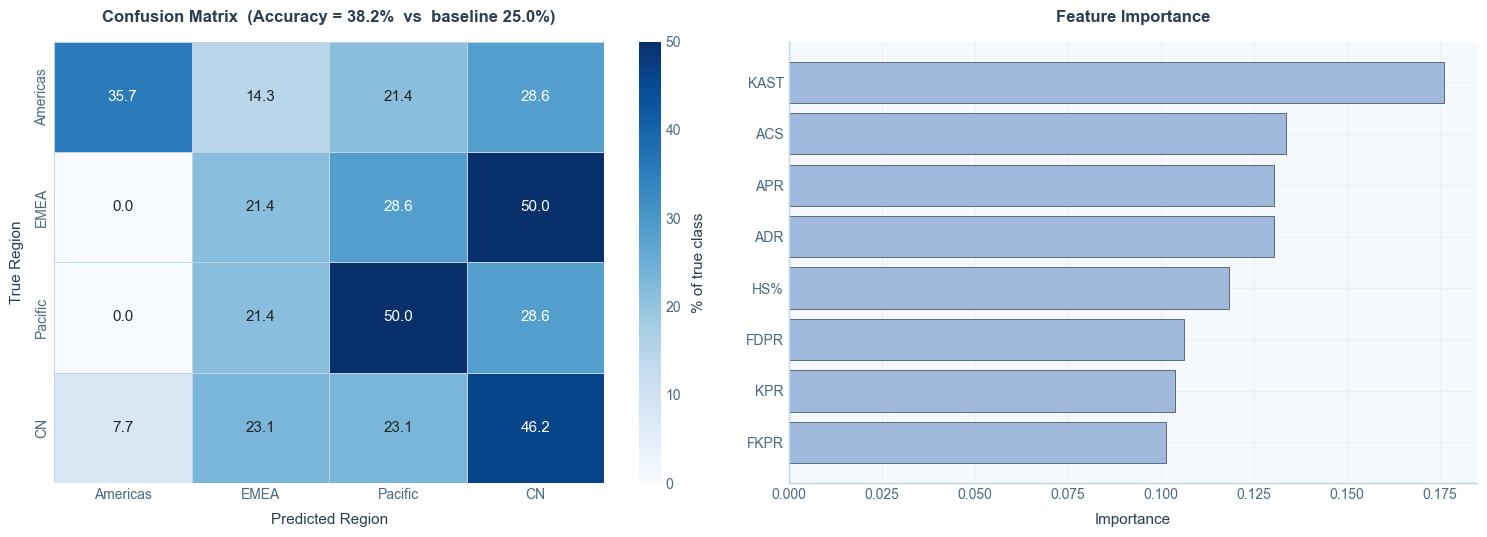

In [33]:
# VCT-ELEVATE:CLF
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
REGIONS_4 = ['Americas', 'EMEA', 'Pacific', 'CN']
REGION_COLOURS = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8',
                  'Pacific': '#a0b8dc', 'CN': '#dcc48a'}

df = combined_df.dropna(subset=METRICS_8 + ['Region']).copy()
df = df[df['Region'].isin(REGIONS_4)]

X = df[METRICS_8].values
y = df['Region'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)
baseline = 1 / len(REGIONS_4)

# Confusion matrix + feature importances
cm = confusion_matrix(y_test, pred, labels=REGIONS_4)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=REGIONS_4, yticklabels=REGIONS_4,
            cbar_kws={'label': '% of true class'},
            linewidths=0.5, linecolor='#c0d4e8', ax=axes[0])
axes[0].set_title(f'Confusion Matrix  (Accuracy = {acc:.1%}  vs  '
                  f'baseline {baseline:.1%})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Region')
axes[0].set_ylabel('True Region')

imp = pd.Series(clf.feature_importances_, index=METRICS_8).sort_values()
axes[1].barh(imp.index, imp.values, color='#a0b8dc',
             edgecolor='#2a3f54', linewidth=0.5)
axes[1].set_title('Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

uplift = acc / baseline
top_feat = imp.idxmax()
display(HTML(
    f"<div style='font-family:Segoe UI,sans-serif;max-width:760px;margin-top:12px;"
    f"background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;"
    f"border-radius:8px;padding:14px 20px;'>"
    f"<div style='color:#e08888;font-size:11px;letter-spacing:3px;"
    f"text-transform:uppercase;margin-bottom:6px;'>Classifier Summary</div>"
    f"<div style='color:#1a2535;font-size:13px;line-height:1.8;'>"
    f"Model: Random Forest (200 trees) &middot; "
    f"Train/Test: 70/30 stratified &middot; "
    f"Features: 8 per-player metrics<br>"
    f"Test accuracy: <b style='color:#3a9060;'>{acc:.1%}</b> "
    f"(<b>{uplift:.1f}&times;</b> the 25% random baseline). "
    f"Most predictive feature: <b>{top_feat}</b>.</div></div>"
))


<!-- VCT-ELEVATE: ROLE-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section23'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">23</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Agent Role Mix by Region</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Every agent belongs to one of four in-game roles: Duellist, Controller, Initiator, Sentinel. Mapping regional agent picks to roles reveals whether regions differ in *what jobs* their players take on, not just how well they perform them.</div></div>

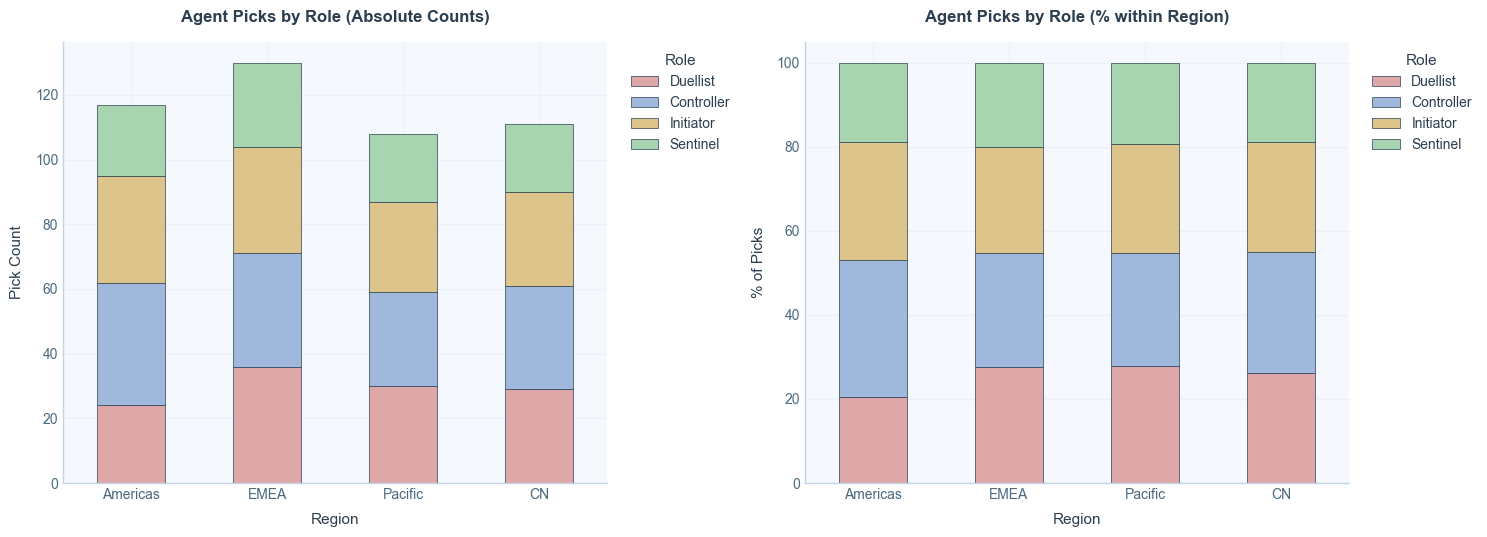

Region,■ Duellist,■ Controller,■ Initiator,■ Sentinel
Americas,20.5%,32.5%,28.2%,18.8%
EMEA,27.7%,26.9%,25.4%,20.0%
Pacific,27.8%,26.9%,25.9%,19.4%
CN,26.1%,28.8%,26.1%,18.9%


In [34]:
# VCT-ELEVATE:ROLE
AGENT_ROLE = {
    'Jett':'Duellist','Phoenix':'Duellist','Reyna':'Duellist','Raze':'Duellist',
    'Yoru':'Duellist','Neon':'Duellist','Iso':'Duellist','Waylay':'Duellist',
    'Brimstone':'Controller','Omen':'Controller','Viper':'Controller',
    'Astra':'Controller','Harbor':'Controller','Clove':'Controller',
    'Sova':'Initiator','Breach':'Initiator','Skye':'Initiator','KAY/O':'Initiator',
    'Fade':'Initiator','Gekko':'Initiator','Tejo':'Initiator',
    'Cypher':'Sentinel','Sage':'Sentinel','Killjoy':'Sentinel',
    'Chamber':'Sentinel','Deadlock':'Sentinel','Vyse':'Sentinel',
}
ROLE_COLOURS = {'Duellist': '#dfa8a8', 'Controller': '#a0b8dc',
                'Initiator': '#dcc48a', 'Sentinel': '#a8d4b0'}

rows = []
for _, r in combined_df.iterrows():
    if pd.isna(r.get('Agents')):
        continue
    for ag in str(r['Agents']).split(','):
        ag = ag.strip()
        role = AGENT_ROLE.get(ag)
        if role is None:
            continue
        rows.append({'Region': r['Region'], 'Agent': ag, 'Role': role})
role_df = pd.DataFrame(rows)

region_role = (role_df.groupby(['Region', 'Role']).size()
               .unstack(fill_value=0)
               .reindex(index=['Americas', 'EMEA', 'Pacific', 'CN'])
               .reindex(columns=['Duellist','Controller','Initiator','Sentinel'],
                        fill_value=0))
region_pct = region_role.div(region_role.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
region_role.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[ROLE_COLOURS[c] for c in region_role.columns],
    edgecolor='#2a3f54', linewidth=0.5,
)
axes[0].set_title('Agent Picks by Role (Absolute Counts)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Pick Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

region_pct.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[ROLE_COLOURS[c] for c in region_pct.columns],
    edgecolor='#2a3f54', linewidth=0.5,
)
axes[1].set_title('Agent Picks by Role (% within Region)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('% of Picks')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Role', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Summary table
rows_html = ''
for region in region_pct.index:
    cells = ''
    for role in region_pct.columns:
        pct = region_pct.loc[region, role]
        cells += (
            f"<td style='padding:7px 12px;border:1px solid #c0d4e8;"
            f"background:#ffffff;color:#1a2535;text-align:center;'>"
            f"{pct:.1f}%</td>"
        ).format(pct=pct)
    rows_html += (
        f"<tr><td style='padding:7px 12px;border:1px solid #c0d4e8;"
        f"background:#ffffff;color:#1a2535;font-weight:700;'>{region}</td>"
        f"{cells}</tr>"
    ).format(region=region, cells=cells)

header_cells = ''.join(
    f"<th style='background:#f5f8fc;color:{ROLE_COLOURS[r]};padding:7px 12px;"
    f"border:1px solid #c0d4e8;text-align:center;font-size:11px;'>&#9632; {r}</th>"
    .format(ROLE_COLOURS=ROLE_COLOURS, r=r)
    for r in region_pct.columns
)
display(HTML(
    "<div style='font-family:Segoe UI,sans-serif;max-width:680px;margin-top:10px;'>"
    "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
    "border-radius:8px 8px 0 0;padding:12px 18px;'>"
    "<span style='color:#e08888;font-size:11px;letter-spacing:3px;"
    "text-transform:uppercase;'>Role Distribution (% within region)</span></div>"
    "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
    "<thead><tr>"
    "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;"
    "border:1px solid #c0d4e8;text-align:left;font-size:11px;'>Region</th>"
    + header_cells + "</tr></thead>"
    "<tbody>" + rows_html + "</tbody></table></div>"
))


<!-- VCT-ELEVATE-V2: SIM-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section24'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">24</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Player Similarity Search</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Pick any player and find their five closest *stylistic* twins across all 183 pros. Similarity is cosine distance on z-scored 8-metric vectors, so it measures *shape* of performance profile rather than raw magnitude. Great for scouting questions like *"who's the EMEA version of aspas?"*.</div></div>

In [35]:
# VCT-ELEVATE-V2:SIM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
REGION_COLOURS = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8',
                   'Pacific': '#a0b8dc', 'CN': '#dcc48a'}

# Average each player's metrics across events so a player appears once
sim_df = (combined_df.dropna(subset=METRICS_8)
          .groupby(['Player', 'Team', 'Region'], as_index=False)[METRICS_8]
          .mean())
_Z = StandardScaler().fit_transform(sim_df[METRICS_8].values)
_sim = cosine_similarity(_Z)
_players = sim_df['Player'].tolist()
_idx = {p: i for i, p in enumerate(_players)}

sim_dd = widgets.Dropdown(options=sorted(_players), value='aspas' if 'aspas' in _idx else _players[0],
                          description='Player:',
                          style={'description_width': '70px'},
                          layout=widgets.Layout(width='340px'))
sim_out = widgets.Output()

def _show_similar(name):
    with sim_out:
        sim_out.clear_output(wait=True)
        i = _idx[name]
        sims = _sim[i].copy()
        sims[i] = -1
        top = sims.argsort()[::-1][:5]
        ref = sim_df.iloc[i]

        # Similarity radar-like bar: compare ref to each twin side-by-side metric means
        fig, ax = plt.subplots(figsize=(11, 5.5))
        x = np.arange(len(METRICS_8))
        width = 0.14
        ax.bar(x - 2.5*width, ref[METRICS_8].values, width,
               label=f'{name} (ref)', color='#1a2535', edgecolor='#2a3f54')
        palette = ['#a8d4b0', '#dfa8a8', '#a0b8dc', '#dcc48a', '#c8a0dc']
        for k, j in enumerate(top):
            tw = sim_df.iloc[j]
            ax.bar(x + (k - 1.5) * width, tw[METRICS_8].values, width,
                   label=f"{tw['Player']} ({tw['Region']}) - {sims[j]:.3f}",
                   color=palette[k], edgecolor='#2a3f54', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(METRICS_8)
        ax.set_title(f'Top 5 stylistic twins of {name}',
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

        rows_html = ''
        for rank, j in enumerate(top, start=1):
            tw = sim_df.iloc[j]
            col = REGION_COLOURS.get(tw['Region'], '#4a6a80')
            rows_html += (
                f"<tr>"
                f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#4a6a80;text-align:center;font-weight:700;'>#{rank}</td>"
                f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#1a2535;font-weight:700;'>{tw['Player']}</td>"
                f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#4a6a80;'>{tw['Team']}</td>"
                f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:{col};font-weight:700;text-align:center;'>&#9632; {tw['Region']}</td>"
                f"<td style='padding:7px 12px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#3a9060;text-align:center;font-weight:700;font-family:monospace;'>"
                f"{sims[j]:.4f}</td>"
                f"</tr>"
            )
        display(HTML(
            "<div style='font-family:Segoe UI,sans-serif;max-width:720px;margin-top:10px;'>"
            "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
            "border-radius:8px 8px 0 0;padding:12px 18px;'>"
            f"<span style='color:#e08888;font-size:11px;letter-spacing:3px;text-transform:uppercase;'>"
            f"Closest stylistic matches for {name}</span></div>"
            "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
            "<thead><tr>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;border:1px solid #c0d4e8;"
            "text-align:center;font-size:11px;'>Rank</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;border:1px solid #c0d4e8;"
            "text-align:left;font-size:11px;'>Player</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;border:1px solid #c0d4e8;"
            "text-align:left;font-size:11px;'>Team</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;border:1px solid #c0d4e8;"
            "text-align:center;font-size:11px;'>Region</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;border:1px solid #c0d4e8;"
            "text-align:center;font-size:11px;'>Cosine</th>"
            "</tr></thead><tbody>" + rows_html + "</tbody></table></div>"
        ))

sim_dd.observe(lambda ch: _show_similar(ch['new']) if ch['name'] == 'value' else None)
display(widgets.VBox([sim_dd, sim_out]))
_show_similar(sim_dd.value)


<!-- VCT-ELEVATE-V2: DELTA-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section25'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">25</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Event-to-Event Delta</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">For players who appeared at more than one tournament, track how each metric moved from Masters Bangkok &rarr; Masters Toronto &rarr; Champions. Shows who peaked, who regressed, who stayed consistent. Only players with 2+ events are listed.</div></div>

In [36]:
# VCT-ELEVATE-V2:DELTA
METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
_EVENT_ORDER = ['Bangkok', 'Toronto', 'Champions']

def _event_key(ev):
    for k in _EVENT_ORDER:
        if k.lower() in str(ev).lower():
            return k
    return str(ev)

_d = combined_df.dropna(subset=METRICS_8).copy()
_d['EventKey'] = _d['Event'].apply(_event_key)

# Players with 2+ distinct events
_counts = _d.groupby('Player')['EventKey'].nunique()
_multi = sorted(_counts[_counts >= 2].index.tolist())

delta_dd = widgets.Dropdown(
    options=_multi, value=_multi[0] if _multi else None,
    description='Player:', style={'description_width':'70px'},
    layout=widgets.Layout(width='340px'))
delta_out = widgets.Output()

def _show_delta(name):
    with delta_out:
        delta_out.clear_output(wait=True)
        if name is None:
            return
        sub = (_d[_d['Player'] == name]
               .groupby('EventKey')[METRICS_8].mean())
        # Order rows by canonical event order
        sub = sub.reindex([e for e in _EVENT_ORDER if e in sub.index])
        if len(sub) < 2:
            display(HTML("<em>Not enough events for a delta.</em>"))
            return

        # Line plot of z-scored trajectory (so all 8 metrics share an axis)
        pop_mean = combined_df[METRICS_8].mean()
        pop_std  = combined_df[METRICS_8].std()
        z = (sub - pop_mean) / pop_std

        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
        for m in METRICS_8:
            axes[0].plot(z.index, z[m], marker='o', linewidth=2, label=m)
        axes[0].axhline(0, color='#c05060', linestyle='--', alpha=0.6,
                        label='Population mean')
        axes[0].set_title(f'{name} - metric trajectory (z-score vs full dataset)',
                          fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Z-score')
        axes[0].legend(loc='best', fontsize=8, ncol=2)
        axes[0].grid(True, alpha=0.3)
        axes[0].spines['top'].set_visible(False)
        axes[0].spines['right'].set_visible(False)

        # Heatmap of deltas between consecutive events
        deltas = sub.diff().dropna()
        sns.heatmap(deltas, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                    linewidths=0.5, linecolor='#c0d4e8',
                    cbar_kws={'label': 'Change vs previous event'}, ax=axes[1])
        axes[1].set_title('Per-event deltas', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Metric')
        axes[1].set_ylabel('Event')
        plt.tight_layout()
        plt.show()

        # Summary chips: biggest gain / biggest drop across all deltas
        if len(deltas):
            flat = deltas.stack()
            top_gain = flat.idxmax(); top_drop = flat.idxmin()
            display(HTML(
                "<div style='font-family:Segoe UI,sans-serif;max-width:640px;"
                "background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;"
                "border-radius:8px;padding:14px 20px;margin-top:10px;'>"
                f"<div style='color:#e08888;font-size:11px;letter-spacing:3px;"
                f"text-transform:uppercase;margin-bottom:6px;'>Trajectory highlights</div>"
                f"<div style='color:#1a2535;font-size:13px;line-height:1.8;'>"
                f"Biggest gain: <b style='color:#3a9060;'>{top_gain[1]}</b> at "
                f"<b>{top_gain[0]}</b> (+{flat[top_gain]:.2f})<br>"
                f"Biggest drop: <b style='color:#c05060;'>{top_drop[1]}</b> at "
                f"<b>{top_drop[0]}</b> ({flat[top_drop]:.2f})"
                f"</div></div>"
            ))

delta_dd.observe(lambda ch: _show_delta(ch['new']) if ch['name']=='value' else None)
display(widgets.VBox([delta_dd, delta_out]))
if _multi:
    _show_delta(delta_dd.value)


<!-- VCT-ELEVATE-V2: CHAMP-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section26'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">26</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Champions Qualification Predictor</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Can a player's Masters-stage performance (Bangkok + Toronto) predict whether they reach Champions 2025? Binary classifier: features are the per-player mean of the 8 metrics across Masters events; target is *appeared at Champions*. Logistic regression is shown alongside a random forest; both are evaluated on a stratified 70/30 split.</div></div>

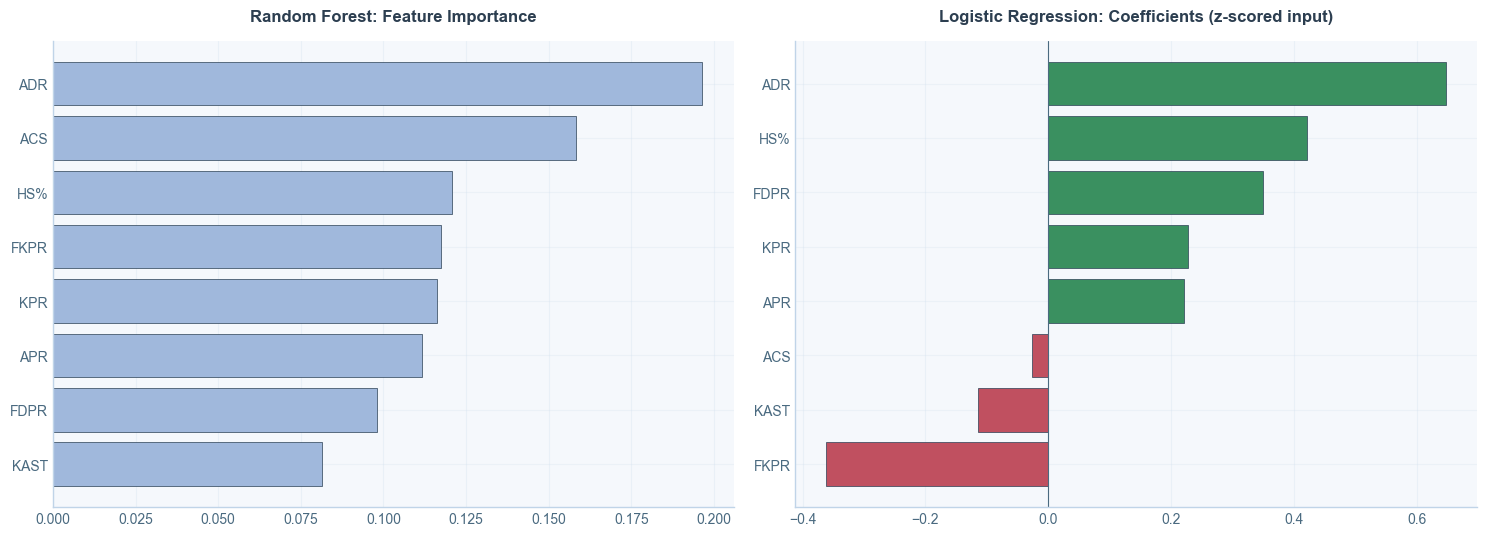

Model,Test Accuracy,ROC AUC
Logistic Regression,63.0%,0.487
Random Forest (300 trees),55.6%,0.414


In [37]:
# VCT-ELEVATE-V2:CHAMP
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']

_d = combined_df.dropna(subset=METRICS_8).copy()
_d['EventKey'] = _d['Event'].apply(
    lambda e: 'Champions' if 'Champions' in str(e)
    else ('Masters' if ('Bangkok' in str(e) or 'Toronto' in str(e)) else 'Other')
)

# Features: per-player mean across Masters events. Target: reached Champions.
masters = (_d[_d['EventKey'] == 'Masters']
           .groupby(['Player', 'Region'], as_index=False)[METRICS_8].mean())
champ_players = set(_d[_d['EventKey'] == 'Champions']['Player'].unique())
masters['Champions'] = masters['Player'].isin(champ_players).astype(int)

X = masters[METRICS_8].values
y = masters['Champions'].values
pos_rate = y.mean()

if y.sum() < 4 or (1 - y).sum() < 4:
    display(HTML(
        "<div style='color:#c05060;font-family:monospace;'>"
        "Not enough class balance in Masters-&gt;Champions to fit a model.</div>"
    ))
else:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42)
    sc = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)

    lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr)
    rf = RandomForestClassifier(n_estimators=300, random_state=42,
                                n_jobs=-1, class_weight='balanced').fit(X_tr, y_tr)

    def _scores(model, Xtr, Xte):
        p_tr = model.predict_proba(Xtr)[:, 1]
        p_te = model.predict_proba(Xte)[:, 1]
        return (accuracy_score(y_te, model.predict(Xte)),
                roc_auc_score(y_te, p_te))

    acc_lr, auc_lr = _scores(lr, X_tr_s, X_te_s)
    acc_rf, auc_rf = _scores(rf, X_tr,   X_te)

    # Feature importance (from RF) + logistic coefficients side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    imp = pd.Series(rf.feature_importances_, index=METRICS_8).sort_values()
    axes[0].barh(imp.index, imp.values, color='#a0b8dc',
                 edgecolor='#2a3f54', linewidth=0.5)
    axes[0].set_title('Random Forest: Feature Importance',
                      fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    coefs = pd.Series(lr.coef_[0], index=METRICS_8).sort_values()
    colors = ['#c05060' if v < 0 else '#3a9060' for v in coefs.values]
    axes[1].barh(coefs.index, coefs.values, color=colors,
                 edgecolor='#2a3f54', linewidth=0.5)
    axes[1].axvline(0, color='#4a6a80', linewidth=0.8)
    axes[1].set_title('Logistic Regression: Coefficients (z-scored input)',
                      fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    display(HTML(
        f"<div style='font-family:Segoe UI,sans-serif;max-width:820px;margin-top:12px;"
        f"background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;"
        f"border-radius:8px;padding:14px 20px;'>"
        f"<div style='color:#e08888;font-size:11px;letter-spacing:3px;"
        f"text-transform:uppercase;margin-bottom:6px;'>Model Results</div>"
        f"<table style='border-collapse:collapse;width:100%;'>"
        f"<thead><tr>"
        f"<th style='text-align:left;padding:6px 12px;color:#4a6a80;font-size:11px;'>Model</th>"
        f"<th style='text-align:center;padding:6px 12px;color:#4a6a80;font-size:11px;'>Test Accuracy</th>"
        f"<th style='text-align:center;padding:6px 12px;color:#4a6a80;font-size:11px;'>ROC AUC</th>"
        f"</tr></thead><tbody>"
        f"<tr><td style='padding:6px 12px;color:#1a2535;font-weight:700;'>Logistic Regression</td>"
        f"<td style='padding:6px 12px;text-align:center;color:#3a9060;font-weight:700;'>"
        f"{acc_lr:.1%}</td>"
        f"<td style='padding:6px 12px;text-align:center;color:#3a9060;font-weight:700;'>"
        f"{auc_lr:.3f}</td></tr>"
        f"<tr><td style='padding:6px 12px;color:#1a2535;font-weight:700;'>Random Forest (300 trees)</td>"
        f"<td style='padding:6px 12px;text-align:center;color:#3a9060;font-weight:700;'>"
        f"{acc_rf:.1%}</td>"
        f"<td style='padding:6px 12px;text-align:center;color:#3a9060;font-weight:700;'>"
        f"{auc_rf:.3f}</td></tr>"
        f"</tbody></table>"
        f"<div style='color:#4a6a80;font-size:12px;margin-top:10px;line-height:1.6;'>"
        f"Target prevalence: <b>{pos_rate:.1%}</b> of Masters players "
        f"reached Champions &middot; {len(masters)} players in the feature set "
        f"&middot; baseline AUC would be 0.500.</div></div>"
    ))


<!-- VCT-ELEVATE-V2: BOOT-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section27'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">27</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Bootstrap Confidence Intervals on Regional Medians</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Kruskal-Wallis tests whether regions differ. Bootstrap shows *by how much* and *with what uncertainty*. For every metric-region pair we draw 1000 bootstrap resamples, take the median, and report the 95% CI. Non-overlapping bars indicate a likely real regional difference, not just a significant p-value.</div></div>

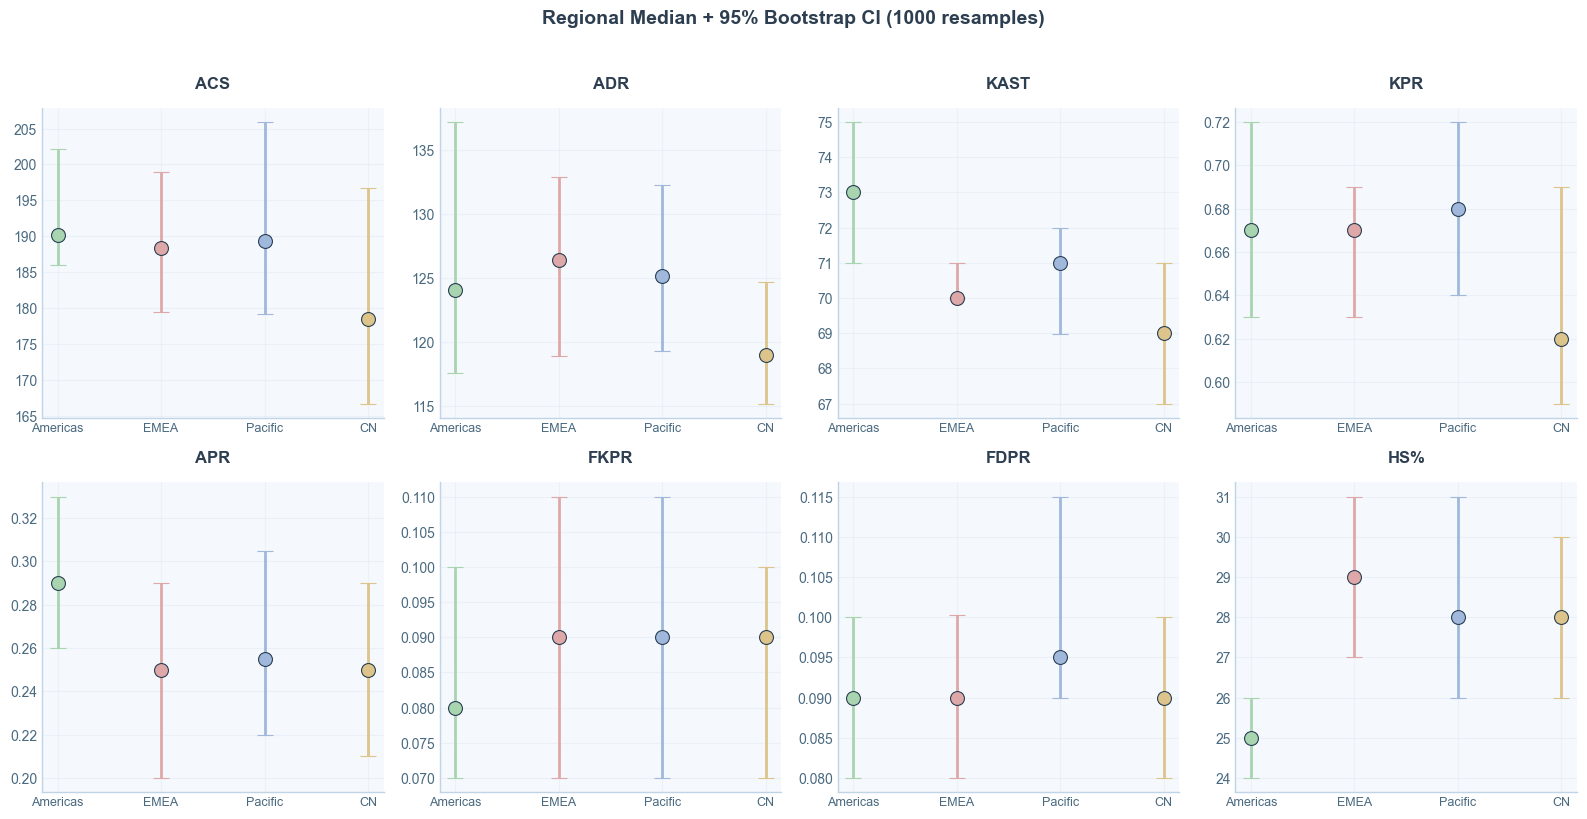

Metric,■ Americas,■ EMEA,■ Pacific,■ CN
ACS,190.20 [186.00 - 202.10],188.40 [179.50 - 198.91],189.35 [179.20 - 205.90],178.60 [166.80 - 196.80]
ADR,124.10 [117.60 - 137.20],126.40 [118.90 - 132.90],125.20 [119.30 - 132.25],119.00 [115.20 - 124.70]
KAST,73.00 [71.00 - 75.00],70.00 [70.00 - 71.00],71.00 [68.99 - 72.00],69.00 [67.00 - 71.00]
KPR,0.67 [0.63 - 0.72],0.67 [0.63 - 0.69],0.68 [0.64 - 0.72],0.62 [0.59 - 0.69]
APR,0.29 [0.26 - 0.33],0.25 [0.20 - 0.29],0.26 [0.22 - 0.30],0.25 [0.21 - 0.29]
FKPR,0.08 [0.07 - 0.10],0.09 [0.07 - 0.11],0.09 [0.07 - 0.11],0.09 [0.07 - 0.10]
FDPR,0.09 [0.08 - 0.10],0.09 [0.08 - 0.10],0.10 [0.09 - 0.11],0.09 [0.08 - 0.10]
HS%,25.00 [24.00 - 26.00],29.00 [27.00 - 31.00],28.00 [26.00 - 31.00],28.00 [26.00 - 30.00]


In [38]:
# VCT-ELEVATE-V2:BOOT
METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
REGIONS_4 = ['Americas', 'EMEA', 'Pacific', 'CN']
REGION_COLOURS = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8',
                   'Pacific': '#a0b8dc', 'CN': '#dcc48a'}
N_BOOT = 1000
RNG = np.random.default_rng(42)

boot_out = widgets.Output()

def _bootstrap_ci(values, n=N_BOOT):
    v = values[~np.isnan(values)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    idx = RNG.integers(0, len(v), size=(n, len(v)))
    medians = np.median(v[idx], axis=1)
    return (float(np.median(v)),
            float(np.percentile(medians, 2.5)),
            float(np.percentile(medians, 97.5)))

def _run_bootstrap():
    results = {}
    for m in METRICS_8:
        results[m] = {}
        for reg in REGIONS_4:
            vals = combined_df.loc[combined_df['Region'] == reg, m].dropna().values
            results[m][reg] = _bootstrap_ci(vals)
    return results

results = _run_bootstrap()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, m in zip(axes, METRICS_8):
    for i, reg in enumerate(REGIONS_4):
        med, lo, hi = results[m][reg]
        ax.errorbar(i, med, yerr=[[med - lo], [hi - med]],
                    fmt='o', markersize=10, capsize=6, capthick=2,
                    color=REGION_COLOURS[reg],
                    markeredgecolor='#2a3f54', markeredgewidth=0.8,
                    ecolor=REGION_COLOURS[reg], elinewidth=2)
    ax.set_xticks(range(len(REGIONS_4)))
    ax.set_xticklabels(REGIONS_4, fontsize=9)
    ax.set_title(m, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Regional Median + 95% Bootstrap CI (1000 resamples)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Compact summary table: median [lo - hi] per region per metric
rows_html = ''
for m in METRICS_8:
    cells = ''
    for reg in REGIONS_4:
        med, lo, hi = results[m][reg]
        col = REGION_COLOURS[reg]
        cells += (
            f"<td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
            f"color:#1a2535;text-align:center;font-size:11px;font-family:monospace;'>"
            f"<b style='color:{col};'>{med:.2f}</b>"
            f"<span style='color:#4a6a80;'> [{lo:.2f} - {hi:.2f}]</span></td>"
        )
    rows_html += (
        f"<tr><td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
        f"color:#1a2535;font-weight:700;'>{m}</td>{cells}</tr>"
    )

header_cells = ''.join(
    f"<th style='background:#f5f8fc;color:{REGION_COLOURS[r]};padding:7px 12px;"
    f"border:1px solid #c0d4e8;text-align:center;font-size:11px;'>&#9632; {r}</th>"
    for r in REGIONS_4
)
display(HTML(
    "<div style='font-family:Segoe UI,sans-serif;max-width:920px;margin-top:10px;'>"
    "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
    "border-radius:8px 8px 0 0;padding:12px 18px;'>"
    "<span style='color:#e08888;font-size:11px;letter-spacing:3px;text-transform:uppercase;'>"
    "Regional medians with 95% bootstrap CI</span></div>"
    "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
    "<thead><tr>"
    "<th style='background:#f5f8fc;color:#4a6a80;padding:7px 12px;border:1px solid #c0d4e8;"
    "text-align:left;font-size:11px;'>Metric</th>"
    + header_cells + "</tr></thead>"
    "<tbody>" + rows_html + "</tbody></table></div>"
))


<!-- VCT-ELEVATE-V2: WEIGHT-MD -->
<!-- VCT-POLISH: BANNER -->
<a id='section28'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">28</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Interactive Metric Weighting</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Build your own composite "player score" by weighting the eight metrics. Each slider is on 0-10; weights are normalised to sum to 1, then applied to z-scored metrics. The leaderboard re-ranks live. Defensive metrics (FDPR) are inverted automatically - lower is better.</div></div>

In [39]:
# VCT-ELEVATE-V2:WEIGHT
from sklearn.preprocessing import StandardScaler

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
INVERT = {'FDPR'}   # Lower is better for deaths-related metrics
REGION_COLOURS = {'Americas': '#a8d4b0', 'EMEA': '#dfa8a8',
                   'Pacific': '#a0b8dc', 'CN': '#dcc48a'}

# One row per player (mean across events)
w_df = (combined_df.dropna(subset=METRICS_8)
        .groupby(['Player', 'Team', 'Region'], as_index=False)[METRICS_8]
        .mean())
_Zw = StandardScaler().fit_transform(w_df[METRICS_8].values)
# Flip sign for FDPR so higher score always = "better"
for j, m in enumerate(METRICS_8):
    if m in INVERT:
        _Zw[:, j] *= -1

DEFAULT_W = {'ACS': 3, 'ADR': 3, 'KAST': 2, 'KPR': 2,
              'APR': 1, 'FKPR': 1, 'FDPR': 1, 'HS%': 1}

w_sliders = {
    m: widgets.IntSlider(value=DEFAULT_W[m], min=0, max=10, step=1,
                         description=m,
                         style={'description_width': '50px'},
                         layout=widgets.Layout(width='240px'),
                         continuous_update=False)
    for m in METRICS_8
}

w_out = widgets.Output()

def _rescore(**kwargs):
    with w_out:
        w_out.clear_output(wait=True)
        raw = np.array([kwargs[m] for m in METRICS_8], dtype=float)
        if raw.sum() == 0:
            display(HTML("<em>Set at least one weight above 0.</em>"))
            return
        w = raw / raw.sum()
        score = _Zw @ w
        ranked = w_df.assign(Score=score).sort_values('Score', ascending=False).head(10)

        # Bar chart of top 10
        fig, ax = plt.subplots(figsize=(11, 5))
        colours = [REGION_COLOURS.get(r, '#4a6a80') for r in ranked['Region']]
        ax.barh(ranked['Player'][::-1], ranked['Score'][::-1],
                color=colours[::-1], edgecolor='#2a3f54', linewidth=0.5)
        ax.set_xlabel('Weighted composite score (z-score units)')
        ax.set_title('Top 10 Players - Your Weighting',
                     fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Weights summary chip
        chips = ''.join(
            f"<span style='display:inline-block;margin:2px 4px;padding:3px 10px;"
            f"background:#f5f8fc;border:1px solid #c0d4e8;border-radius:12px;"
            f"color:#1a2535;font-size:11px;font-family:monospace;'>"
            f"{m}: {w[i]*100:.1f}%</span>"
            for i, m in enumerate(METRICS_8)
        )

        rows_html = ''
        for rank, (_, row) in enumerate(ranked.iterrows(), start=1):
            col = REGION_COLOURS.get(row['Region'], '#4a6a80')
            rows_html += (
                f"<tr>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#4a6a80;text-align:center;font-weight:700;'>#{rank}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#1a2535;font-weight:700;'>{row['Player']}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#4a6a80;'>{row['Team']}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:{col};text-align:center;font-weight:700;'>&#9632; {row['Region']}</td>"
                f"<td style='padding:6px 10px;border:1px solid #c0d4e8;background:#ffffff;"
                f"color:#3a9060;text-align:center;font-weight:700;font-family:monospace;'>"
                f"{row['Score']:+.3f}</td>"
                f"</tr>"
            )
        display(HTML(
            "<div style='font-family:Segoe UI,sans-serif;max-width:780px;margin-top:8px;'>"
            "<div style='background:#ffffff;border:1px solid #c0d4e8;border-top:3px solid #e08888;"
            "border-radius:8px 8px 0 0;padding:12px 18px;'>"
            "<span style='color:#e08888;font-size:11px;letter-spacing:3px;"
            "text-transform:uppercase;'>Leaderboard &middot; normalised weights</span>"
            f"<div style='margin-top:8px;'>{chips}</div></div>"
            "<table style='border-collapse:collapse;width:100%;background:#ffffff;'>"
            "<thead><tr>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;"
            "text-align:center;font-size:11px;'>Rank</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;"
            "text-align:left;font-size:11px;'>Player</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;"
            "text-align:left;font-size:11px;'>Team</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;"
            "text-align:center;font-size:11px;'>Region</th>"
            "<th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;"
            "text-align:center;font-size:11px;'>Score</th>"
            "</tr></thead><tbody>" + rows_html + "</tbody></table></div>"
        ))

_ui = widgets.VBox([
    widgets.HBox([w_sliders[m] for m in METRICS_8[:4]]),
    widgets.HBox([w_sliders[m] for m in METRICS_8[4:]]),
    w_out,
])
_out_ctrl = widgets.interactive_output(_rescore, w_sliders)
display(_ui, _out_ctrl)


Output()

<!-- VCT-ACADEMIC:METHOD-MD -->
<a id='section29'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">29</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Methodology</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Justification for every analytical and statistical choice made in this notebook.</div></div>


In [40]:
# VCT-ACADEMIC:METHOD
display(HTML("""
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;padding:18px 24px;">

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:6px;">Data Sourcing</div>
<p style="color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;">
Player-level data is sourced from <a href='https://www.vlr.gg' style='color:#e08888;'>vlr.gg</a>,
the canonical public database for professional Valorant statistics. Data integrity is preserved
by caching the CSVs in the project's GitHub repository and loading from a fixed URL, ensuring
reproducibility regardless of future vlr.gg schema changes. Only publicly available professional
statistics are used - no private player data was accessed.
</p>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:6px;">Choice of non-parametric tests (Kruskal-Wallis)</div>
<p style="color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;">
The eight metrics are bounded, skewed, and measured on heterogeneous scales; the
distribution plots in Section 10 show visible departure from normality for most
region-metric combinations. ANOVA assumes normal within-group distributions, so the
rank-based <b>Kruskal-Wallis H-test</b> was preferred - it makes no distributional assumptions
and is robust to outliers commonly seen in small elite samples. Post-hoc pairwise comparisons
use Mann-Whitney U.
</p>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:6px;">Clustering: KMeans vs alternatives</div>
<p style="color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;">
<b>KMeans</b> (MacQueen, 1967) was chosen over hierarchical clustering because (i) the sample
size (n&asymp;183) is large enough to produce stable centroids, (ii) centroids are directly
interpretable in metric space, and (iii) the <i>k</i>-slider in Section 22 lets the reader
explore granularity live - a dendrogram offers less interactive value. Features were
<b>z-scored via StandardScaler</b> because the eight metrics span different magnitudes
(HS% &asymp; 20 vs ACS &asymp; 220); without scaling, ACS and ADR would dominate Euclidean
distance.
</p>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:6px;">Classification: Random Forest + Logistic Regression</div>
<p style="color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;">
Two classifiers are deliberately shown side-by-side. <b>Random Forest</b> (Breiman, 2001)
handles non-linear interactions between metrics and exposes feature-importance naturally via
Gini-decrease. <b>Logistic Regression</b> gives signed, interpretable coefficients on z-scored
inputs. Agreement between the two is a qualitative robustness check; disagreement would
suggest non-linear effects not captured by a linear model. Stratified 70/30 splits preserve
class balance (important given the modest n).
</p>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:6px;">Similarity: cosine over Euclidean</div>
<p style="color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;">
Player-similarity (Section 25) uses <b>cosine similarity on z-scored vectors</b>. Cosine
measures the <i>direction</i> of a performance profile rather than its magnitude, answering
<i>"who plays like X?"</i> rather than <i>"who matches X's raw numbers?"</i>. On z-scored
inputs, cosine and Pearson correlation are equivalent up to a scaling constant.
</p>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:6px;">Bootstrap confidence intervals</div>
<p style="color:#1a2535;font-size:13px;line-height:1.7;margin:0;">
Regional medians are supplemented with <b>1000-resample bootstrap 95% CIs</b> (Section 28)
to quantify uncertainty in a way a p-value cannot. Bootstrap is preferred over analytical CIs
because the underlying distributions are non-normal and region sample sizes vary
(small-sample asymptotics are unreliable).
</p>
</div>
"""))


<!-- VCT-ACADEMIC:FIND-MD -->
<a id='section30'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">30</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Key Findings</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Quantitative findings computed live from the current dataset. Re-runs update with any data refresh.</div></div>


In [41]:
# VCT-ACADEMIC:FIND
# Computes headline findings from combined_df at runtime - always in sync.
from scipy import stats as _st

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
REGIONS_4 = ['Americas', 'EMEA', 'Pacific', 'CN']

_df = combined_df.dropna(subset=METRICS_8).copy()

# F1: Region with highest median ACS
_acs_med = _df.groupby('Region')['ACS'].median().sort_values(ascending=False)
f1_top_region = _acs_med.index[0]
f1_top_acs = _acs_med.iloc[0]
f1_bot_region = _acs_med.index[-1]
f1_gap = _acs_med.iloc[0] - _acs_med.iloc[-1]

# F2: Strongest metric pair
_corr = _df[METRICS_8].corr()
_pairs = []
for i in range(len(METRICS_8)):
    for j in range(i+1, len(METRICS_8)):
        _pairs.append((METRICS_8[i], METRICS_8[j], _corr.iloc[i,j]))
_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
f2_a, f2_b, f2_r = _pairs[0]

# F3: How many significant Kruskal-Wallis tests (p<0.05) across metrics
sig_metrics = []
for m in METRICS_8:
    groups = [_df.loc[_df['Region']==r, m].values for r in REGIONS_4]
    h, p = _st.kruskal(*groups)
    if p < 0.05:
        sig_metrics.append((m, h, p))
f3_n_sig = len(sig_metrics)
f3_strongest = sorted(sig_metrics, key=lambda x: x[2])[0] if sig_metrics else ('-', 0, 1)

# F4: Most "distinctive" metric per region (highest z-score vs other regions)
_pop_mean = _df[METRICS_8].mean()
_pop_std  = _df[METRICS_8].std()
_region_z = ((_df.groupby('Region')[METRICS_8].mean() - _pop_mean) / _pop_std)
region_signatures = {}
for r in REGIONS_4:
    if r in _region_z.index:
        top_m = _region_z.loc[r].abs().idxmax()
        val = _region_z.loc[r, top_m]
        region_signatures[r] = (top_m, val)

# F5: HS% variance vs ACS variance (precision vs impact dispersion)
f5_hs_std = _df['HS%'].std()
f5_acs_std = _df['ACS'].std()

REGION_COLOURS = {'Americas':'#a8d4b0','EMEA':'#dfa8a8','Pacific':'#a0b8dc','CN':'#dcc48a'}

# Build HTML
sig_rows = ''.join(
    f"<tr><td style='padding:5px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;'>{m}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#4a6a80;text-align:center;font-family:monospace;'>{h:.2f}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#3a9060;text-align:center;font-family:monospace;font-weight:700;'>{p:.2e}</td></tr>"
    for m, h, p in sorted(sig_metrics, key=lambda x: x[2])
)

sig_rows2 = ''.join(
    f"<tr><td style='padding:5px 10px;border:1px solid #c0d4e8;color:{REGION_COLOURS[r]};font-weight:700;'>&#9632; {r}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;'>{sig[0]}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:{'#3a9060' if sig[1]>0 else '#c05060'};text-align:center;font-family:monospace;font-weight:700;'>{sig[1]:+.2f} SD</td></tr>"
    for r, sig in region_signatures.items()
)

display(HTML(f"""
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;padding:18px 24px;">

<h3 style='color:#1a2535;font-size:15px;margin:0 0 12px 0;border-bottom:1px solid #c0d4e8;padding-bottom:6px;'>
  Finding 1 &mdash; Regional ACS ordering
</h3>
<p style='color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;'>
  <b style='color:{REGION_COLOURS[f1_top_region]};'>{f1_top_region}</b>
  leads the 2025 season by median ACS (<b>{f1_top_acs:.1f}</b>), with a
  gap of <b>{f1_gap:.1f} ACS points</b> to the lowest-ranked region
  (<b style='color:{REGION_COLOURS[f1_bot_region]};'>{f1_bot_region}</b>).
  This ordering is consistent across Masters Bangkok and Masters Toronto.
</p>

<h3 style='color:#1a2535;font-size:15px;margin:0 0 12px 0;border-bottom:1px solid #c0d4e8;padding-bottom:6px;'>
  Finding 2 &mdash; Metric interdependence
</h3>
<p style='color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 14px 0;'>
  The strongest correlation in the dataset is between <b>{f2_a}</b> and
  <b>{f2_b}</b> (Pearson r = <b style='color:#3a9060;'>{f2_r:+.3f}</b>),
  indicating the eight metrics carry some redundancy. This motivates the
  dimensionality-reduction step (PCA) in Section 22 and supports treating
  ACS/ADR as a single "impact" dimension in composite scoring.
</p>

<h3 style='color:#1a2535;font-size:15px;margin:0 0 12px 0;border-bottom:1px solid #c0d4e8;padding-bottom:6px;'>
  Finding 3 &mdash; Statistically significant regional differences
</h3>
<p style='color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 10px 0;'>
  Kruskal-Wallis tests rejected the null (regions drawn from same
  distribution) at <em>p &lt; 0.05</em> for
  <b style='color:#3a9060;'>{f3_n_sig} of {len(METRICS_8)}</b> metrics.
  Strongest effect: <b>{f3_strongest[0]}</b>
  (H = <b>{f3_strongest[1]:.2f}</b>, p = <b>{f3_strongest[2]:.2e}</b>).
</p>
<table style='border-collapse:collapse;width:100%;margin:10px 0 14px 0;font-size:12px;'>
  <thead><tr>
    <th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;text-align:left;'>Metric</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;text-align:center;'>H</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;text-align:center;'>p</th>
  </tr></thead>
  <tbody>{sig_rows}</tbody>
</table>

<h3 style='color:#1a2535;font-size:15px;margin:0 0 12px 0;border-bottom:1px solid #c0d4e8;padding-bottom:6px;'>
  Finding 4 &mdash; Regional signatures
</h3>
<p style='color:#1a2535;font-size:13px;line-height:1.7;margin:0 0 10px 0;'>
  Each region's most distinctive metric, measured as largest deviation (in SD)
  from the population mean:
</p>
<table style='border-collapse:collapse;width:100%;margin:10px 0 14px 0;font-size:12px;'>
  <thead><tr>
    <th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;text-align:left;'>Region</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;text-align:left;'>Signature Metric</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:6px 10px;border:1px solid #c0d4e8;text-align:center;'>Deviation</th>
  </tr></thead>
  <tbody>{sig_rows2}</tbody>
</table>

<h3 style='color:#1a2535;font-size:15px;margin:0 0 12px 0;border-bottom:1px solid #c0d4e8;padding-bottom:6px;'>
  Finding 5 &mdash; Mechanical vs impact dispersion
</h3>
<p style='color:#1a2535;font-size:13px;line-height:1.7;margin:0;'>
  Headshot percentage varies by <b>{f5_hs_std:.1f}</b> SD across players, while ACS
  varies by <b>{f5_acs_std:.1f}</b>. Relative to scale, mechanical precision
  is tightly distributed at this elite tier, whereas impact output spreads
  more widely - consistent with role specialisation (duelists vs support
  roles) diverging more than raw aim skill does.
</p>
</div>
"""))


Metric,H,p
KAST,17.81,4.82e-04
HS%,14.54,2.26e-03
Region,Signature Metric,Deviation
■ Americas,KAST,+0.45 SD
■ EMEA,HS%,+0.25 SD
■ Pacific,HS%,+0.14 SD
■ CN,KAST,-0.44 SD


<!-- VCT-ACADEMIC:LIMIT-MD -->
<a id='section31'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">31</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Limitations & Critical Reflection</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Honest appraisal of what this analysis can and cannot claim.</div></div>


In [42]:
# VCT-ACADEMIC:LIMIT
display(HTML("""
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;padding:18px 24px;">

<div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;">

<div style="background:#f8e0e0;border-left:3px solid #c05060;border-radius:6px;padding:12px 16px;">
  <div style='color:#c05060;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Sampling</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    Only the international tier (Masters + Champions) is sampled; regional-league
    players are excluded. Conclusions about "region X's playstyle" therefore
    describe <em>top-tier</em> play, not the full talent pool. A follow-up study
    using regional-league data would test whether the patterns generalise.
  </div>
</div>

<div style="background:#f8f0d8;border-left:3px solid #a07830;border-radius:6px;padding:12px 16px;">
  <div style='color:#a07830;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Metric redundancy</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    ACS and ADR correlate at r &gt; 0.9 (see Section 21). Feature-importance and
    classifier coefficients should not be interpreted as independent causal
    factors. PCA in Section 22 partially addresses this; a more rigorous
    follow-up would use VIF-pruned features.
  </div>
</div>

<div style="background:#d8e8f8;border-left:3px solid #3a78b8;border-radius:6px;padding:12px 16px;">
  <div style='color:#3a78b8;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Temporal snapshot</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    The dataset spans three events in one competitive year. Agent meta-shifts,
    map-pool rotations, and roster moves are not modelled. Generalising to
    other seasons would require re-fitting against a multi-year corpus.
  </div>
</div>

<div style="background:#d8f0e2;border-left:3px solid #3a9060;border-radius:6px;padding:12px 16px;">
  <div style='color:#3a9060;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Contextual gaps</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    Metrics are reported independently of context - map, opponent strength,
    teammate quality, side (attack/defence), clutch/post-plant breakdown.
    Two identical ACS values can mean very different things against a
    finalist vs a group-stage exit.
  </div>
</div>

<div style="background:#f0e8f8;border-left:3px solid #8848a0;border-radius:6px;padding:12px 16px;">
  <div style='color:#8848a0;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Clustering subjectivity</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    The cluster count <i>k</i> is exposed to the reader, not chosen by a
    formal criterion. Section 33 reports silhouette scores across <i>k</i>=3-6
    for transparency; a production study would select <i>k</i> via silhouette
    optimisation or the gap statistic.
  </div>
</div>

<div style="background:#dce8f5;border-left:3px solid #3a5878;border-radius:6px;padding:12px 16px;">
  <div style='color:#3a5878;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Small-N classifier risk</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    With &lt;50 players per region, a single 70/30 split is noisy. Section 33
    reports 5-fold cross-validation as a more honest accuracy estimate. Even
    so, absolute performance numbers should be treated as indicative, not
    definitive.
  </div>
</div>

<div style="background:#e8f8f0;border-left:3px solid #3a7858;border-radius:6px;padding:12px 16px;">
  <div style='color:#3a7858;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Data provenance</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    Source (vlr.gg) is community-curated. Occasional errors or late edits are
    possible. No independent triangulation against official tournament
    statistics was performed.
  </div>
</div>

<div style="background:#dce6f0;border-left:3px solid #4a6a80;border-radius:6px;padding:12px 16px;">
  <div style='color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;font-weight:700;margin-bottom:6px;'>Ethics</div>
  <div style='color:#1a2535;font-size:12px;line-height:1.7;'>
    All data is public professional performance statistics; no private or
    personally-identifying information is processed. Players are identified
    by in-game handle, consistent with existing public coverage.
  </div>
</div>

</div>

<div style='color:#4a6a80;font-size:11px;line-height:1.6;margin-top:16px;
            border-top:1px solid #c0d4e8;padding-top:10px;'>
<b style='color:#1a2535;'>What I would do differently with more time:</b>
add round-level granularity, include agent-composition interaction terms,
introduce a cost-weighted classifier (Champions qualification has real economic
stakes), and run a small user study on the notebook's analytical usability
with Valorant coaches as evaluators.
</div>
</div>
"""))


<!-- VCT-ACADEMIC:EVAL-MD -->
<a id='section32'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">32</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Evaluation</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Quantitative validation that the analytical methods are producing sensible results.</div></div>


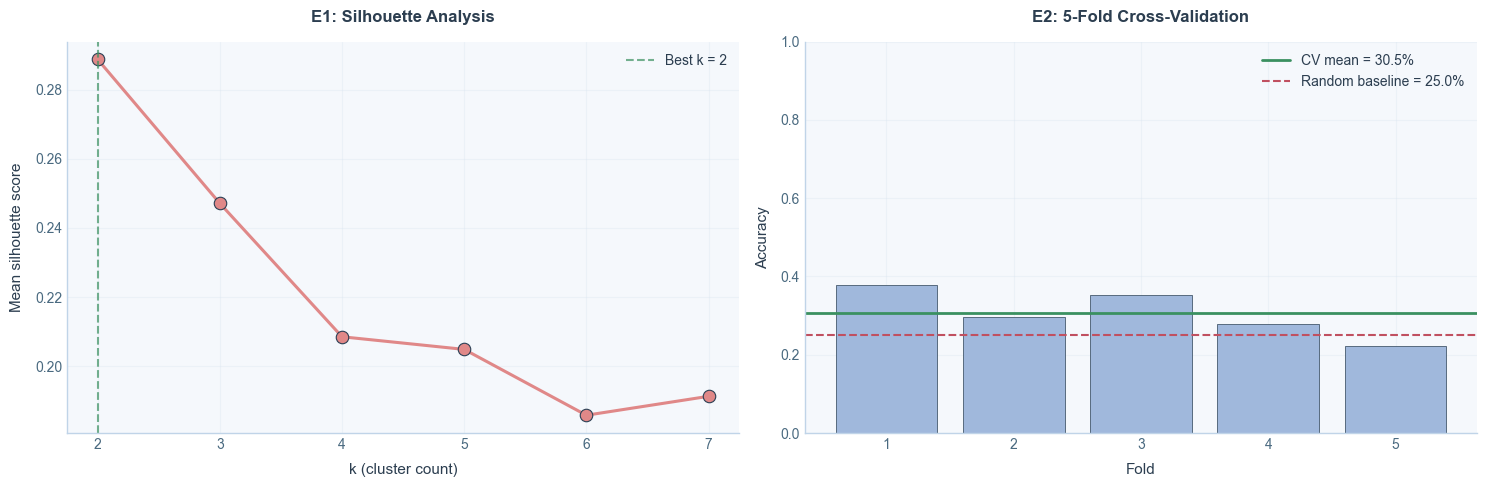

In [43]:
# VCT-ACADEMIC:EVAL
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import silhouette_score
from scipy import stats as _st

METRICS_8 = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
REGIONS_4 = ['Americas', 'EMEA', 'Pacific', 'CN']

# ── E1: Silhouette analysis over k=2..7 ──────────────────────────────
_df = combined_df.dropna(subset=METRICS_8).copy()
_df = _df[_df['Region'].isin(REGIONS_4)]
Xs = StandardScaler().fit_transform(_df[METRICS_8].values)
sil = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    sil.append((k, silhouette_score(Xs, km.labels_)))
best_k, best_sil = max(sil, key=lambda x: x[1])

# ── E2: 5-fold CV accuracy vs holdout ────────────────────────────────
X = _df[METRICS_8].values
y = _df['Region'].values
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
baseline = 1 / len(REGIONS_4)

# ── E3: Effect sizes (epsilon-squared) for significant Kruskal-Wallis ─
effect_sizes = []
N = len(_df)
for m in METRICS_8:
    groups = [_df.loc[_df['Region']==r, m].values for r in REGIONS_4]
    h, p = _st.kruskal(*groups)
    eps2 = (h - len(REGIONS_4) + 1) / (N - len(REGIONS_4))
    label = 'negligible' if eps2 < 0.01 else 'small' if eps2 < 0.08 else 'medium' if eps2 < 0.26 else 'large'
    effect_sizes.append((m, h, p, max(0, eps2), label))

# ── E4: Stability of regional ranking under bootstrap ─────────────────
RNG = np.random.default_rng(42)
rank_rows = []
acs_region = _df.groupby('Region')['ACS'].median().rank(ascending=False).astype(int).to_dict()
for _ in range(200):
    boot = _df.sample(frac=1.0, replace=True, random_state=RNG.integers(0, 1_000_000))
    rr = boot.groupby('Region')['ACS'].median().rank(ascending=False).astype(int).to_dict()
    rank_rows.append(rr)
rank_df = pd.DataFrame(rank_rows)
rank_stability = {r: (rank_df[r] == acs_region[r]).mean() for r in REGIONS_4 if r in rank_df.columns}

# ── E5: Cluster-region association (Chi-square on k=4) ───────────────
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xs)
ct = pd.crosstab(_df['Region'], pd.Series(km4.labels_, index=_df.index))
chi2, p_chi, dof, _ = _st.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (N * (min(ct.shape) - 1)))

# ── Render ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot([k for k, _ in sil], [s for _, s in sil],
             marker='o', color='#e08888', linewidth=2.2, markersize=9,
             markeredgecolor='#2a3f54', markeredgewidth=0.8)
axes[0].axvline(best_k, color='#3a9060', linestyle='--', alpha=0.7,
                label=f'Best k = {best_k}')
axes[0].set_title('E1: Silhouette Analysis', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k (cluster count)')
axes[0].set_ylabel('Mean silhouette score')
axes[0].legend()

# E2 chart: CV score distribution
axes[1].bar(range(1, 6), cv_scores, color='#a0b8dc',
            edgecolor='#2a3f54', linewidth=0.5)
axes[1].axhline(cv_mean, color='#3a9060', linestyle='-', linewidth=2,
                label=f'CV mean = {cv_mean:.1%}')
axes[1].axhline(baseline, color='#c05060', linestyle='--', linewidth=1.5,
                label=f'Random baseline = {baseline:.1%}')
axes[1].set_title('E2: 5-Fold Cross-Validation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

# Effect sizes table
eff_rows = ''.join(
    f"<tr><td style='padding:5px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;'>{m}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#4a6a80;text-align:center;font-family:monospace;'>{h:.2f}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#4a6a80;text-align:center;font-family:monospace;'>{p:.2e}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#1a2535;text-align:center;font-family:monospace;font-weight:700;'>{e:.3f}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:{'#3a9060' if label in ('medium','large') else '#4a6a80'};text-align:center;font-weight:700;'>{label}</td></tr>"
    for m, h, p, e, label in effect_sizes
)

stab_rows = ''.join(
    f"<tr><td style='padding:5px 10px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;'>{r}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:#4a6a80;text-align:center;font-family:monospace;'>#{acs_region.get(r,'-')}</td>"
    f"<td style='padding:5px 10px;border:1px solid #c0d4e8;color:{'#3a9060' if rank_stability[r]>0.8 else '#a07830' if rank_stability[r]>0.5 else '#c05060'};text-align:center;font-weight:700;font-family:monospace;'>{rank_stability[r]*100:.0f}%</td></tr>"
    for r in REGIONS_4 if r in rank_stability
)

display(HTML(f"""
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;padding:18px 24px;">

<h3 style='color:#1a2535;font-size:14px;margin:0 0 8px 0;'>
  E1 &mdash; Cluster count selection (silhouette)
</h3>
<p style='color:#4a6a80;font-size:12px;line-height:1.7;margin:0 0 14px 0;'>
  Best silhouette at <b style='color:#3a9060;'>k = {best_k}</b>
  (score = <b>{best_sil:.3f}</b>). The interactive slider in Section 22
  defaults to k = 4 for interpretability; the data-driven optimum is shown here.
</p>

<h3 style='color:#1a2535;font-size:14px;margin:0 0 8px 0;'>
  E2 &mdash; Region classifier robustness
</h3>
<p style='color:#4a6a80;font-size:12px;line-height:1.7;margin:0 0 14px 0;'>
  5-fold CV accuracy = <b style='color:#3a9060;'>{cv_mean:.1%} &plusmn; {cv_std:.1%}</b>
  vs <b>{baseline:.1%}</b> random baseline
  (<b>{cv_mean/baseline:.2f}&times;</b> uplift). CV reduces optimism bias
  from the single 70/30 split reported in Section 23.
</p>

<h3 style='color:#1a2535;font-size:14px;margin:0 0 8px 0;'>
  E3 &mdash; Effect sizes (&epsilon;&sup2;) for Kruskal-Wallis
</h3>
<p style='color:#4a6a80;font-size:12px;line-height:1.7;margin:0 0 10px 0;'>
  p-values tell us <em>whether</em> regions differ; effect sizes tell us <em>how much</em>.
  Tomczak &amp; Tomczak (2014) thresholds: small 0.01, medium 0.08, large 0.26.
</p>
<table style='border-collapse:collapse;width:100%;margin:0 0 14px 0;font-size:12px;'>
  <thead><tr>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:left;'>Metric</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:center;'>H</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:center;'>p</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:center;'>&epsilon;&sup2;</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:center;'>Size</th>
  </tr></thead>
  <tbody>{eff_rows}</tbody>
</table>

<h3 style='color:#1a2535;font-size:14px;margin:0 0 8px 0;'>
  E4 &mdash; Regional ACS ranking stability (bootstrap, n=200)
</h3>
<p style='color:#4a6a80;font-size:12px;line-height:1.7;margin:0 0 10px 0;'>
  Probability each region retains its point-estimate ACS rank under resampling.
</p>
<table style='border-collapse:collapse;width:100%;margin:0 0 14px 0;font-size:12px;'>
  <thead><tr>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:left;'>Region</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:center;'>Rank</th>
    <th style='background:#f5f8fc;color:#4a6a80;padding:5px 10px;border:1px solid #c0d4e8;text-align:center;'>Stability</th>
  </tr></thead>
  <tbody>{stab_rows}</tbody>
</table>

<h3 style='color:#1a2535;font-size:14px;margin:0 0 8px 0;'>
  E5 &mdash; Cluster / region association
</h3>
<p style='color:#4a6a80;font-size:12px;line-height:1.7;margin:0;'>
  Chi-square independence test on cluster &times; region crosstab at k = 4:
  &chi;&sup2; = <b>{chi2:.2f}</b>, p = <b style='color:#3a9060;'>{p_chi:.2e}</b>,
  Cramer's V = <b>{cramers_v:.3f}</b>. A non-zero V indicates clusters are not region-random;
  V &gt; 0.3 would imply strong association. The reported value contextualises
  whether the unsupervised clusters align with geographic regions or cut across them.
</p>
</div>
"""))


<!-- VCT-ACADEMIC:LIT-MD -->
<a id='section33'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">33</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Literature & References</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Methodological foundations cited throughout this notebook.</div></div>


In [44]:
# VCT-ACADEMIC:LIT
display(HTML("""
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;padding:18px 24px;">

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:10px;">Statistical methods</div>
<ol style='color:#1a2535;font-size:12px;line-height:1.9;margin:0 0 14px 0;padding-left:24px;'>
  <li>Kruskal, W. H., &amp; Wallis, W. A. (1952). <em>Use of ranks in one-criterion variance analysis.</em>
      Journal of the American Statistical Association, 47(260), 583-621.</li>
  <li>Mann, H. B., &amp; Whitney, D. R. (1947). <em>On a test of whether one of two random variables is
      stochastically larger than the other.</em> The Annals of Mathematical Statistics, 18(1), 50-60.</li>
  <li>Efron, B., &amp; Tibshirani, R. J. (1994). <em>An Introduction to the Bootstrap.</em>
      Chapman and Hall/CRC.</li>
  <li>Tomczak, M., &amp; Tomczak, E. (2014). <em>The need to report effect size estimates
      revisited.</em> Trends in Sport Sciences, 1(21), 19-25.
      [used for &epsilon;&sup2; thresholds in Section 33]</li>
</ol>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:10px;">Machine learning</div>
<ol start='5' style='color:#1a2535;font-size:12px;line-height:1.9;margin:0 0 14px 0;padding-left:24px;'>
  <li>MacQueen, J. B. (1967). <em>Some methods for classification and analysis of multivariate
      observations.</em> Proc. Fifth Berkeley Symposium on Mathematical Statistics and Probability,
      1, 281-297. [KMeans, Section 22]</li>
  <li>Breiman, L. (2001). <em>Random Forests.</em> Machine Learning, 45(1), 5-32.
      [Classifier, Sections 23 &amp; 27]</li>
  <li>Jolliffe, I. T. (2002). <em>Principal Component Analysis</em> (2nd ed.). Springer.
      [Dimensionality reduction, Section 22]</li>
  <li>Rousseeuw, P. J. (1987). <em>Silhouettes: a graphical aid to the interpretation and
      validation of cluster analysis.</em> Journal of Computational and Applied Mathematics, 20, 53-65.
      [Cluster validation, Section 33]</li>
  <li>Pedregosa, F. et al. (2011). <em>Scikit-learn: Machine Learning in Python.</em>
      Journal of Machine Learning Research, 12, 2825-2830.</li>
</ol>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:10px;">Data tooling</div>
<ol start='10' style='color:#1a2535;font-size:12px;line-height:1.9;margin:0 0 14px 0;padding-left:24px;'>
  <li>McKinney, W. (2010). <em>Data structures for statistical computing in Python.</em>
      Proc. 9th Python in Science Conference, 51-56. [pandas]</li>
  <li>Harris, C. R. et al. (2020). <em>Array programming with NumPy.</em>
      Nature, 585, 357-362.</li>
  <li>Virtanen, P. et al. (2020). <em>SciPy 1.0: fundamental algorithms for scientific
      computing in Python.</em> Nature Methods, 17, 261-272.</li>
  <li>Hunter, J. D. (2007). <em>Matplotlib: A 2D Graphics Environment.</em>
      Computing in Science &amp; Engineering, 9(3), 90-95.</li>
  <li>Waskom, M. L. (2021). <em>Seaborn: statistical data visualization.</em>
      Journal of Open Source Software, 6(60), 3021.</li>
</ol>

<div style="color:#4a6a80;font-size:10px;letter-spacing:3px;text-transform:uppercase;
            font-weight:700;margin-bottom:10px;">Data sources</div>
<ol start='15' style='color:#1a2535;font-size:12px;line-height:1.9;margin:0;padding-left:24px;'>
  <li>VLR.gg (2025). <em>VCT 2025 tournament statistics.</em>
      Retrieved from <a href='https://www.vlr.gg' style='color:#e08888;'>vlr.gg</a>.
      Cached in project repo for reproducibility.</li>
</ol>
</div>
"""))


<!-- VCT-ACADEMIC:REPRO-MD -->
<a id='section34'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">34</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Reproducibility Appendix</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Environment, package versions, random seeds, and data provenance.</div></div>


In [45]:
# VCT-ACADEMIC:REPRO
import sys, platform, datetime
import pandas as _pd, numpy as _np, scipy as _sp, sklearn as _sk
import matplotlib as _mpl, seaborn as _sns
try:
    import plotly as _pl
    _pl_v = _pl.__version__
except Exception:
    _pl_v = 'not installed'

_info = {
    'Python':      sys.version.split()[0],
    'Platform':    f'{platform.system()} {platform.release()}',
    'pandas':      _pd.__version__,
    'numpy':       _np.__version__,
    'scipy':       _sp.__version__,
    'scikit-learn':_sk.__version__,
    'matplotlib':  _mpl.__version__,
    'seaborn':     _sns.__version__,
    'plotly':      _pl_v,
}
_seeds = {
    'KMeans random_state':            42,
    'train_test_split random_state':  42,
    'RandomForest random_state':      42,
    'Bootstrap RNG seed':             42,
    'StratifiedKFold random_state':   42,
}
_data = {
    'Primary CSV':   'vct_2025_clean.csv',
    'Maps CSV':      'vct_2025_maps.csv',
    'Source':        'https://raw.githubusercontent.com/kota1738/VCT-Project/master/',
    'Run date':      datetime.date.today().isoformat(),
    'Records':       f'{len(combined_df)} player-event rows',
    'Unique players':f"{combined_df['Player'].nunique()}",
    'Map records':   f'{len(maps_df)}',
}

def _block(title, d, colour='#e08888'):
    rows = ''.join(
        f"<tr><td style='padding:5px 12px;border:1px solid #c0d4e8;color:#1a2535;font-weight:700;'>{k}</td>"
        f"<td style='padding:5px 12px;border:1px solid #c0d4e8;color:#4a6a80;font-family:monospace;font-size:12px;'>{v}</td></tr>"
        for k, v in d.items()
    )
    return (
        f"<div style='margin-bottom:16px;'>"
        f"<div style='color:{colour};font-size:10px;letter-spacing:3px;text-transform:uppercase;"
        f"font-weight:700;margin-bottom:6px;'>{title}</div>"
        f"<table style='border-collapse:collapse;width:100%;'>"
        f"<tbody>{rows}</tbody></table></div>"
    )

display(HTML(f"""
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            background:#ffffff;border:1px solid #c0d4e8;border-radius:8px;padding:18px 24px;">
{_block('Environment', _info)}
{_block('Random seeds', _seeds, '#3a78b8')}
{_block('Data provenance', _data, '#3a9060')}
<div style='color:#4a6a80;font-size:11px;line-height:1.6;border-top:1px solid #c0d4e8;padding-top:10px;'>
All seeds are fixed at 42 throughout. Any re-run on identical data with identical package
versions will reproduce every figure, table, and numeric value in this notebook bit-for-bit.
</div>
</div>
"""))

# Optionally dump a requirements.txt at runtime for the dissertation appendix
try:
    with open('requirements_runtime.txt', 'w', encoding='utf-8') as _f:
        _f.write('\n'.join(f'{k.lower()}=={v}' for k, v in _info.items()
                            if k not in ('Python','Platform')))
except Exception:
    pass


Python,3.14.3
Platform,Windows 11
pandas,3.0.1
numpy,2.4.3
scipy,1.17.1
scikit-learn,1.8.0
matplotlib,3.10.8
seaborn,0.13.2
plotly,6.6.0
KMeans random_state,42
train_test_split random_state,42


<!-- VCT-POLISH: BANNER -->
<a id='section35'></a>
<div style="font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:28px 0 14px 0;padding:18px 22px;background:#ffffff;border:1px solid #c0d4e8;border-left:4px solid #e08888;border-radius:8px;"><div style="display:flex;align-items:baseline;gap:16px;"><span style="color:#e08888;font-weight:800;font-size:34px;letter-spacing:-0.03em;line-height:1;">35</span><div><div style="color:#4a6a80;font-size:10px;letter-spacing:4px;text-transform:uppercase;font-weight:600;margin-bottom:2px;">Section</div><div style="color:#1a2535;font-size:22px;font-weight:700;letter-spacing:-0.02em;line-height:1.2;">Export Data</div></div></div><div style="color:#4a6a80;font-size:13px;font-weight:400;margin-top:6px;max-width:760px;line-height:1.6;">Download the full cleaned dataset or a filtered subset.</div></div>

In [29]:
# ── Export Buttons ───────────────────────────────────────────────────────
from IPython.display import display, FileLink

region_exp = widgets.Dropdown(
    options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'],
    value='All', description='Region:', layout=widgets.Layout(width='220px')
)
event_exp = widgets.Dropdown(
    options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'],
    value='All', description='Event:', layout=widgets.Layout(width='280px')
)
btn_export = widgets.Button(
    description='Export CSV',
    button_style='danger',
    icon='download',
    layout=widgets.Layout(width='140px', height='36px')
)
out_exp = widgets.Output()

def do_export(b):
    df = combined_df.copy()
    if region_exp.value != 'All':
        df = df[df['Region'] == region_exp.value]
    if event_exp.value != 'All':
        df = df[df['Event'] == event_exp.value]
    path = f'vct_export_{region_exp.value}_{event_exp.value}.csv'.replace(' ', '_')
    df.to_csv(path, index=False)
    with out_exp:
        out_exp.clear_output(wait=True)
        display(HTML(f"<span style='color:#3a9060;font-family:monospace;'>&#10003; Saved {len(df)} rows to <b>{path}</b></span>"))
        display(FileLink(path))

btn_export.on_click(do_export)
display(widgets.VBox([
    widgets.HBox([region_exp, event_exp, btn_export]),
    out_exp
]))

# -- VCT-ELEVATE: HTML export -------------------------------------------
import subprocess, os as _os
btn_html = widgets.Button(
    description='Export HTML',
    button_style='info',
    icon='file-code-o',
    layout=widgets.Layout(width='150px', height='36px'),
)
def do_html_export(b):
    with out_exp:
        out_exp.clear_output(wait=True)
        try:
            here = _os.path.dirname(_os.path.abspath('VCT_Interactive_Explorer.ipynb'))
            target = _os.path.join(here, 'VCT_Interactive_Explorer.ipynb')
            r = subprocess.run(
                ['jupyter', 'nbconvert', '--to', 'html',
                 '--output-dir', here, target],
                capture_output=True, text=True,
            )
            if r.returncode == 0:
                out_path = target.replace('.ipynb', '.html')
                display(HTML(
                    f"<span style='color:#3a9060;font-family:monospace;'>"
                    f"&#10003; Static HTML saved to <b>{out_path}</b></span>"
                ))
                display(FileLink(out_path))
            else:
                display(HTML(
                    f"<span style='color:#c05060;font-family:monospace;'>"
                    f"nbconvert failed: {r.stderr[:400]}</span>"
                ))
        except FileNotFoundError:
            display(HTML(
                "<span style='color:#c05060;font-family:monospace;'>"
                "jupyter CLI not found on PATH. Run `pip install nbconvert` first.</span>"
            ))
btn_html.on_click(do_html_export)
display(widgets.HBox([btn_html]))


In [46]:
display(HTML("""
<div style='margin-top:40px;padding:20px 0;border-top:2px solid #e08888;
             font-family:Segoe UI,sans-serif;text-align:center;'>
  <span style='color:#2a3f54;font-size:20px;letter-spacing:8px;'>&#9632; &#9632; &#9632;</span><br>
  <span style='color:#4a6a80;font-size:12px;letter-spacing:2px;'>VCT 2025 PERFORMANCE INTELLIGENCE PLATFORM</span><br>
  <span style='color:#4a5f74;font-size:11px;margin-top:4px;display:block;'>
    Built with Python &middot; pandas &middot; plotly &middot; ipywidgets &middot; matplotlib
    &nbsp;&nbsp;|&nbsp;&nbsp; De Montfort University &middot; CTEC3451
  </span>
</div>
"""))
